In [1]:
# 【日本語コメント】このセルでは、画像処理・数値計算・3D可視化に必要なライブラリを読み込みます。
# 【日本語コメント】pv.close_all() により、既存の PyVista ウィンドウを閉じて描画環境を初期化します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
import matplotlib.pyplot as plt
import matplotlib as mpl
import cv2
import tifffile as tiff
import numpy as np
import math
from glob import glob
from natsort import natsorted
from scipy.ndimage import affine_transform
from matplotlib.patches import Ellipse
from scipy.ndimage import binary_erosion
from scipy import ndimage
from scipy.ndimage import shift
from scipy.ndimage import zoom

import pyvista as pv
pv.close_all()

# p0 = [z, y, x]  #一个固定点
# u  = [dz, dy, dx]  #左右方向
# v  = [dz, dy, dx]  #上下方向

True

In [2]:
# 【日本語コメント】このセルは、以前使用していた入力フォルダと tif ファイル一覧取得のメモです。
# 【日本語コメント】すべてコメントアウトされているため、実行しても現在の解析には影響しません。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# path = "/home/kang/Desktop/3D/"
# Fname1 = ["PMnuc_apical_WT9_251205_high"]
# folder = "z-axis"

# input_img_dir = path + Fname1[0] + "/" + folder + "/"

# #allフレームを取得center
# frame_names = natsorted(glob(f"{input_img_dir}*.tif"))
# print("Over!")

In [3]:
# 【日本語コメント】解析対象データの保存場所と tif ファイル名を指定します。
# 【日本語コメント】input_img に、読み込む画像ファイルのフルパスを作成します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# path = "/home/kang/Desktop/3D/PMnuc_apical_WT9_251205_high/data"
# path = "F:/1. Research Data/3D//PMnuc_apical_WT9_251205_high/data"

# path = "D:/1. Research Data/3D/PMnuc_apical_WT9_251205_high/data"
path = "/home/kang/Desktop/NAS_DS723_Kang/1. Research Data/3D/PMnuc_apical_WT11_251209_normal"
# Fname1 = ["PMnuc_apical_WT11_251209_normal_251209_2354+1968_col_T0,z1x25,zo4.2,dw2,av1,la2_No1 - Denoised_C1.tif"]
Fname1 = ["PMnuc_apical_WT11_251209_normal_251209_2354+1968_col_T0,z1x25,zo4.2,dw2,av1,la2_No1 - Denoised_C1_test.tif"]


# path = "F:/1. Research Data/3D/PMnuc_apical_WT9_251205_normal"
# Fname1 = ["PMnuc_apical_WT9_251205_normal_251205_2354+1968col_T2,z1x25,zo4.2,dw2,av1,la2_No1 - Denoised_C1.tif"]


input_img = path + "/" + Fname1[0]

In [4]:
# 【日本語コメント】輝度しきい値、空間分解能、表示レンジ、カラーマップを設定します。
# 【日本語コメント】dxy は xy 方向の pixel size、dz は z 方向の slice 間隔です。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
thershold = 90

dxy = 0.2034  # μm / pixel
dz  = 1     # μm / slice

vmin = 70
vmax = 400

cmap0 = "viridis_r"

In [7]:
# 【日本語コメント】元画像を読み込み、3D volume として PyVista で表示します。
# 【日本語コメント】このセルでは強い輝度しきい値処理は行わず、raw に近い状態を    if len(sizes) == 0:
# 【日本語コメント】座標軸と 10 µm のスケールバーも同時に表示します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
import pyvista as pv
import numpy as np

# 【日本語コメント】tif 画像を読み込み、3D volume として扱います。
volume_high = tiff.imread(input_img)   # shape: (Z, Y, X)
# volume[volume < np.percentile(volume, thershold)] = 0


# volume 原始顺序是 (Z, Y, X)
# 转成 PyVista 更自然的 (X, Y, Z)
# 【日本語コメント】配列軸を PyVista で扱いやすい X, Y, Z 順に変換します。
volume_high = np.transpose(volume_high, (2, 1, 0))

# 【日本語コメント】PyVista の ImageData を作成し、volume の寸法・spacing・原点を設定します。
grid = pv.ImageData()
grid.dimensions = volume_high.shape
grid.spacing = (dxy, dxy, dz)
grid.origin = (0, 0, 0)

# 【日本語コメント】volume の voxel 値を PyVista のスカラー値として登録します。
grid.point_data["values"] = volume_high.ravel(order="F")

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】volume rendering として 3D 表示します。
plotter.add_volume(
    grid,
    scalars="values",
    show_scalar_bar=False,
    cmap=cmap0
)

# plotter.add_axes(
#     line_width=5,
#     labels_off=False,
#     viewport=(0, 0, 0.55, 0.55)
# )

origin = np.array([10, 70, 24])
scale = 20

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0], scale=scale)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0], scale=scale)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1], scale=scale)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="lime")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

# plotter.add_point_labels(
#     [
#         origin + np.array([scale, 0, 0]),
#         origin + np.array([0, scale, 0]),
#         origin + np.array([-4, 0, scale])
#     ],
#     ["X", "Y", "Z"],
#     font_size=35,
#     text_color="black",
#     shape_opacity=0,
#     always_visible=True
# )

# -----------------------------
# add scale bar
# -----------------------------
# 【日本語コメント】図中に表示するスケールバーの長さを 10 µm に設定します。
scale_um = 10         # scale bar length in micron
scale_px = scale_um

bounds = grid.bounds
# bounds = (xmin, xmax, ymin, ymax, zmin, zmax)

# x0 = bounds[0] + 0.08 * (bounds[1] - bounds[0])
# y0 = bounds[2] + 0.08 * (bounds[3] + bounds[2])
# z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])

x0 = bounds[0] +  0.5 * (bounds[1] + bounds[0])
y0 = bounds[2] + 0.08 * (bounds[3] - bounds[2])
# z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])
z0 = bounds[5]

start = np.array([x0, y0, z0])
end = np.array([x0 + scale_px, y0, z0])

scale_bar = pv.Line(start, end)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    scale_bar,
    color="black",
    line_width=8
)

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bda040ad060_0&reconnect=auto" class="pyvi…

In [10]:
# 【日本語コメント】画像を読み込み、指定した percentile 以下の輝度を 0 にしてから 3D 表示します。
# 【日本語コメント】threshold 後の細胞形状、座標軸、スケールバーを確認するためのセルです。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
import pyvista as pv
import numpy as np

# 【日本語コメント】tif 画像を読み込み、3D volume として扱います。
volume = tiff.imread(input_img)   # shape: (Z, Y, X)
# 【日本語コメント】指定 percentile より暗い voxel を 0 にして、明るい構造を強調します。
volume[volume < np.percentile(volume, thershold)] = 0


# volume 原始顺序是 (Z, Y, X)
# 转成 PyVista 更自然的 (X, Y, Z)
# 【日本語コメント】配列軸を PyVista で扱いやすい X, Y, Z 順に変換します。
volume = np.transpose(volume, (2, 1, 0))

# 【日本語コメント】PyVista の ImageData を作成し、volume の寸法・spacing・原点を設定します。
grid = pv.ImageData()
grid.dimensions = volume.shape
grid.spacing = (dxy, dxy, dz)
grid.origin = (0, 0, 0)

# 【日本語コメント】volume の voxel 値を PyVista のスカラー値として登録します。
grid.point_data["values"] = volume.ravel(order="F")

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】volume rendering として 3D 表示します。
plotter.add_volume(
    grid,
    scalars="values",
    show_scalar_bar=False,
    cmap=cmap0
)

# plotter.add_axes(
#     line_width=5,
#     labels_off=False,
#     viewport=(0, 0, 0.55, 0.55)
# )

origin = np.array([10, 70, 24])
scale = 20

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0], scale=scale)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0], scale=scale)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1], scale=scale)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="lime")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

plotter.add_point_labels(
    [
        origin + np.array([scale, 0, 0]),
        origin + np.array([0, scale, 0]),
        origin + np.array([-4, 0, scale])
    ],
    ["X", "Y", "Z"],
    font_size=35,
    text_color="black",
    shape_opacity=0,
    always_visible=True
)

# -----------------------------
# add scale bar    if len(sizes) == 0:

# -----------------------------
# 【日本語コメント】図中に表示するスケールバーの長さを 10 µm に設定します。
scale_um = 10         # scale bar length in micron96
scale_px = scale_um

bounds = grid.bounds
# bounds = (xmin, xmax, ymin, ymax, zmin, zmax)

# x0 = bounds[0] + 0.08 * (bounds[1] - bounds[0])
# y0 = bounds[2] + 0.08 * (bounds[3] + bounds[2])
# z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])

x0 = bounds[0] +  0.5 * (bounds[1] + bounds[0])
y0 = bounds[2] + 0.08 * (bounds[3] - bounds[2])
# z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])
z0 = bounds[5]

start = np.array([x0, y0, z0])
end = np.array([x0 + scale_px, y0, z0])

scale_bar = pv.Line(start, end)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    scale_bar,
    color="black",
    line_width=8
)

plotter.show()

/tmp/ipykernel_1614424/1964743363.py:58: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  plotter.add_point_labels(


Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd861a2ef20_1&reconnect=auto" class="pyvi…

In [11]:
# 【日本語コメント】PyVista で volume を直接ラップして表示するためのメモです。
# 【日本語コメント】現在はコメントアウトされており、実行されません。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# grid = pv.wrap(rotated_volume)
# grid.plot(volume=True)

In [12]:
# 【日本語コメント】marching_cubes により、しきい値以上の volume から表面メッシュを作成します。
# 【日本語コメント】作成した mesh を PyVista で表示し、スケールバーを追加します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
from skimage import measure

thp = 99.98
threshold0 = np.percentile(volume, thp)

# 【日本語コメント】marching_cubes で volume から表面メッシュの頂点と面を抽出します。
verts, faces, normals, values = measure.marching_cubes(
    volume,
    level=threshold0,
    spacing=(dxy, dxy, dz)
)

# 【日本語コメント】PyVista が認識できる faces 配列形式に変換します。
faces_pv = np.hstack([
    np.full((faces.shape[0], 1), 3),
    faces
]).astype(np.int64)

# 【日本語コメント】頂点と面情報から PyVista の PolyData メッシュを作成します。
mesh = pv.PolyData(verts, faces_pv)

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    mesh,
    scalars=values,          # 用顶点标量值着色
    cmap=cmap0,          # colormap
    show_scalar_bar=False     # 显示 color bar
)

# plotter.add_axes(
#     line_width=5,
#     labels_off=False,
#     viewport=(0, 0, 0.45, 0.45)
# )

# origin = np.array([10, 70, 0])
# scale = 20

# x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0], scale=scale)
# y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0], scale=scale)
# z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1], scale=scale)

# plotter.add_mesh(x_arrow, color="orange")
# plotter.add_mesh(y_arrow, color="green")
# plotter.add_mesh(z_arrow, color="blue")

# plotter.add_point_labels(
#     [
#         origin + np.array([scale, 0, 0]),
#         origin + np.array([0, scale, 0]),
#         origin + np.array([0, 2, scale])
#     ],
#     ["X", "Y", "Z"],
#     font_size=18,
#     text_color="black",
#     shape_opacity=0,
#     always_visible=True
# )

# -----------------------------
# add scale bar
# -----------------------------
# 【日本語コメント】図中に表示するスケールバーの長さを 10 µm に設定します。
scale_um = 10         # scale bar length in micron
scale_px = scale_um

bounds = grid.bounds
# bounds = (xmin, xmax, ymin, ymax, zmin, zmax)

# x0 = bounds[0] + 0.08 * (bounds[1] - bounds[0])
# y0 = bounds[2] + 0.08 * (bounds[3] + bounds[2])
# z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])

x0 = bounds[0] +  0.5 * (bounds[1] + bounds[0])
y0 = bounds[2] + 0.08 * (bounds[3] - bounds[2])
# z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])
z0 = bounds[5]

start = np.array([x0, y0, z0])
end = np.array([x0 + scale_px, y0, z0])

scale_bar = pv.Line(start, end)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    scale_bar,
    color="black",
    line_width=8
)

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd861968820_2&reconnect=auto" class="pyvi…

In [13]:
# 【日本語コメント】抽出した mesh のうち最大連結成分だけを取り出して表示します。
# 【日本語コメント】細胞本体以外の小さなノイズ成分を除いた形状確認に使います。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# 【日本語コメント】ノイズ成分を除くため、最大連結成分のみを抽出します。
largest = mesh.extract_largest()

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    largest,
    color="lightgray",
    show_scalar_bar=False
)

# plotter.add_axes(
#     line_width=5,
#     labels_off=False,
#     viewport=(0, 0, 0.45, 0.45)
# )]


# 【日本語コメント】メッシュ頂点座標を取得し、形状解析に使います。
coords = largest.points
origin = coords.mean(axis=0)
# origin = np.array([10, 70, 0])
scale = 5

tl = 0.05
tr = 0.025
sr = 0.01

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)

# tip_length float, default: 0.25
# Length of the tip.

# tip_radius float, default: 0.1
# Radius of the tip.

# tip_resolution int, default: 20
# Number of faces around the tip.

# shaft_radius float, default: 0.05
# Radius of the shaft.

# shaft_resolution int, default: 20
# Number of faces around the shaft.

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="green")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

plotter.add_point_labels(
    [
        origin + np.array([scale, 0, 0]),
        origin + np.array([0, scale, 0]),
        origin + np.array([0, 0, scale])
    ],
    ["X", "Y", "Z"],
    font_size=35,
    text_color="black",
    shape_opacity=0,
    always_visible=True
)

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd861a2ed40_3&reconnect=auto" class="pyvi…

In [14]:
# 【日本語コメント】最大連結メッシュの点群に PCA を適用し、最小分散方向を法線方向として推定します。
# 【日本語コメント】推定した法線を赤い矢印として表示し、座標軸と一緒に確認します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# # 计算每个面的法线
# mesh_with_normals = largest.compute_normals(
#     cell_normals=True,   # 面法线
#     point_normals=False
# )

# normals = mesh_with_normals.cell_data["Normals"]

# # 计算平均法线
# mean_normal = normals.mean(axis=0)大宫
# mean_normal = mean_normal / np.linalg.norm(mean_normal)

# print("Mean normal:", mean_normal)


# 用 PCA 更稳定（不会被正负抵消）
# 【日本語コメント】メッシュ頂点座標を取得し、形状解析に使います。
coords = largest.points

center = coords.mean(axis=0)
coords_centered = coords - center

# 【日本語コメント】中心化した点群から共分散行列を計算します。
cov = np.cov(coords_centered.T)
# 【日本語コメント】共分散行列の固有値・固有ベクトルを求めます。
eigvals, eigvecs = np.linalg.eigh(cov)

# 最小特征值方向 = 法向
# 【日本語コメント】最小分散方向をメッシュの平均法線方向として採用します。
mean_normal = eigvecs[:, np.argmin(eigvals)]

# 归一化
mean_normal = mean_normal / np.linalg.norm(mean_normal)

# 计算中心点
center = largest.points.mean(axis=0)


# ------------------------------------------------------------------
# 画出法线（箭头）
# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 画 mesh
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(largest, color="lightgray", opacity=0.7)

# 画法线箭头
arrow = pv.Arrow(start=center, direction=mean_normal, scale=3)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(arrow, color="red")

# plotter.add_axes(
#     line_width=5,
#     labels_off=False,
#     viewport=(0, 0, 0.45, 0.45)
# )

origin = center
# origin = np.array([10, 70, 0])
scale = 6

tl = 0.05
tr = 0.025
sr = 0.01

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)

# tip_length float, default: 0.25
# Length of the tip.

# tip_radius float, default: 0.1
# Radius of the tip.

# tip_resolution int, default: 20
# Number of faces around the tip.

# shaft_radius float, default: 0.05
# Radius of the shaft.

# shaft_resolution int, default: 20
# Number of faces around the shaft.

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="green")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

# plotter.add_point_labels(
#     [
#         origin + np.array([scale, 0, 0]),
#         origin + np.array([0, scale, 0]),
#         origin + np.array([0, 0, scale])
#     ],
#     ["X", "Y", "Z"],
#     font_size=35,
#     text_color="black",
#     shape_opacity=0,
#     always_visible=True
# )

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd8696a7790_4&reconnect=auto" class="pyvi…

In [15]:
# 【日本語コメント】法線ベクトルを y 軸方向にそろえるための回転行列を定義します。
# 【日本語コメント】z 軸回転と x 軸回転を段階的に適用する two-step alignment の準備です。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# def rotation_matrix_from_vectors(a, b):
#     a = a / np.linalg.norm(a)9.25 11/06 :7pm god:/ v@S.lP 他们倾家荡产偷渡美国，九死一生抵达后，发现连端盘子都没人要   https://v.douyin.com/fptgXgaGxxw/ 复制此链接，打开Dou音搜索，直接观看视频！
#     b = b / np.linalg.norm(b)

#     v = np.cross(a, b)
#     c = np.dot(a, b)
#     s = np.linalg.norm(v)

#     if s == 0:
#         return np.eye(3)

#     kmat = np.array([[0, -v[2], v[1]],
#                      [v[2], 0, -v[0]],
#                      [-v[1], v[0], 0]])

#     R = np.eye(3) + kmat + kmat @ kmat * ((1 - c) / (s**2))
#     return R

# R = rotation_matrix_from_vectors(principal_axis, target)

# def rotation_matrix_from_vectors(a, b):
#     a = a / np.linalg.norm(a)
#     b = b / np.linalg.norm(b)
#     v = np.cross(a, b)
#     c = np.dot(a, b)
#     s = np.linalg.norm(v)

#     # same direction
#     if np.isclose(c, 1.0):
#         return np.eye(3)

#     # opposite direction
#     if np.isclose(c, -1.0):
#         # a に垂直な任意の軸を選ぶ
#         axis = np.array([1.0, 0.0, 0.0])
#         if np.allclose(np.abs(a), axis):
#             axis = np.array([0.0, 1.0, 0.0])

#         v = np.cross(a, axis)
#         v = v / np.linalg.norm(v)

#         kmat = np.array([[0, -v[2], v[1]],
#                          [v[2], 0, -v[0]],
#                          [-v[1], v[0], 0]])

#         # 180度回転
#         R = np.eye(3) + 2 * kmat @ kmat
#         return R

#     kmat = np.array([[0, -v[2], v[1]],
#                      [v[2], 0, -v[0]],
#                      [-v[1], v[0], 0]])

#     R = np.eye(3) + kmat + kmat @ kmat * ((1 - c) / (s**2))
#     return R

import numpy as np

# 【日本語コメント】z 軸周りの回転行列を作成する関数です。
def rotation_z(alpha):
    """
    Rotation matrix around z-axis.
    """
    ca = np.cos(alpha)
    sa = np.sin(alpha)

    Rz = np.array([
        [ca, -sa, 0],
        [sa,  ca, 0],
        [0,    0, 1]
    ])

    return Rz


# 【日本語コメント】x 軸周りの回転行列を作成する関数です。
def rotation_x(beta):
    """
    Rotation matrix around x-axis.
    """
    cb = np.cos(beta)
    sb = np.sin(beta)

    Rx = np.array([
        [1, 0,   0],
        [0, cb, -sb],
        [0, sb,  cb]
    ])

    return Rx


# 【日本語コメント】入力された法線ベクトルを y 軸方向にそろえるための合成回転を求める関数です。
def two_step_rotation_to_y_axis(n, verbose=True):
    """
    Step 1: rotate around z-axis so that the vector lies in the y-z plane.
    Step 2: rotate around x-axis so that the vector becomes parallel to y-axis.

    Parameters
    ----------
    n : array-like, shape (3,)
        Input vector.

    Returns
    -------
    R : ndarray, shape (3, 3)
        Total rotation matrix.
    Rz : ndarray, shape (3, 3)
        Rotation matrix around z-axis.
    Rx : ndarray, shape (3, 3)
        Rotation matrix around x-axis.
    n0 : ndarray
        Original normalized vector.
    n1 : ndarray
        Vector after z-axis rotation.
    n2 : ndarray
        Vector after x-axis rotation.
    alpha : float
        Rotation angle around z-axis in radians.
    beta : float
        Rotation angle around x-axis in radians.
    """

    n0 = np.asarray(n, dtype=float)
    n0 = n0 / np.linalg.norm(n0)

    nx, ny, nz = n0

    # --------------------------------------------------
    # Step 1: rotate around z-axis
    # Make x component become zero
    # --------------------------------------------------
    alpha = np.arctan2(nx, ny)

    Rz = rotation_z(alpha)
    n1 = Rz @ n0

    # --------------------------------------------------
    # Step 2: rotate around x-axis
    # Make z component become zero
    # --------------------------------------------------
    beta = np.arctan2(-n1[2], n1[1])

    Rx = rotation_x(beta)
    n2 = Rx @ n1

    # Total rotation
    # First Rz, then Rx
    R = Rx @ Rz

    if verbose:
        print("Original vector n:")
        print(n0)
        print()

        print("Step 1: rotation around z-axis")
        print(f"alpha = {np.rad2deg(alpha):.3f} deg")
        print("After z-axis rotation:")
        print(n1)
        print()

        print("Step 2: rotation around x-axis")
        print(f"beta = {np.rad2deg(beta):.3f} deg")
        print("After x-axis rotation:")
        print(n2)
        print()

        print("Final check:")
        print("R @ n =")
        print(R @ n0)

    return R, Rz, Rx, n0, n1, n2, alpha, beta

In [18]:
# 【日本語コメント】推定した法線方向を y 軸方向に合わせるため、2段階回転を計算します。
# 【日本語コメント】メッシュ点群を中心化してから、z 軸回転、続いて x 軸回転を適用します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
target = np.array([0, 1, 0])  #y轴（与XZ平面垂直）
n = mean_normal / np.linalg.norm(mean_normal)
# 保证方向一致（避免翻转）
if np.dot(n, target) < 0:
    n = -n

# 【日本語コメント】法線を y 軸へ合わせるための合成回転と各段階の回転を計算します。
R, Rz, Rx, n0, n_after_z, n_after_x, alpha, beta = two_step_rotation_to_y_axis(n)

center = largest.points.mean(axis=0)

# 【日本語コメント】回転中心を原点に移すため、メッシュ点群を中心化します。
points_centered = largest.points - center

# Step 1 only
# 【日本語コメント】第1段階として z 軸回転を点群に適用します。
points_after_z = (Rz @ points_centered.T).T

largest_after_z = largest.copy()
largest_after_z.points = points_after_z

# Step 2 after Step 1
# 【日本語コメント】第2段階として x 軸回転を点群に適用します。
points_after_x = (Rx @ points_after_z.T).T

largest_after_x = largest.copy()
largest_after_x.points = points_after_x

Original vector n:
[-0.87516203  0.47829778  0.07295659]

Step 1: rotation around z-axis
alpha = -61.342 deg
After z-axis rotation:
[9.73896564e-18 9.97335117e-01 7.29565905e-02]

Step 2: rotation around x-axis
beta = -4.184 deg
After x-axis rotation:
[ 9.73896564e-18  1.00000000e+00 -4.13906191e-18]

Final check:
R @ n =
[ 9.73896564e-18  1.00000000e+00 -4.13906191e-18]


In [21]:
# 【日本語コメント】z 軸回転だけを適用した後のメッシュと法線方向を表示します。
# 【日本語コメント】回転の中間状態を確認するための可視化セルです。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# -----------------------------
# After z-axis rotation
# -----------------------------
# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(largest_after_z, color="lightgray", opacity=0.7)

arrow1 = pv.Arrow(
    start=np.array([0, 0, 0]),
    direction=n_after_z,
    scale=3
)
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(arrow1, color="red")

# plotter.add_text(
#     f"After z-axis rotation\nalpha = {np.rad2deg(alpha):.2f} deg",
#     font_size=14
# )

# plotter.add_axes(
#     line_width=5,
#     labels_off=False,
#     viewport=(0, 0, 0.35, 0.35)
# )

origin = np.array([0, 0, 0])
# origin = np.array([10, 70, 0])
scale = 6

tl = 0.05
tr = 0.025
sr = 0.01

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)

# tip_length float, default: 0.25
# Length of the tip.

# tip_radius float, default: 0.1
# Radius of the tip.

# tip_resolution int, default: 20
# Number of faces around the tip.

# shaft_radius float, default: 0.05
# Radius of the shaft.

# shaft_resolution int, default: 20
# Number of faces around the shaft.

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="green")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

# plotter.add_point_labels(
#     [
#         origin + np.array([scale, 0, 0]),
#         origin + np.array([0, scale, 0]),
#         origin + np.array([0, 0, scale])
#     ],
#     ["X", "Y", "Z"],
#     font_size=35,
#     text_color="black",
#     shape_opacity=0,
#     always_visible=True
# )

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd860e54b80_5&reconnect=auto" class="pyvi…

In [22]:
# 【日本語コメント】x 軸回転まで適用した後のメッシュと法線方向を表示します。
# 【日本語コメント】最終的に法線が y 軸方向へそろったかを確認します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# -----------------------------
# After x-axis rotation
# -----------------------------
# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(largest_after_x, color="lightgray", opacity=0.7)

arrow2 = pv.Arrow(
    start=np.array([0, 0, 0]),
    direction=n_after_x,
    scale=3
)
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(arrow2, color="red")

# plotter.add_text(
#     f"After x-axis rotation\nbeta = {np.rad2deg(beta):.2f} deg",
#     font_size=14
# )

# plotter.add_axes(
#     line_width=5,
#     labels_off=False,
#     viewport=(0, 0, 0.35, 0.35)
# )

origin = np.array([0, 0, 0])
# origin = np.array([10, 70, 0])
scale = 6

tl = 0.05
tr = 0.025
sr = 0.01

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)

# tip_length float, default: 0.25
# Length of the tip.

# tip_radius float, default: 0.1
# Radius of the tip.

# tip_resolution int, default: 20
# Number of faces around the tip.

# shaft_radius float, default: 0.05aligned_volume
# Radius of the shaft.

# shaft_resolution int, default: 20
# Number of faces around the shaft.

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="green")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

# plotter.add_point_labels(
#     [
#         origin + np.array([scale, 0, 0]),
#         origin + np.array([0, scale, 0]),
#         origin + np.array([0, 0, scale])
#     ],
#     ["X", "Y", "Z"],
#     font_size=35,
#     text_color="black",
#     shape_opacity=0,
#     always_visible=True
# )


plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd8696a71f0_6&reconnect=auto" class="pyvi…

In [24]:
# 【日本語コメント】物理座標系で計算した回転行列を、voxel index 座標系に変換して volume に適用します。
# 【日本語コメント】affine_transform により、元の volume 全体をメッシュと同じ向きに整列させます。
# 【日本語コメント】整列後の volume を座標軸とスケールバー付きで表示します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# =====================================================
# 3. apply rotation to volume in physical coordinates
# =====================================================
# volume shape: (X, Y, Z)
# R: physical coordinate rotation matrix, unit = μm

# 【日本語コメント】物理長さと voxel index の対応を表すスケール行列を作成します。
S = np.diag([dxy, dxy, dz])

# affine_transform requires output_index -> input_index
# 【日本語コメント】物理座標の回転を affine_transform 用の index 座標変換に変換します。
M = np.linalg.inv(S) @ np.linalg.inv(R) @ S
# use largest center as rotation center
center_phys = largest.points.mean(axis=0)  # μm

center_idx = np.array([
    center_phys[0] / dxy,
    center_phys[1] / dxy,
    center_phys[2] / dz
])

# 【日本語コメント】回転中心がずれないように affine 変換の offset を計算します。
offset = center_idx - M @ center_idx

# 【日本語コメント】affine_transform で volume 全体を回転・整列させます。
aligned_volume = affine_transform(
    volume,
    matrix=M,
    # 【日本語コメント】回転中心がずれないように affine 変換の offset を計算します。
    offset=offset,
    order=1,
    mode="constant",
    cval=0
)

# =====================================================
# 4. show final aligned volume
# =====================================================

# 【日本語コメント】整列後 volume 用の PyVista ImageData を作成します。
grid_aligned = pv.ImageData()
grid_aligned.dimensions = aligned_volume.shape
grid_aligned.spacing = (dxy, dxy, dz)
grid_aligned.origin = (0, 0, 0)

grid_aligned.point_data["values"] = aligned_volume.ravel(order="F")

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】volume rendering として 3D 表示します。
plotter.add_volume(
    grid_aligned,
    scalars="values",
    show_scalar_bar=False,
    cmap=cmap0
)

# -----------------------------
# custom axes
# -----------------------------
origin = np.array([10, 70, 24])
scale = 20

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0], scale=scale)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0], scale=scale)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1], scale=scale)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="lime")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

# plotter.add_point_labels(
#     [
#         origin + np.array([scale, 0, 0]),
#         origin + np.array([0, scale, 0]),
#         origin + np.array([-4, 0, scale])
#     ],
#     ["X", "Y", "Z"],
#     font_size=35,
#     text_color="black",
#     shape_opacity=0,
#     always_visible=True
# )

# -----------------------------
# scale bar
# -----------------------------
# 【日本語コメント】図中に表示するスケールバーの長さを 10 µm に設定します。
scale_um = 10

bounds = grid_aligned.bounds

x0 = bounds[0] + (bounds[0] + bounds[1]) / 2 * 1.2
y0 = bounds[2] + 0.08 * (bounds[3] - bounds[2])
z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])

start = np.array([x0, y0, z0])
end   = np.array([x0 + scale_um, y0, z0])

scale_bar = pv.Line(start, end)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    scale_bar,
    color="black",
    line_width=8
)

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd860e564a0_7&reconnect=auto" class="pyvi…

In [25]:
# 【日本語コメント】整列後 volume の中心 y 座標が 0 になるように平行移動量を計算します。
# 【日本語コメント】物理座標での移動量を voxel index 単位に変換して shift() に渡します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# -----------------------------
# center in physical coordinates, μm
# -----------------------------
# center_phys = largest.points.mean(axis=0)  # [x, y, z] in μm
center_phys = center

# 希望 center_phys 的 y 坐标变成 0
# 【日本語コメント】物理座標系で必要な平行移動量を定義します。
shift_phys = np.array([
    0,
    -center_phys[1],
    0
])

# physical shift -> index shift
# aligned_volume shape is assumed to be (X, Y, Z)
# 【日本語コメント】物理座標の移動量を voxel index 単位に変換します。
shift_idx = np.array([
    shift_phys[0] / dxy,
    shift_phys[1] / dxy,
    shift_phys[2] / dz
])

print("center_phys before shift:", center_phys)
print("shift_phys:", shift_phys)
print("shift_idx:", shift_idx)

# -----------------------------
# apply translation to aligned_volume
# -----------------------------
# 【日本語コメント】scipy.ndimage.shift で整列後 volume を平行移動します。
aligned_volume_shifted = shift(
    aligned_volume,
    shift=shift_idx,
    order=1,
    mode="constant",
    cval=0
)

# 平移后的 center
center_phys_shifted = center_phys + shift_phys
print("center_phys after shift:", center_phys_shifted)

center_phys before shift: [30.4060612  17.24585278 10.58741892]
shift_phys: [  0.         -17.24585278   0.        ]
shift_idx: [  0.         -84.78787011   0.        ]
center_phys after shift: [30.4060612   0.         10.58741892]


In [26]:
# 【日本語コメント】y 方向に平行移動した整列済み volume を表示します。
# 【日本語コメント】中心位置を基準に座標軸を配置して、移動後の位置関係を確認します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# -----------------------------
# plot shifted aligned volume
# -----------------------------
# 【日本語コメント】平行移動後 volume 用の PyVista ImageData を作成します。
grid_shifted = pv.ImageData()
grid_shifted.dimensions = aligned_volume_shifted.shape
grid_shifted.spacing = (dxy, dxy, dz)
# grid_shifted.spacing = (1, 1, 1)
grid_shifted.origin = (0, 0, 0)

grid_shifted.point_data["values"] = aligned_volume_shifted.ravel(order="F")

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】volume rendering として 3D 表示します。
plotter.add_volume(
    grid_shifted,
    scalars="values",
    show_scalar_bar=False,
    cmap=cmap0
)

# axes
origin = np.array([center_phys[0], 0, center_phys[2]])
# origin = np.array([10, 70, 0])
scale = 20

tl = 0.05
tr = 0.025
sr = 0.01

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)

# tip_length float, default: 0.25
# Length of the tip.

# tip_radius float, default: 0.1
# Radius of the tip.

# tip_resolution int, default: 20
# Number of faces around the tip.

# shaft_radius float, default: 0.05
# Radius of the shaft.

# shaft_resolution int, default: 20
# Number of faces around the shaft.

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="green")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

# # scale bar
# scale_um = 10
# bounds = grid_shifted.bounds

# x0 = (bounds[0] + bounds[1]) / 2
# y0 = bounds[2] + 0.08 * (bounds[3] - bounds[2])
# z0 = bounds[4] + 0.08 * (bounds[5] - bounds[4])

# start = np.array([x0, y0, z0])
# end = np.array([x0 + scale_um, y0, z0])

# scale_bar = pv.Line(start, end)
# plotter.add_mesh(scale_bar, color="black", line_width=8)

plotter.show()
# plotter.close()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd869705cc0_8&reconnect=auto" class="pyvi…

In [27]:
# 【日本語コメント】整列・平行移動後の volume から、解析や表示に使う範囲を crop します。
# 【日本語コメント】crop 後の volume を PyVista の ImageData として表示します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# 如果你想从数组层面裁剪，例如只显示中心附近：
x_range = [ 0, 250]
y_range = [ 0, 100]
z_range = [ 0, 121]

# 【日本語コメント】指定した x, y, z 範囲で volume を crop します。
cropped_volume = aligned_volume_shifted[
    x_range[0]:x_range[1],
    y_range[0]:y_range[1],
    z_range[0]:z_range[1]
]

# 【日本語コメント】crop 後 volume 用の PyVista ImageData を作成します。
grid_crop = pv.ImageData()
grid_crop.dimensions = cropped_volume.shape
grid_crop.spacing = (dxy, dxy, dz)

grid_crop.origin = (
    x_range[0] * dxy,
    y_range[0] * dxy,
    z_range[0] * dz
)

grid_crop.point_data["values"] = cropped_volume.ravel(order="F")

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】volume rendering として 3D 表示します。
plotter.add_volume(
    grid_crop,
    scalars="values",
    show_scalar_bar=False,
    cmap=cmap0
)

# axes
origin = np.array([center_phys[0], 0, center_phys[2]])
# origin = np.array([10, 70, 0])
scale = 14

tl = 0.05
tr = 0.025
sr = 0.01

x_arrow = pv.Arrow(start=origin, direction=[1, 0, 0],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)
y_arrow = pv.Arrow(start=origin, direction=[0, 1, 0],scale=scale+5, tip_length= tl,tip_radius= tr,shaft_radius= sr)
z_arrow = pv.Arrow(start=origin, direction=[0, 0, 1],scale=scale, tip_length= tl,tip_radius= tr,shaft_radius= sr)

# tip_length float, default: 0.25
# Length of the tip.

# tip_radius float, default: 0.1
# Radius of the tip.

# tip_resolution int, default: 20
# Number of faces around the tip.

# shaft_resolution int, default: 20
# Number of faces around the shaft.

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="green")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd853ffcdf0_9&reconnect=auto" class="pyvi…

In [28]:
# 【日本語コメント】crop した volume のうち明るい voxel だけを点群として表示します。
# 【日本語コメント】点群表示により、volume rendering より軽く内部構造や分布を確認できます。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
import pyvista as pv
import numpy as np

# -----------------------------
# 1. 设置阈值，只显示较亮的 voxel
# -----------------------------
# 【日本語コメント】0 以外の voxel 値を取り出し、しきい値計算に使います。
nonzero_vals = cropped_volume[cropped_volume > 0]

threshold = np.percentile(nonzero_vals, 60)   # 可以改成 80, 95, 99
# 【日本語コメント】しきい値より明るい voxel だけを点群化対象にします。
mask = cropped_volume > threshold

# -----------------------------
# 2. 取得 voxel index
# idx 的列分别是 x, y, z
# -----------------------------
# 【日本語コメント】mask が True の voxel index を取得します。
idx = np.argwhere(mask)

# -----------------------------
# 3. index 坐标 -> 物理坐标 um
# -----------------------------
# 【日本語コメント】voxel index を物理座標に変換して保存する配列を準備します。
points = np.zeros((idx.shape[0], 3), dtype=float)

points[:, 0] = (idx[:, 0] + x_range[0]) * dxy   # X
points[:, 1] = (idx[:, 1] + y_range[0]) * dxy   # Y
points[:, 2] = (idx[:, 2] + z_range[0]) * dz    # Z

# intensity value
values = cropped_volume[mask]

# -----------------------------
# 4. 转成 PyVista point cloud
# -----------------------------
# 【日本語コメント】物理座標点群を PyVista の PolyData として作成します。
point_cloud = pv.PolyData(points)
point_cloud["values"] = values

# -----------------------------
# 5. plot
# -----------------------------
# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

plotter.add_points(
    point_cloud,
    scalars="values",
    cmap=cmap0,
    point_size=4,
    render_points_as_spheres=True,
    opacity=0.6,
    show_scalar_bar=False
)

# axes
origin = np.array([center_phys[0], 0, center_phys[2]])
scale = 14

tl = 0.05
tr = 0.025
sr = 0.01

x_arrow = pv.Arrow(
    start=origin,
    direction=[1, 0, 0],
    scale=scale,
    tip_length=tl,
    tip_radius=tr,
    shaft_radius=sr
)

y_arrow = pv.Arrow(
    start=origin,
    direction=[0, 1, 0],
    scale=scale + 5,
    tip_length=tl,
    tip_radius=tr,
    shaft_radius=sr
)

z_arrow = pv.Arrow(
    start=origin,
    direction=[0, 0, 1],
    scale=scale,
    tip_length=tl,
    tip_radius=tr,
    shaft_radius=sr
)

# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(x_arrow, color="orange")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(y_arrow, color="green")
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(z_arrow, color="blue")

plotter.show()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd853ea7be0_10&reconnect=auto" class="pyv…

In [29]:
# 【日本語コメント】しきい値処理と 3D 連結成分解析により、細胞外の散在シグナルを除去します。
# 【日本語コメント】最大連結成分を必要に応じて膨張させ、その mask を元 volume に適用します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# 【日本語コメント】最大連結成分を使って細胞外の不要シグナルを除去する関数です。
def remove_outside_signal(volume, threshold_percentile=97, dilate_iter=2):
    """
    volume: 3D array, shape = (z, y, x)
    保留最大连通区域，删除细胞外杂散信号
    """

    vol = volume.copy()

    # 1. threshold
    th = np.percentile(vol[vol > 0], threshold_percentile)
    mask = vol > th

    # 2. connected components in 3D
    # 【日本語コメント】連結成分ラベリングを行い、独立した領域を識別します。
    labeled, num = ndimage.label(mask)

    if num == 0:
        return vol * 0, mask

    # 3. keep largest component
    # 【日本語コメント】各連結成分のサイズを計算します。
    sizes = ndimage.sum(mask, labeled, range(1, num + 1))
    # 【日本語コメント】最も大きい連結成分のラベルを選択します。
    largest_label = np.argmax(sizes) + 1
    mask_clean = labeled == largest_label

    # 4. optional dilation
    if dilate_iter > 0:
        mask_clean = ndimage.binary_dilation(
            mask_clean,
            iterations=dilate_iter
        )

    # 5. apply mask
    # 【日本語コメント】作成した mask を元 volume に掛けて不要シグナルを除去します。
    cleaned_volume = vol * mask_clean

    return cleaned_volume, mask_clean

cleaned_volume, cell_mask = remove_outside_signal(
    aligned_volume_shifted,
    threshold_percentile=0,
    dilate_iter=5
)
vol_xyz = np.transpose(cleaned_volume, (2, 1, 0))

# grid = pv.ImageData()
# grid.dimensions = vol_xyz.shape
# grid.spacing = (dxy, dxy, dz)
# grid.point_data["values"] = vol_xyz.ravel(order="F")

# grid.plot(volume=True)


# 【日本語コメント】不要シグナル除去後 volume 用の PyVista ImageData を作成します。
grid_aligned_cleaned = pv.ImageData()
grid_aligned_cleaned.dimensions = cleaned_volume.shape
grid_aligned_cleaned.spacing = (dxy, dxy, dz)
grid_aligned_cleaned.origin = (0, 0, 0)

grid_aligned_cleaned.point_data["values"] = cleaned_volume.ravel(order="F")

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])

# 【日本語コメント】volume rendering として 3D 表示します。
plotter.add_volume(
    grid_aligned_cleaned,
    scalars="values",
    show_scalar_bar=False,
    cmap=cmap0
)

plotter.show()
# plotter.close()

Widget(value='<iframe src="http://localhost:37755/index.html?ui=P_0x7bd8539d3d90_11&reconnect=auto" class="pyv…

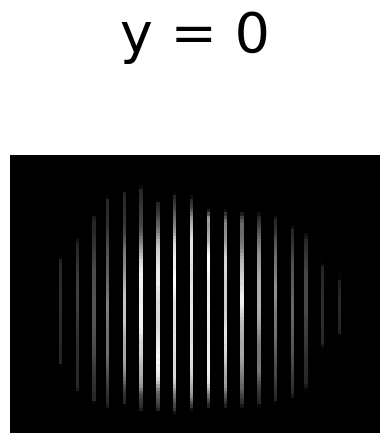

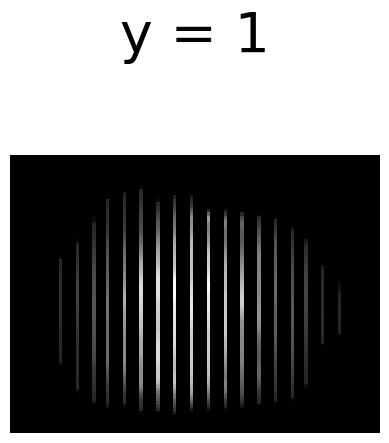

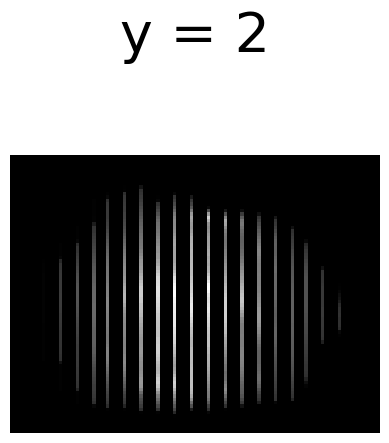

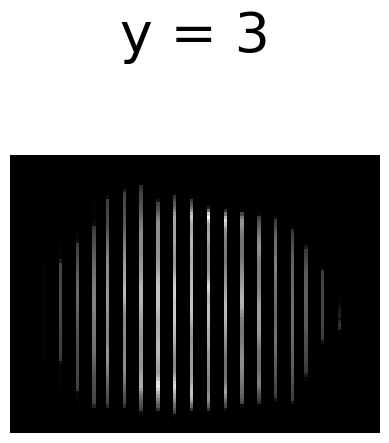

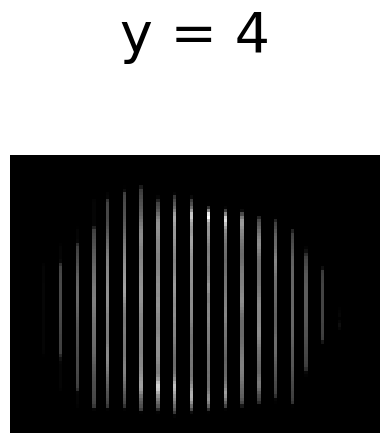

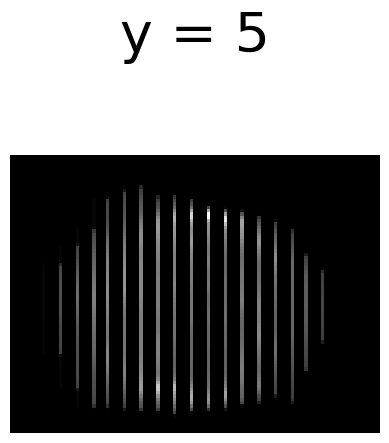

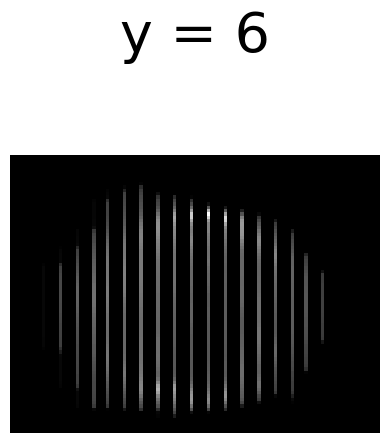

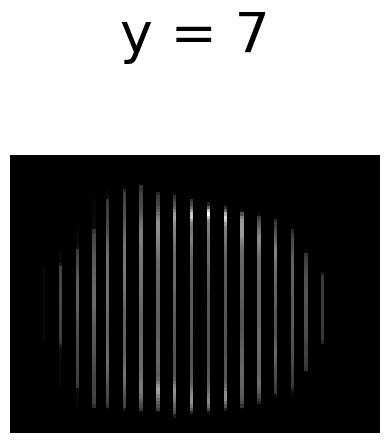

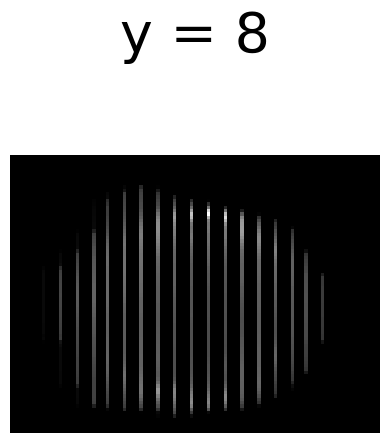

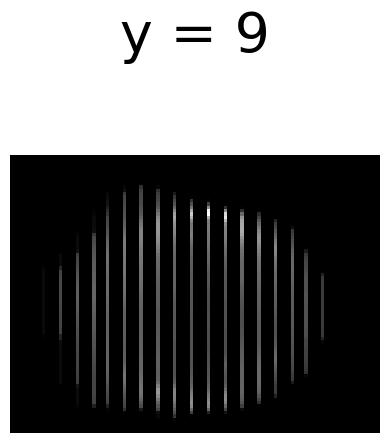

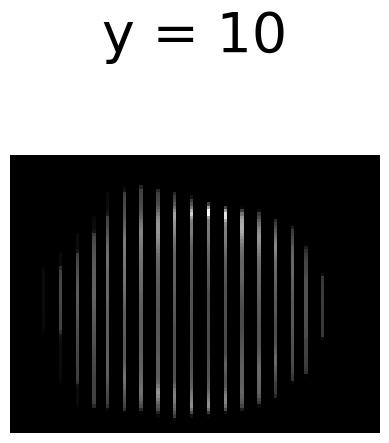

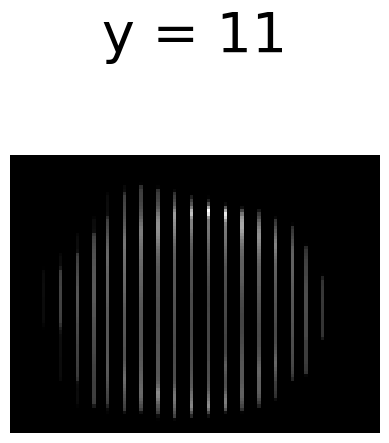

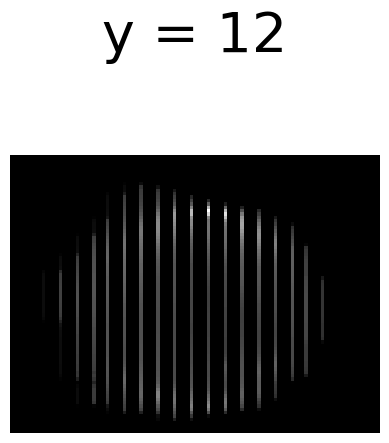

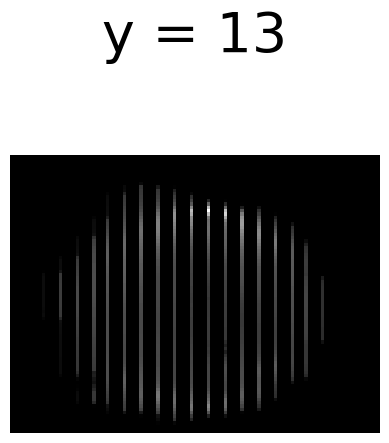

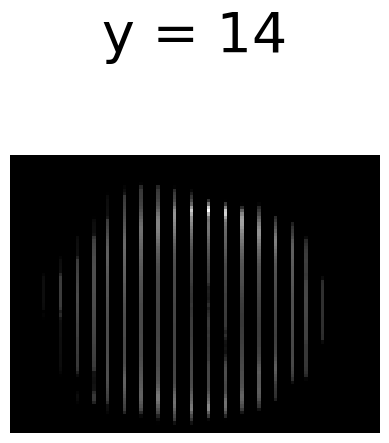

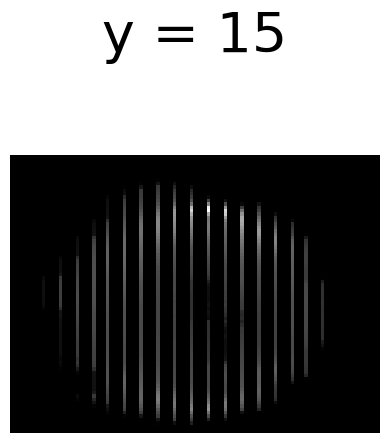

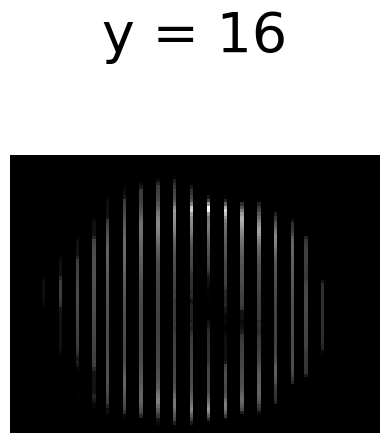

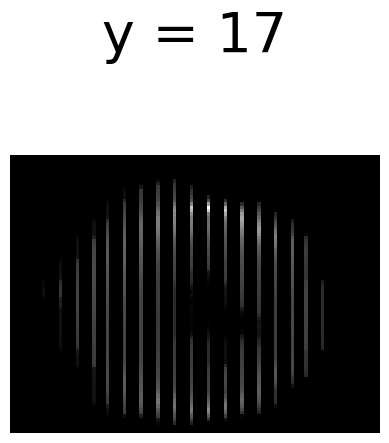

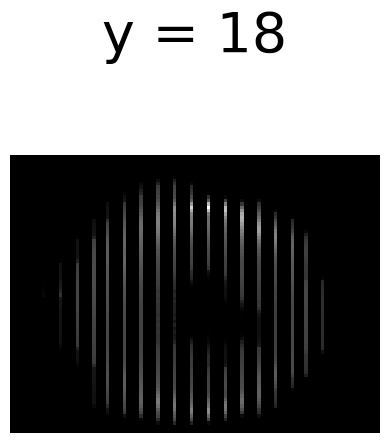

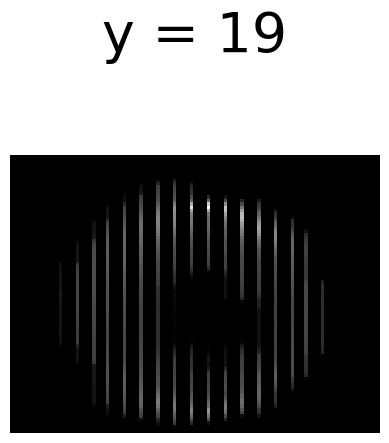

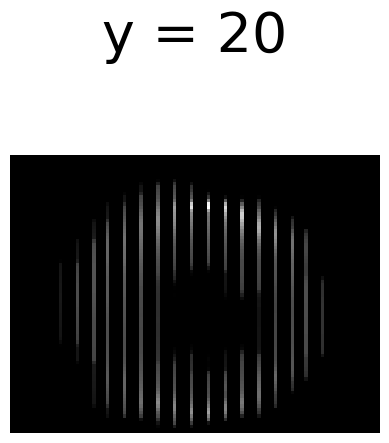

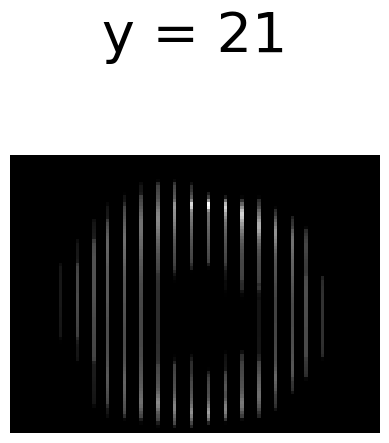

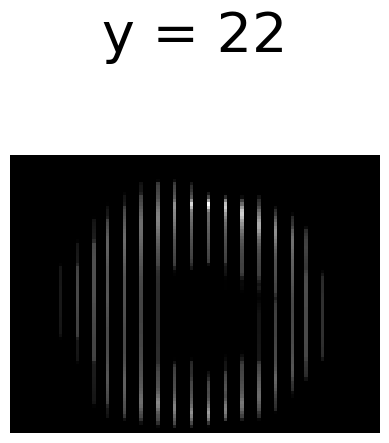

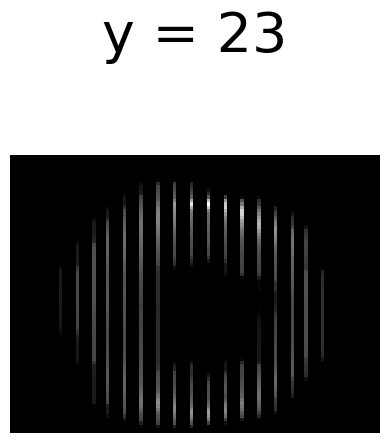

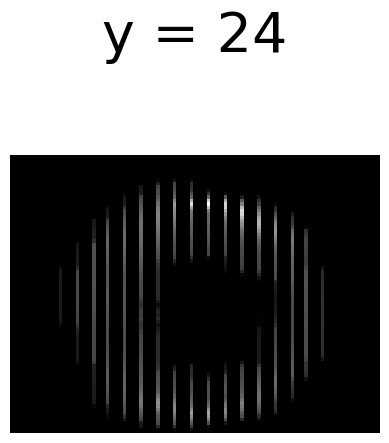

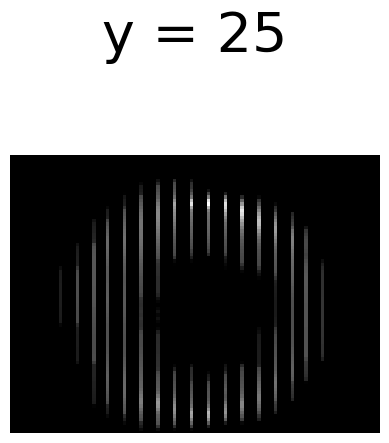

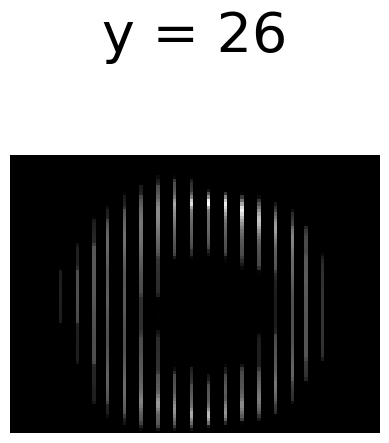

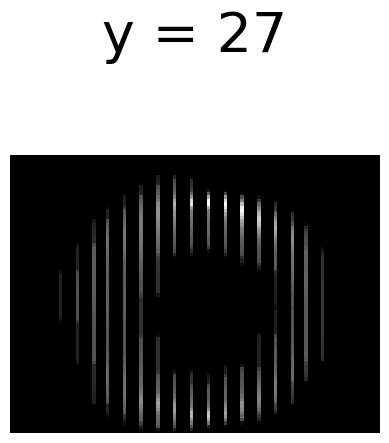

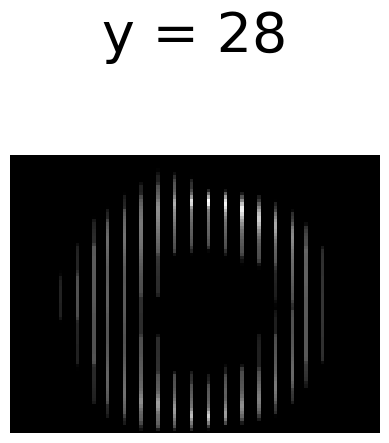

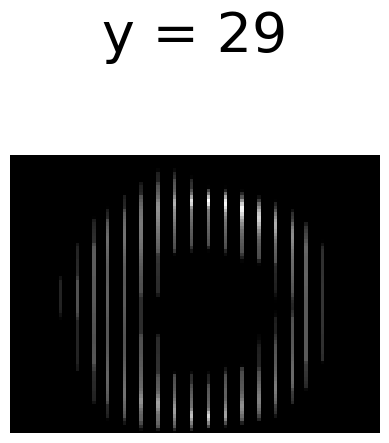

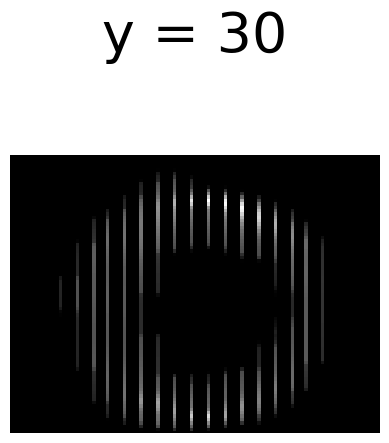

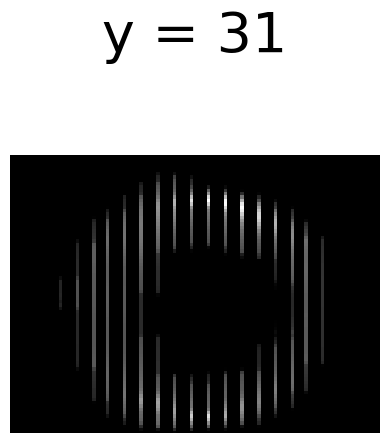

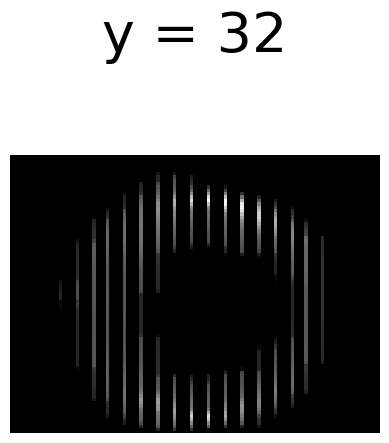

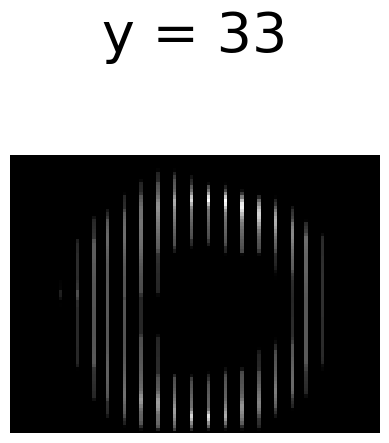

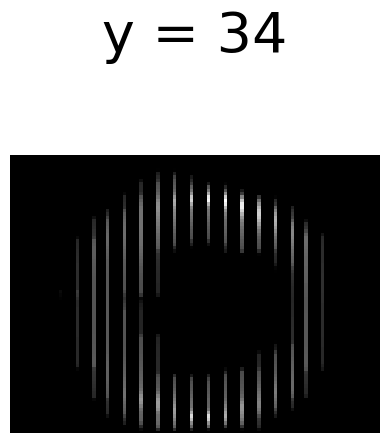

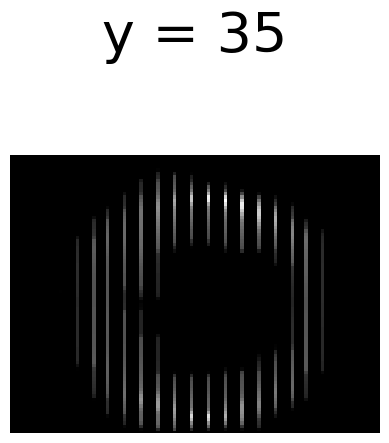

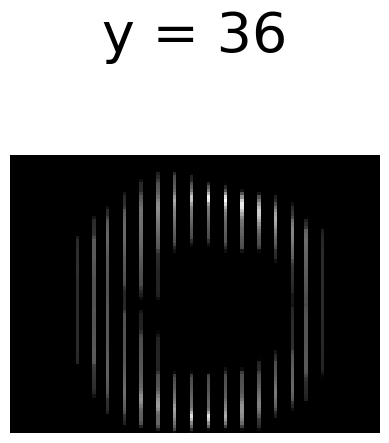

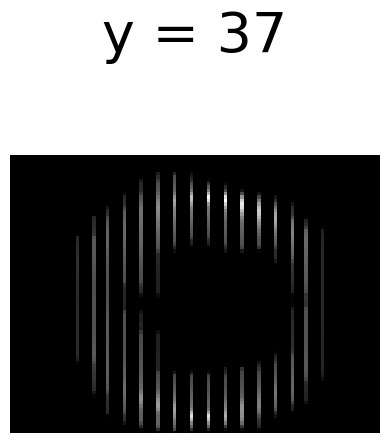

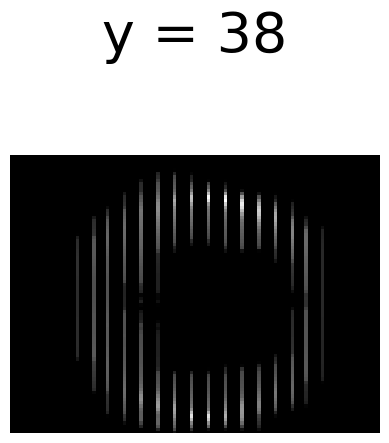

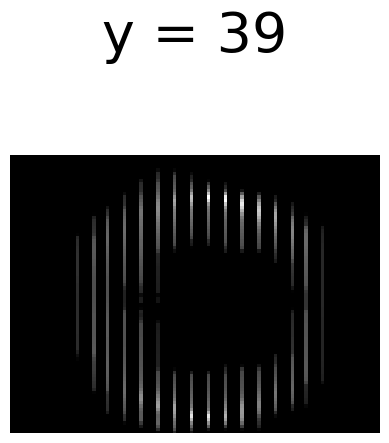

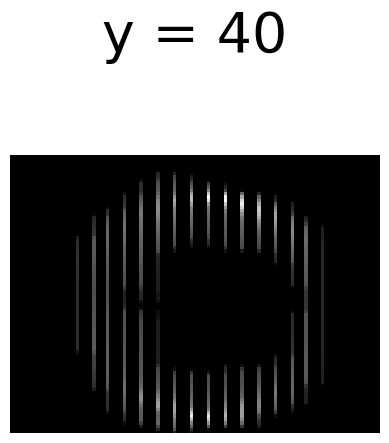

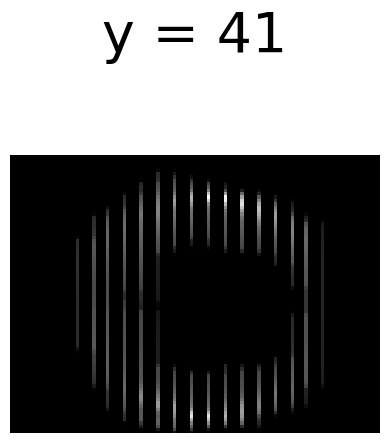

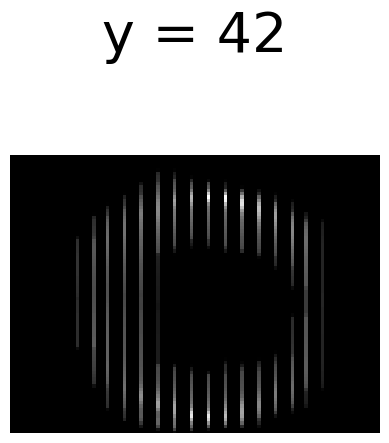

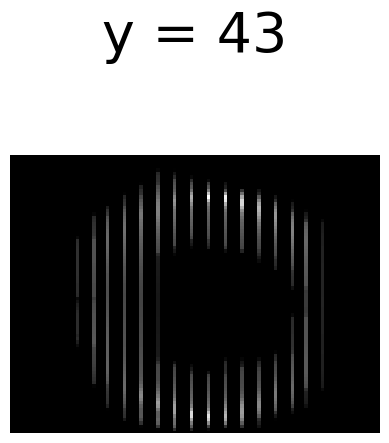

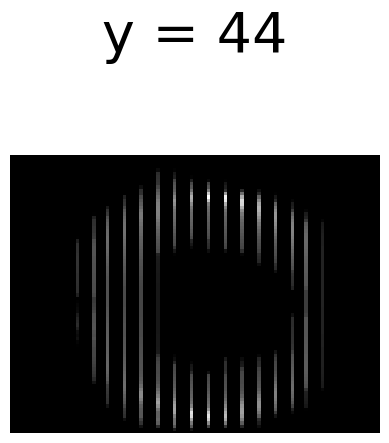

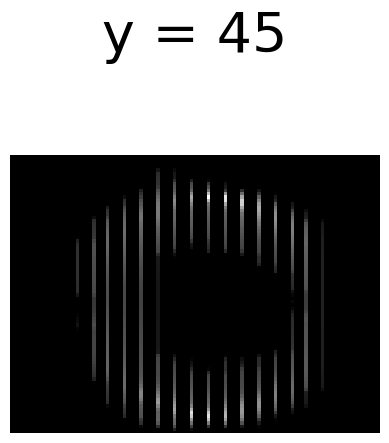

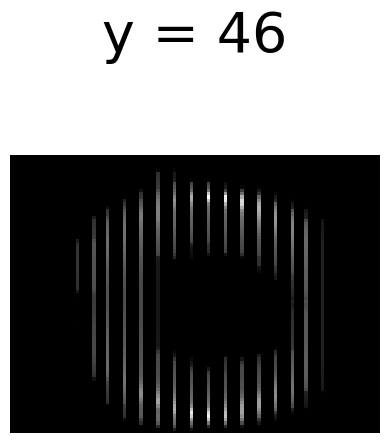

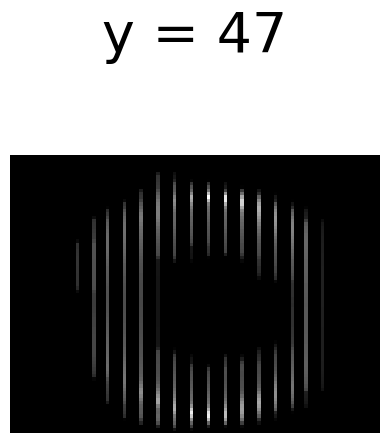

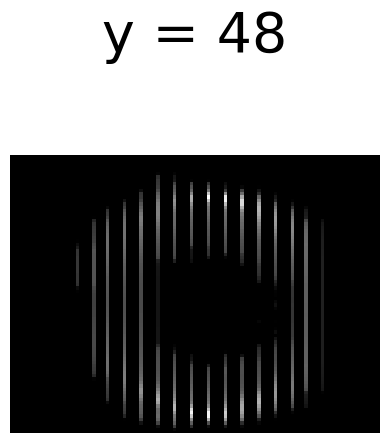

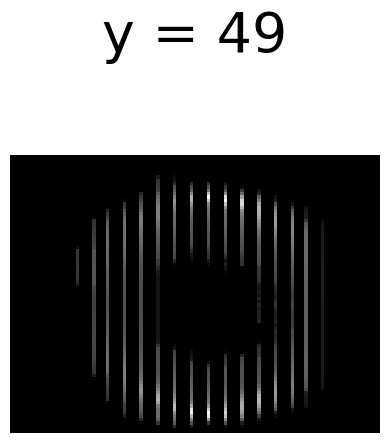

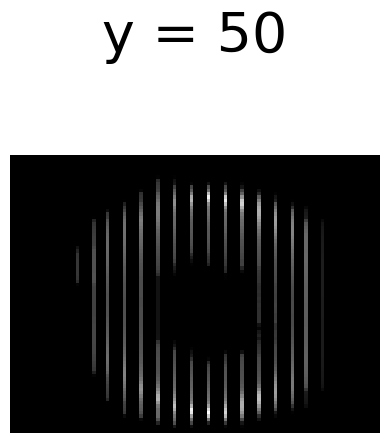

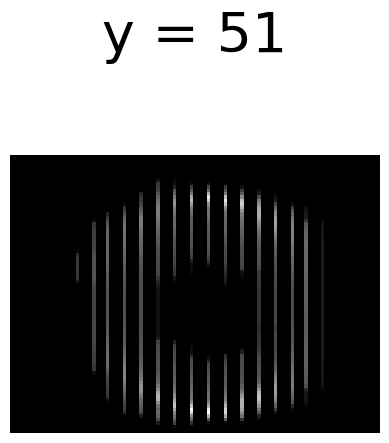

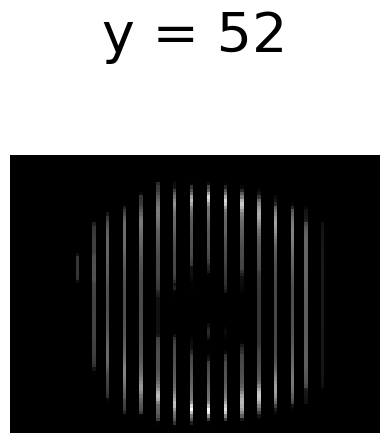

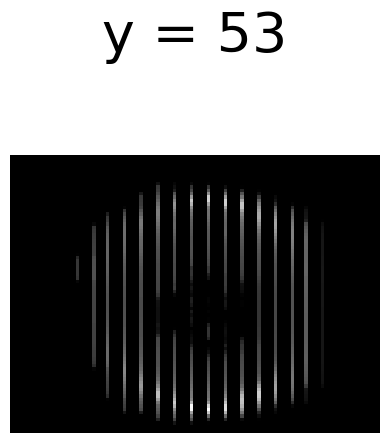

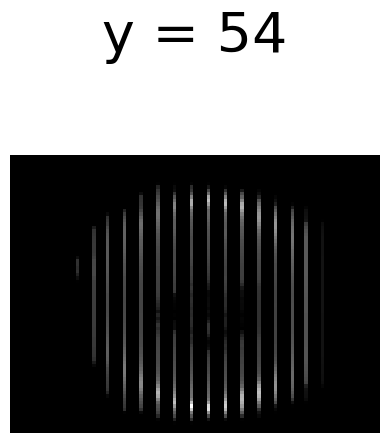

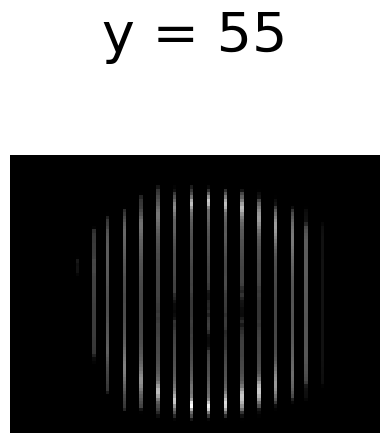

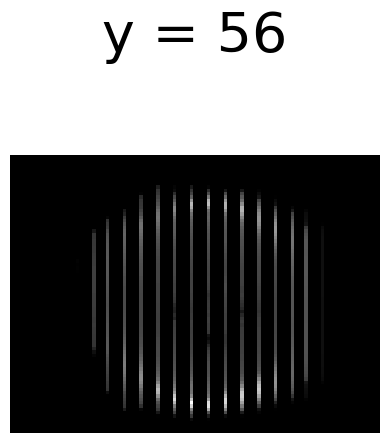

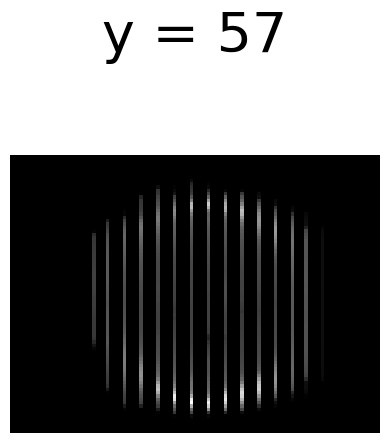

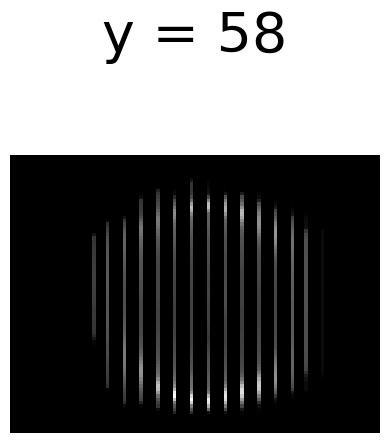

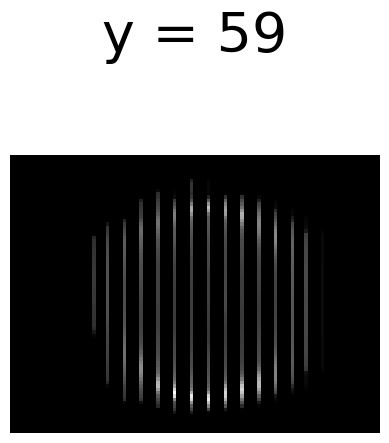

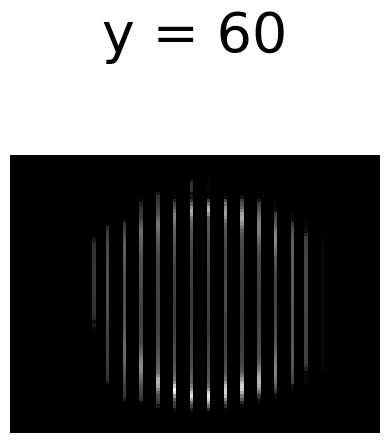

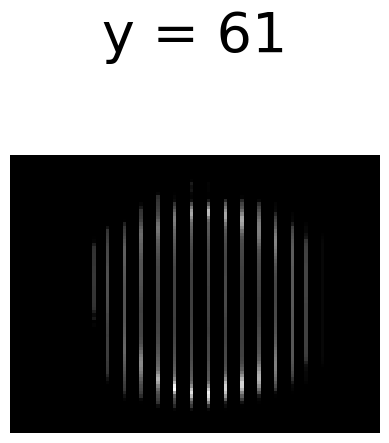

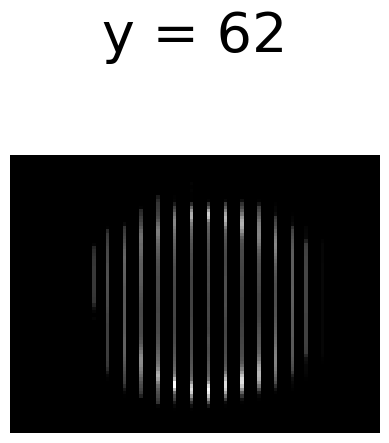

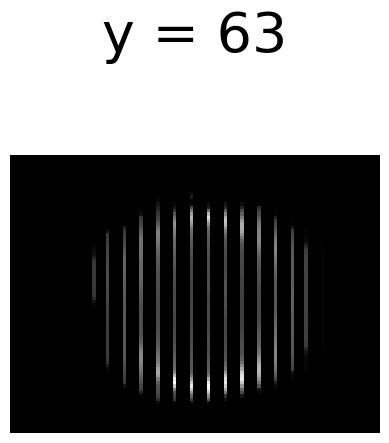

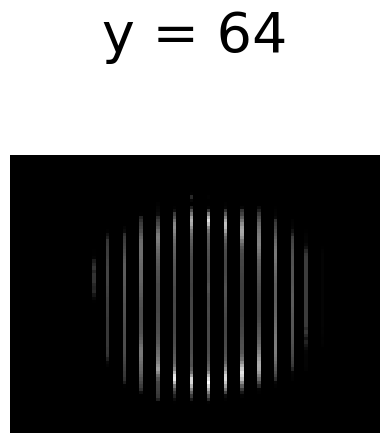

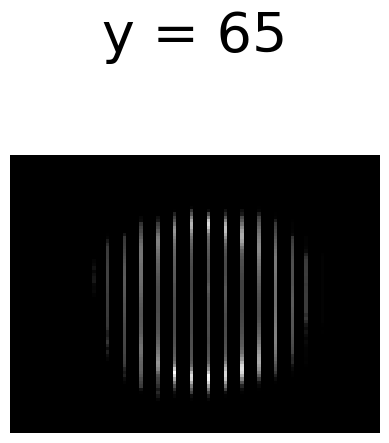

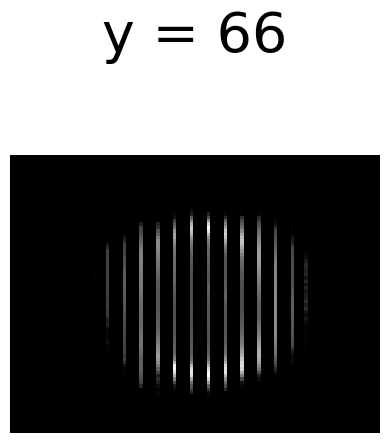

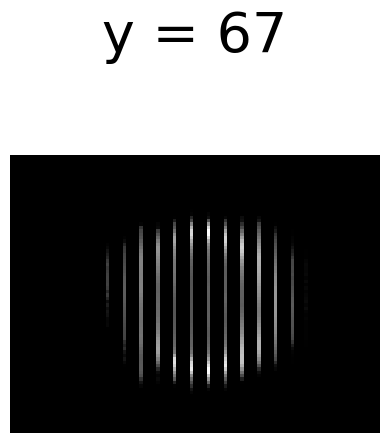

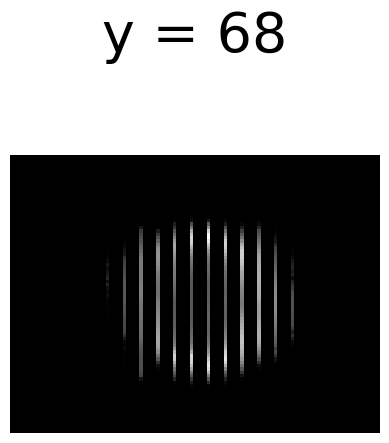

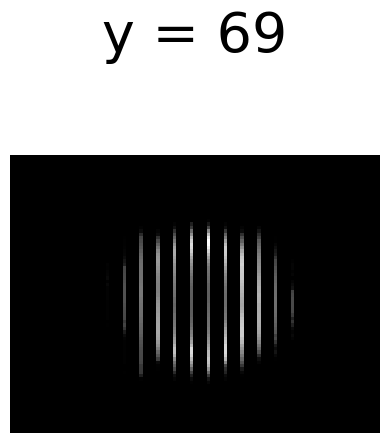

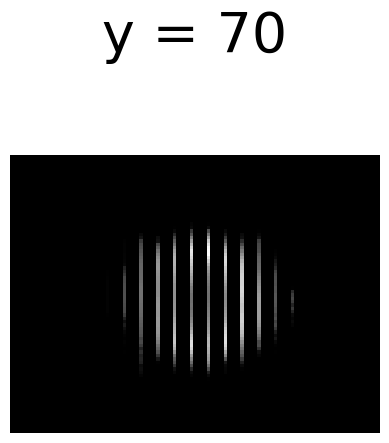

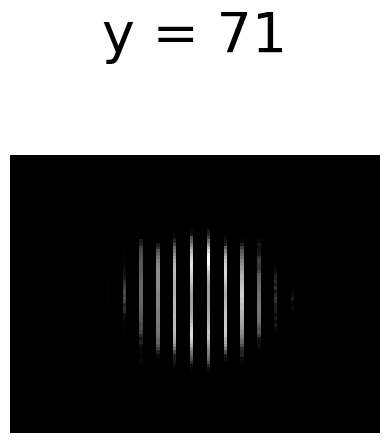

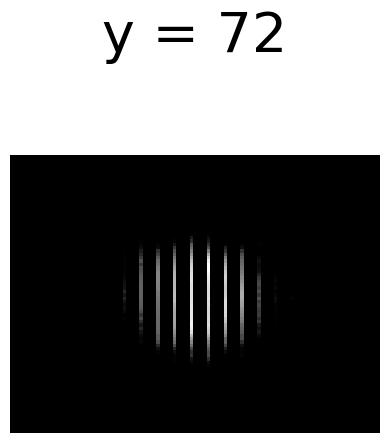

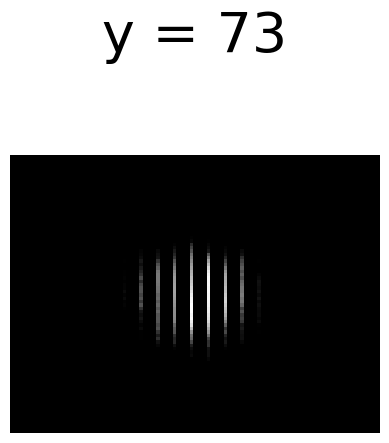

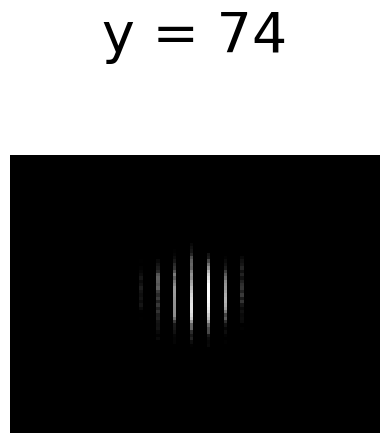

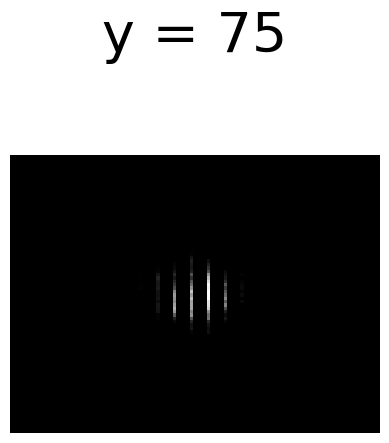

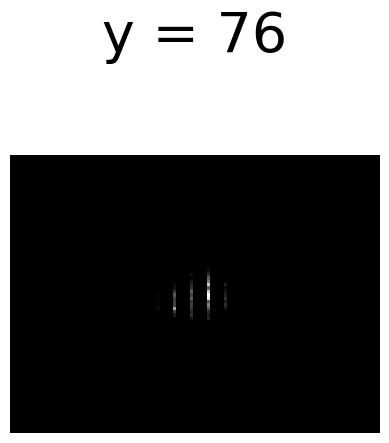

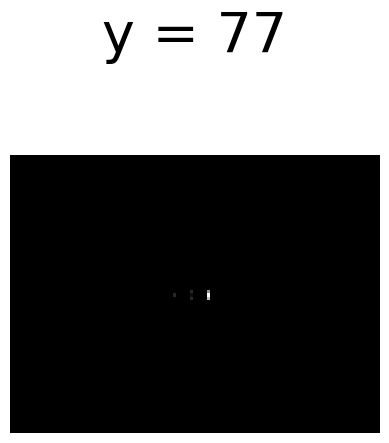

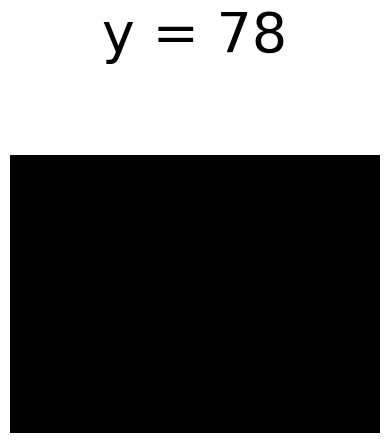

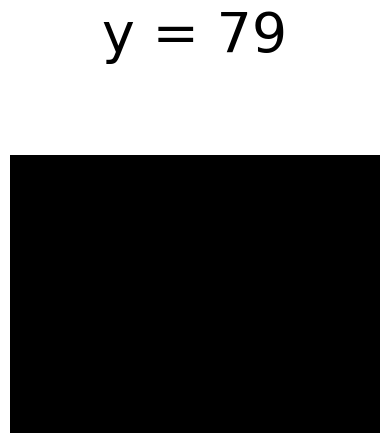

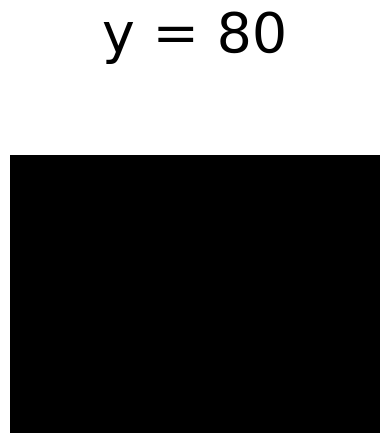

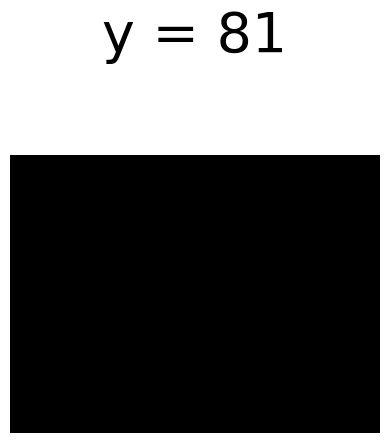

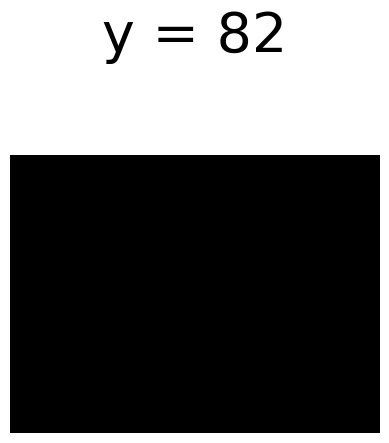

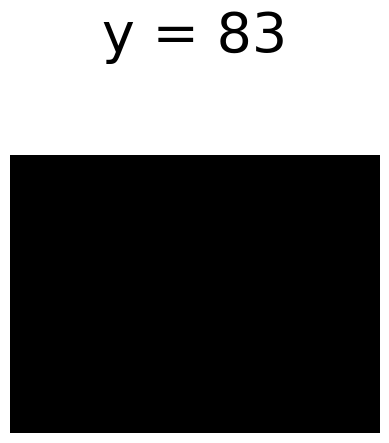

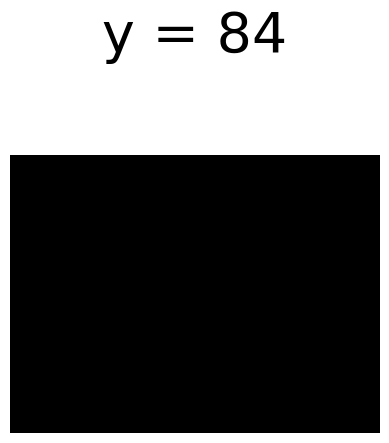

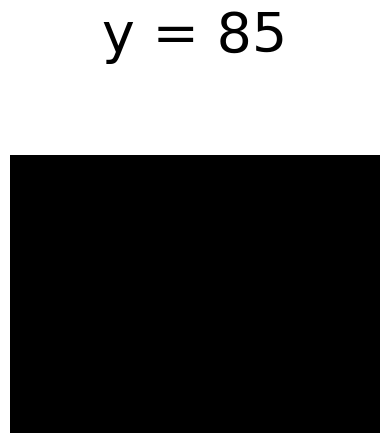

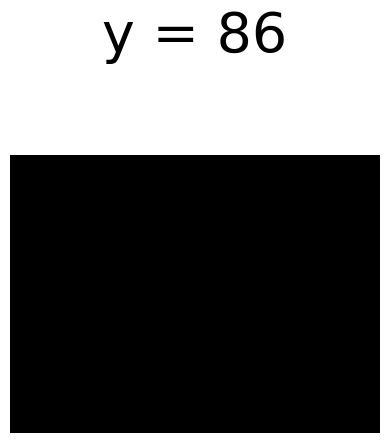

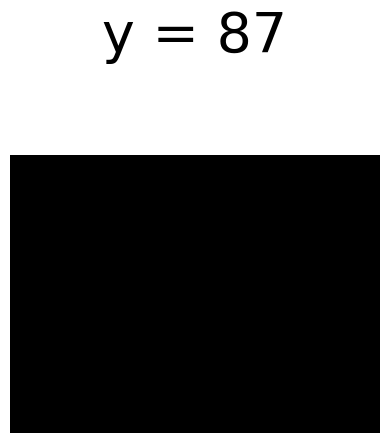

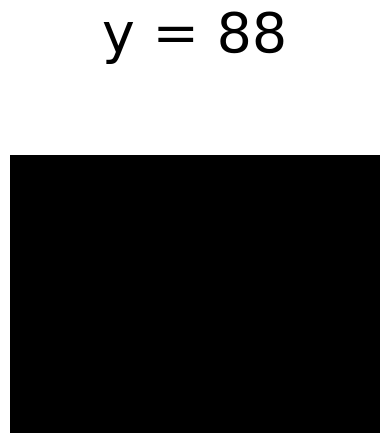

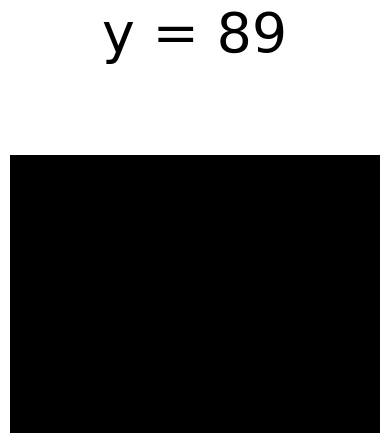

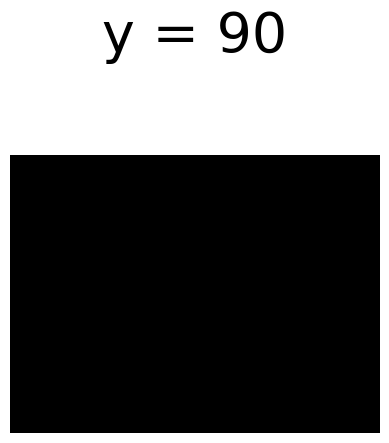

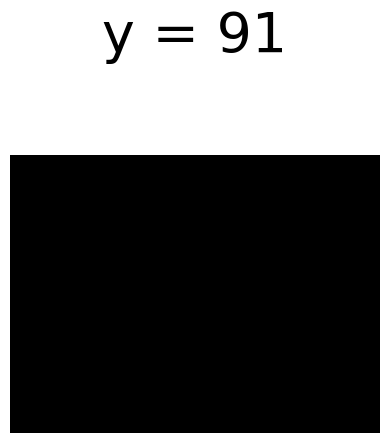

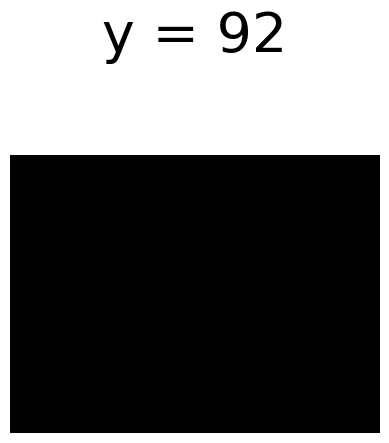

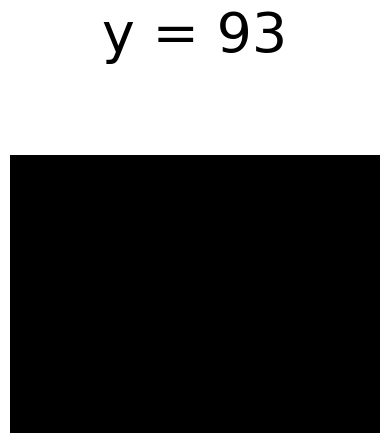

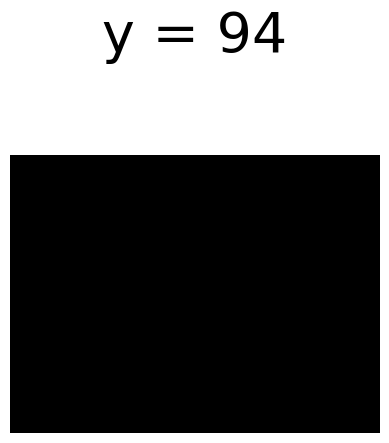

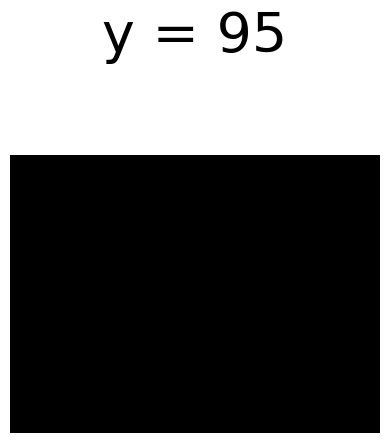

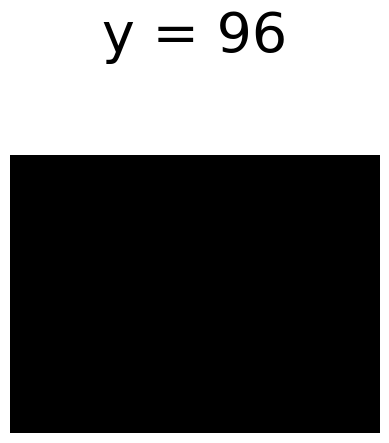

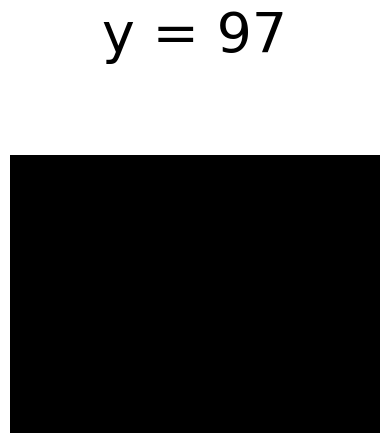

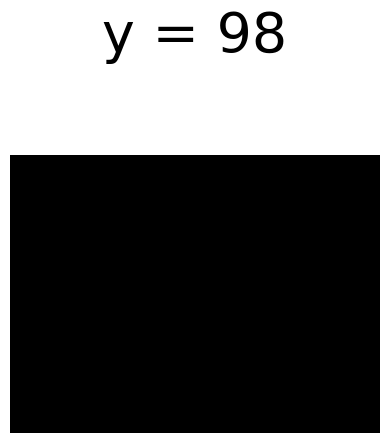

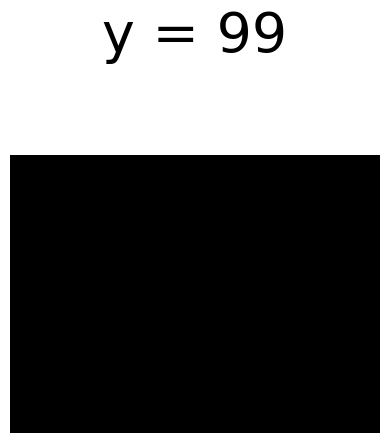

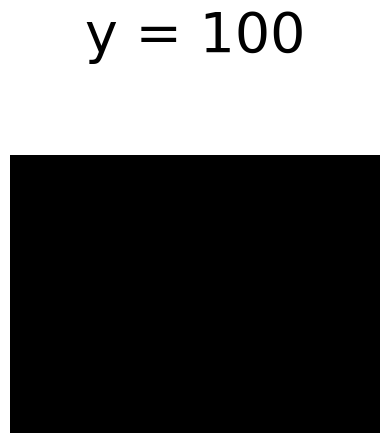

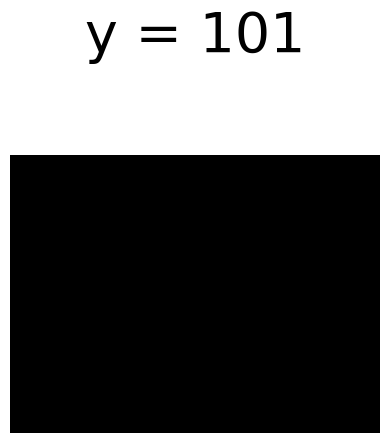

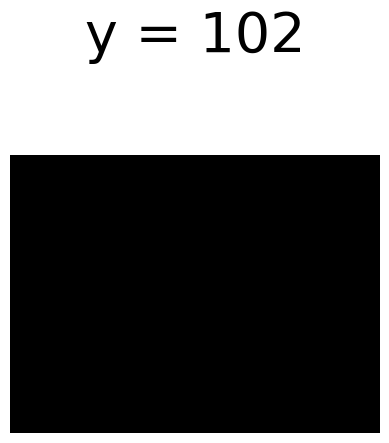

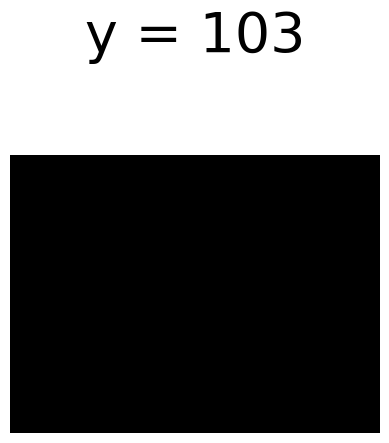

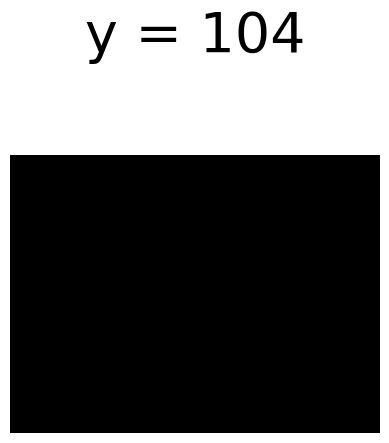

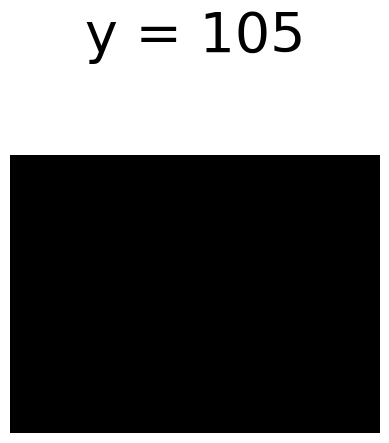

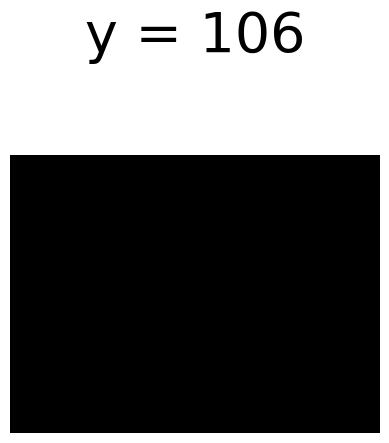

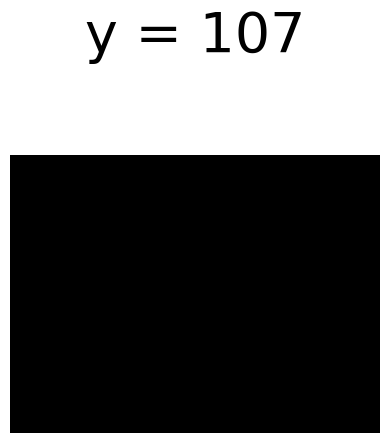

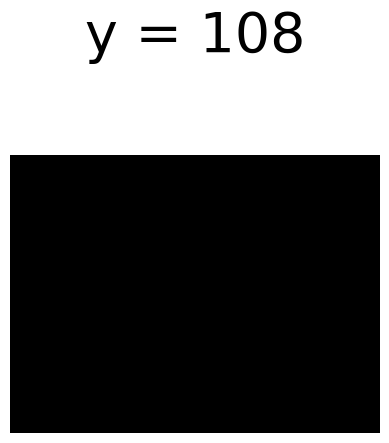

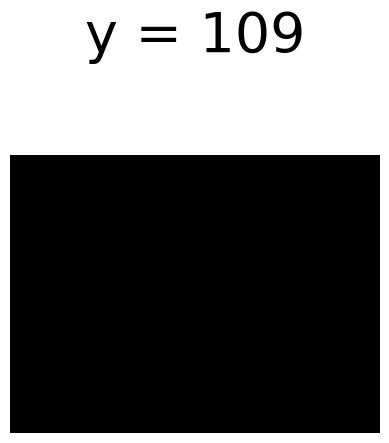

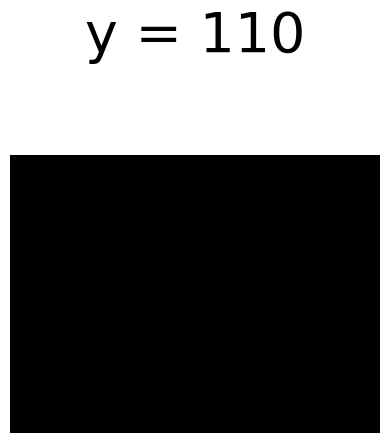

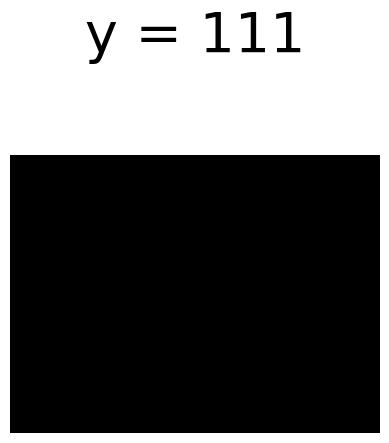

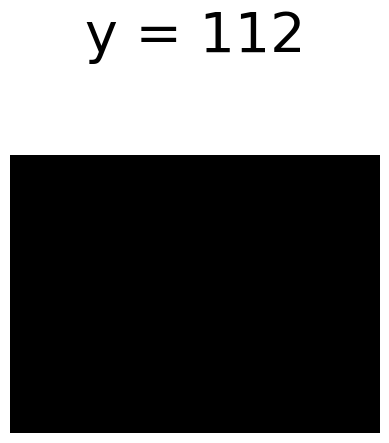

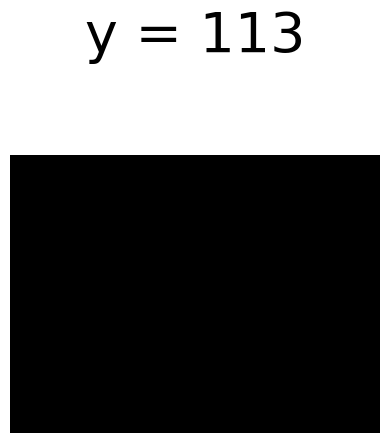

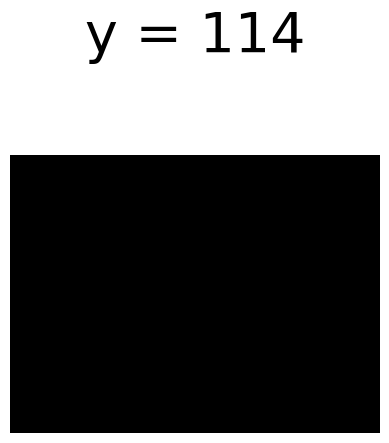

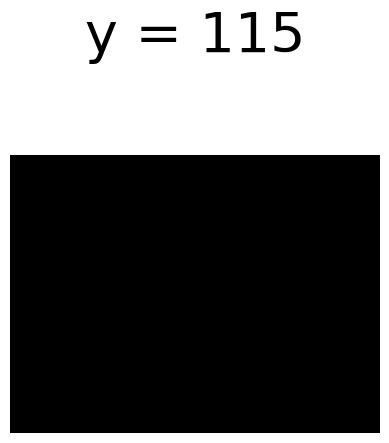

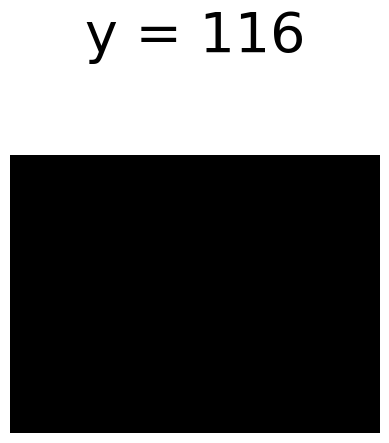

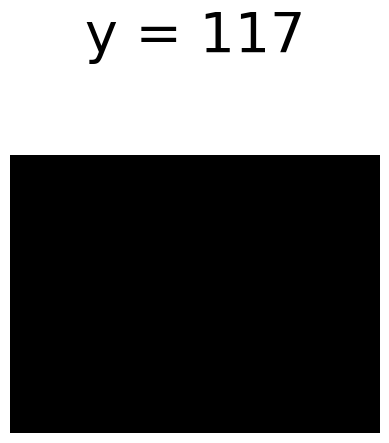

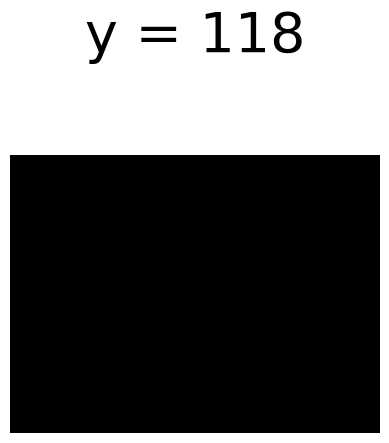

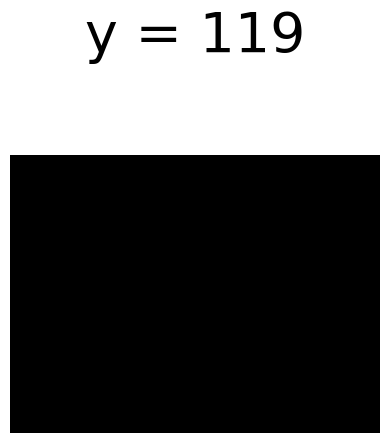

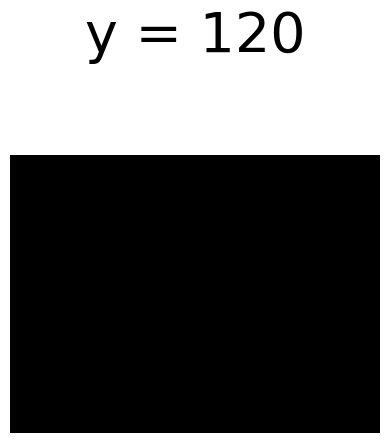

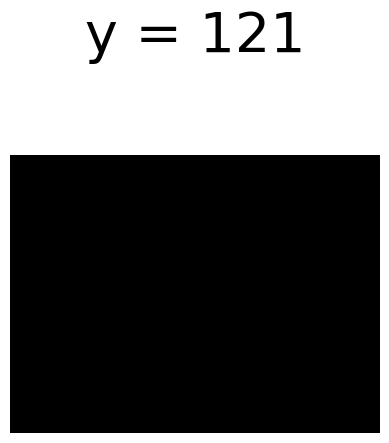

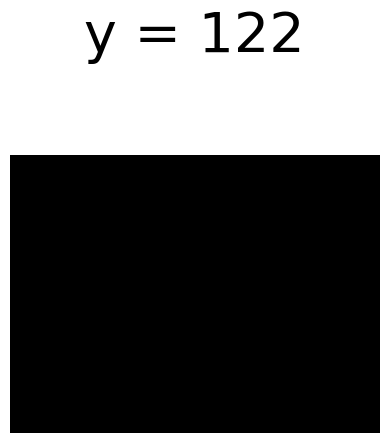

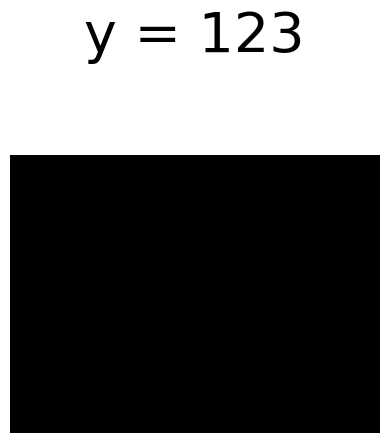

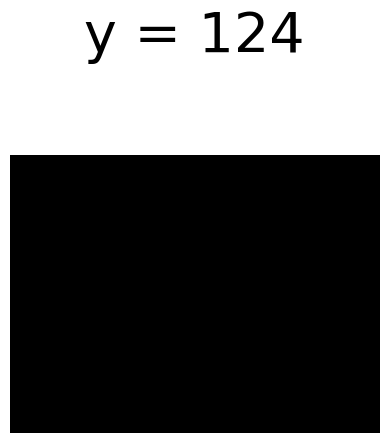

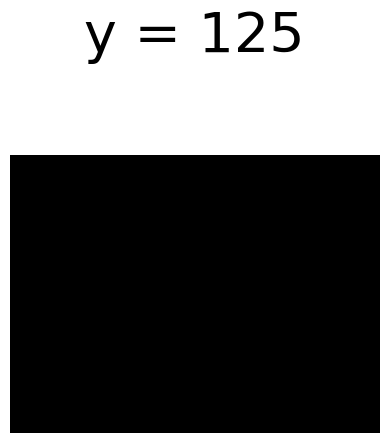

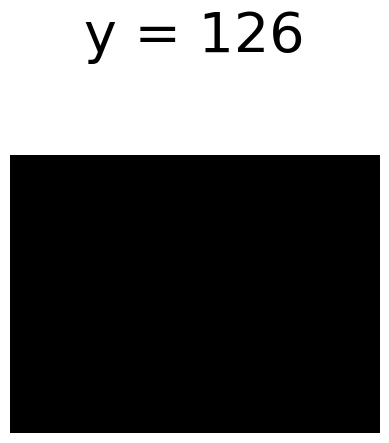

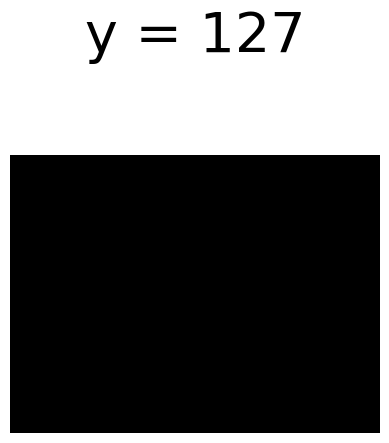

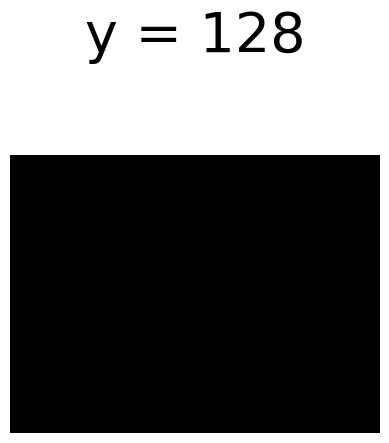

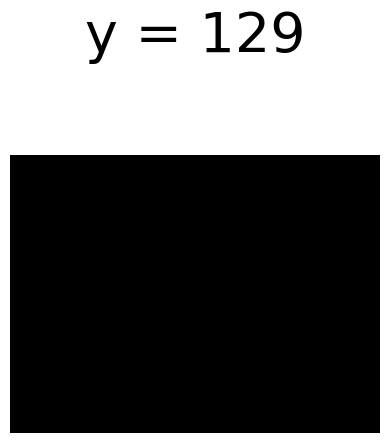

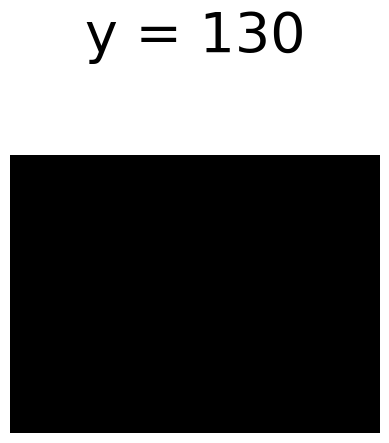

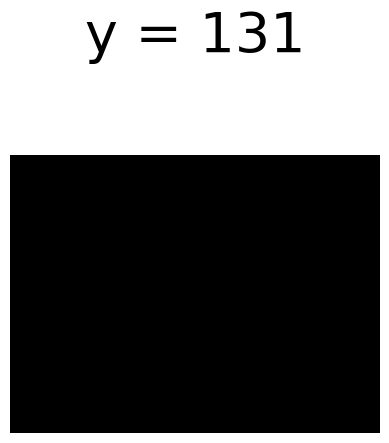

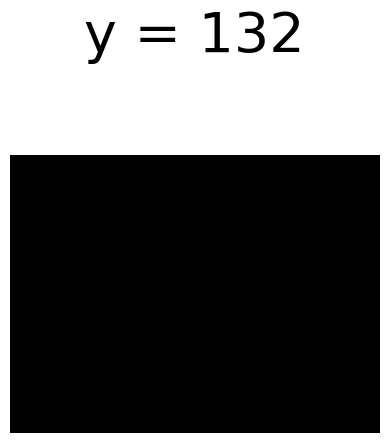

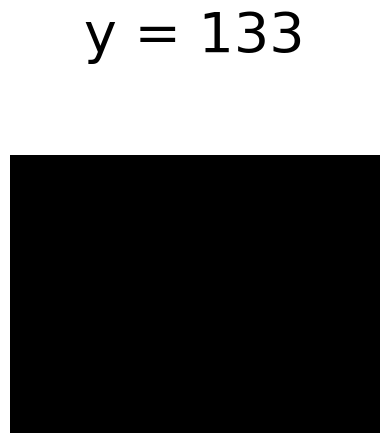

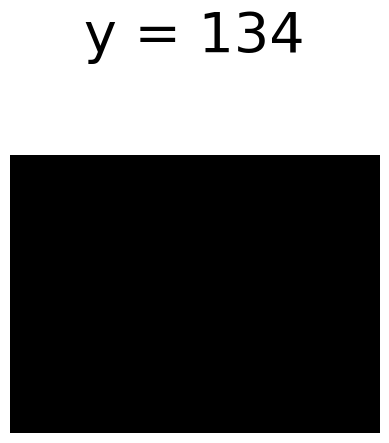

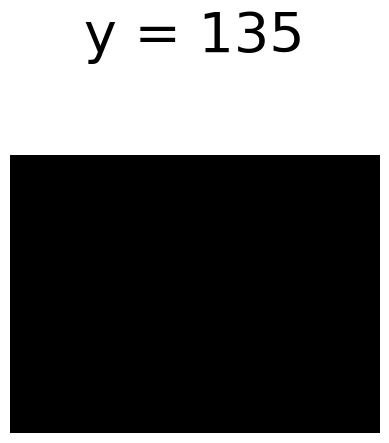

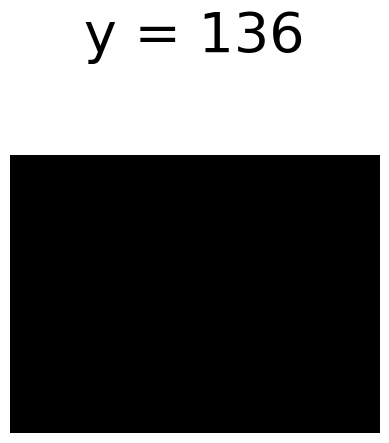

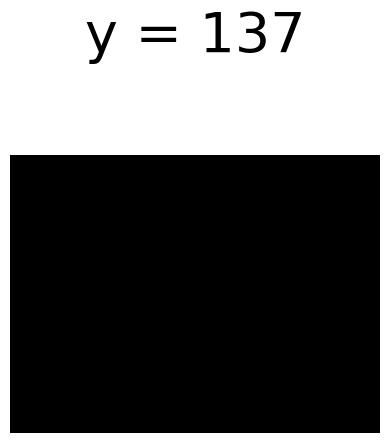

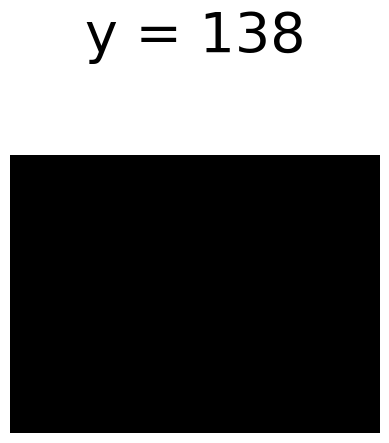

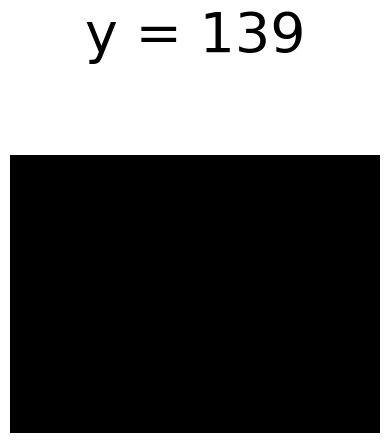

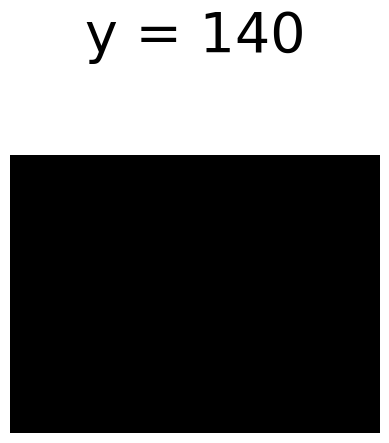

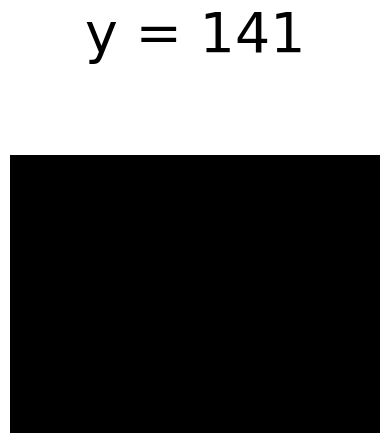

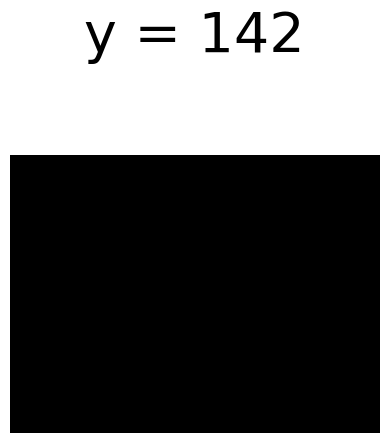

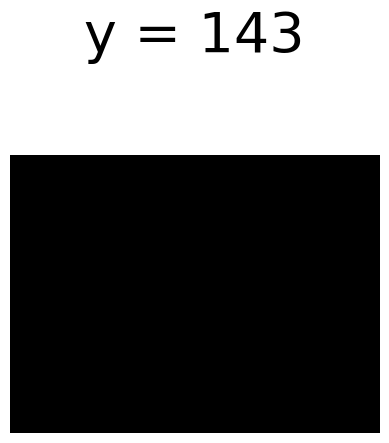

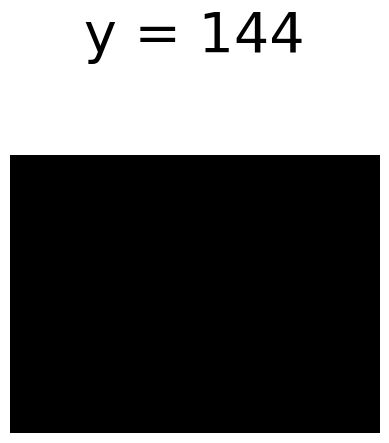

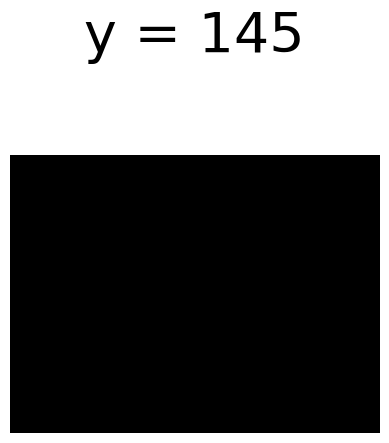

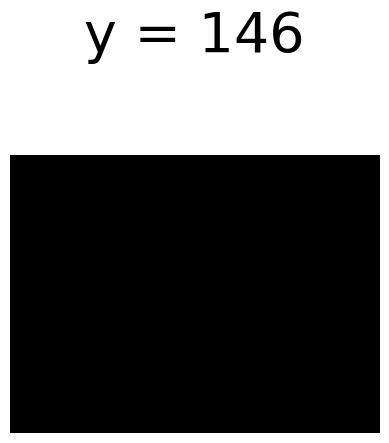

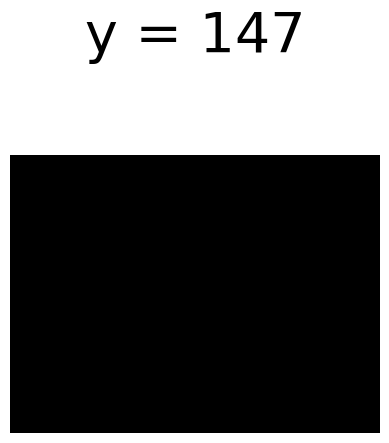

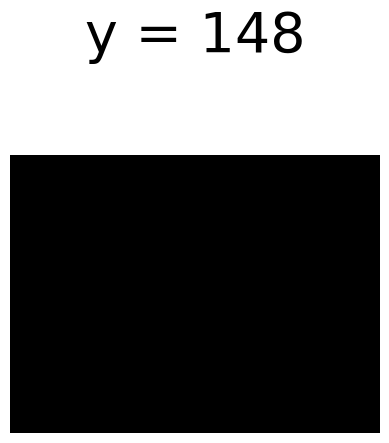

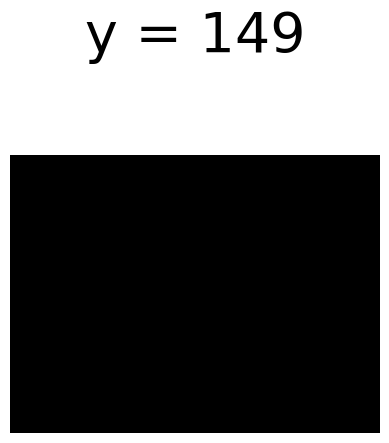

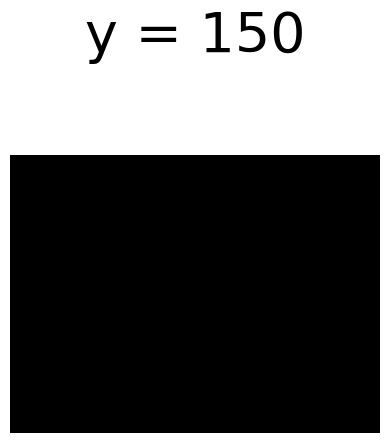

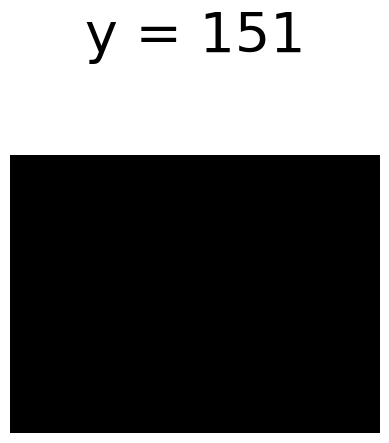

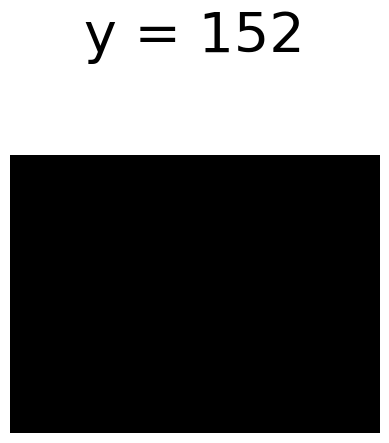

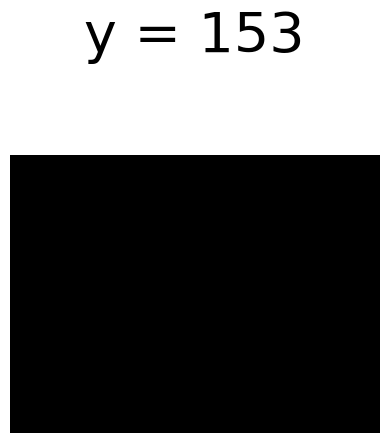

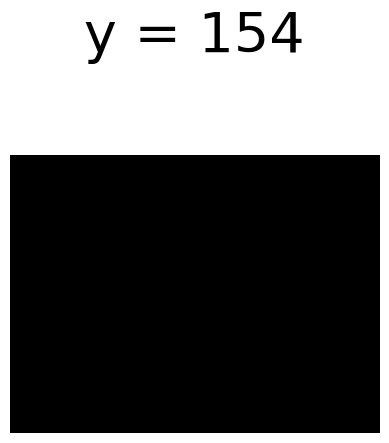

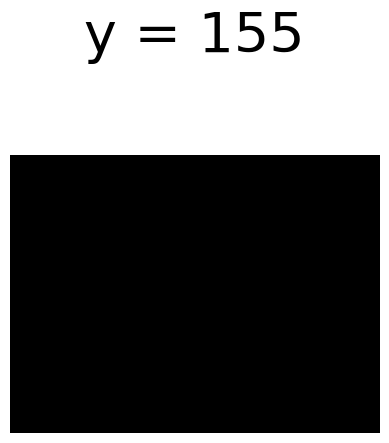

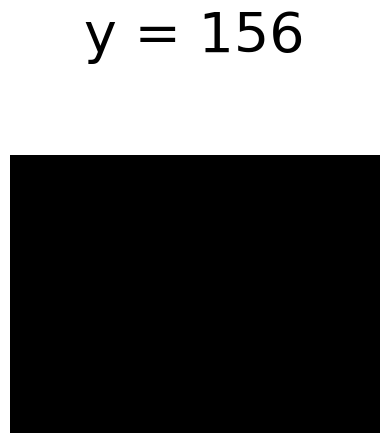

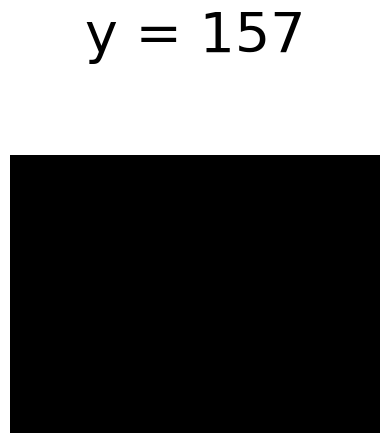

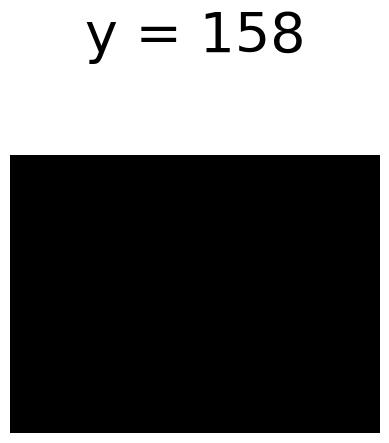

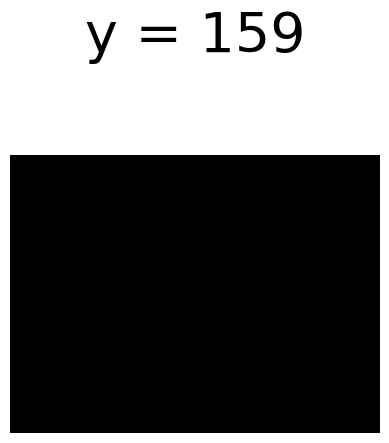

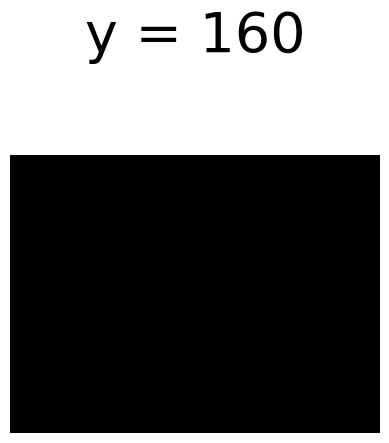

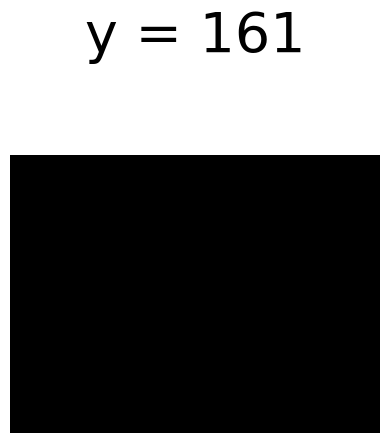

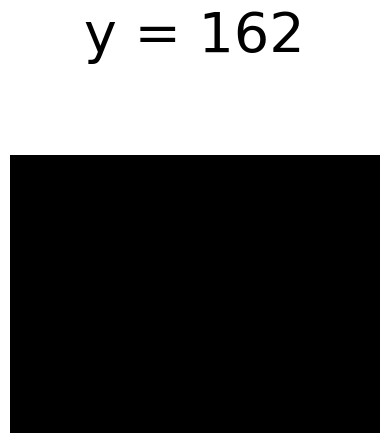

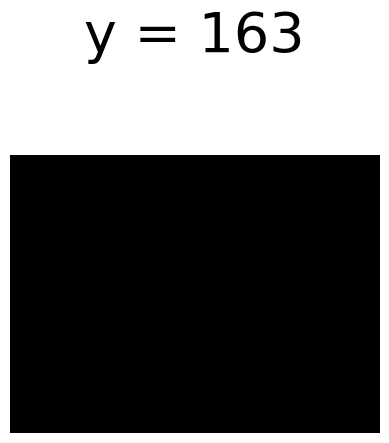

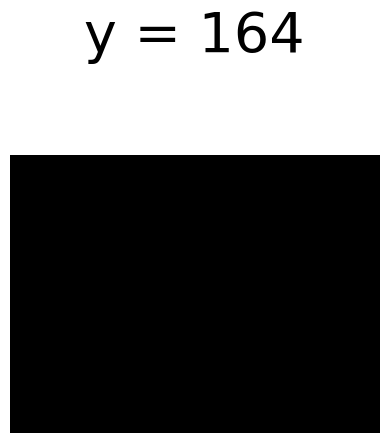

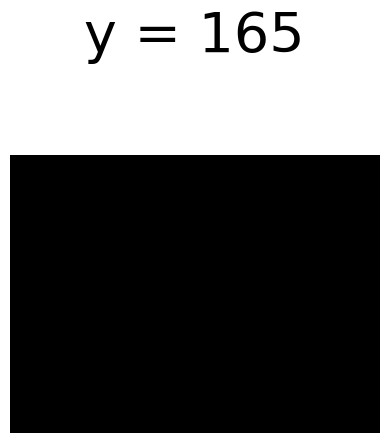

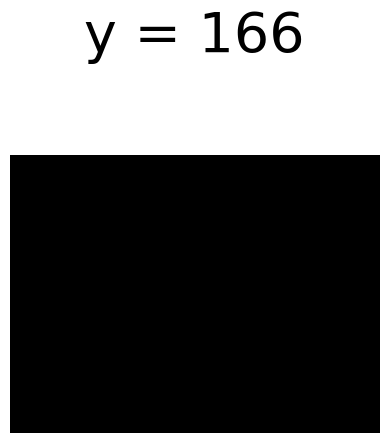

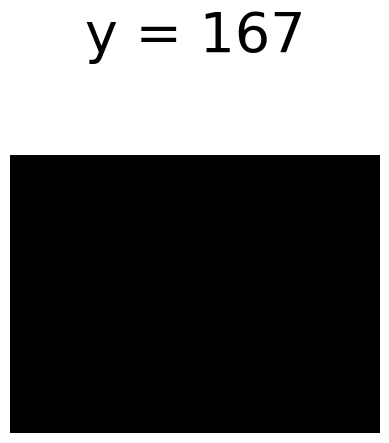

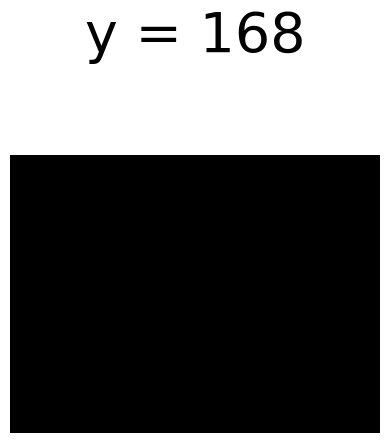

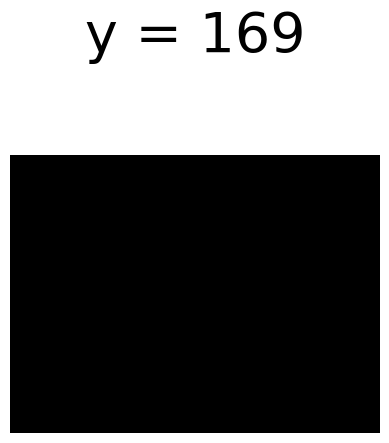

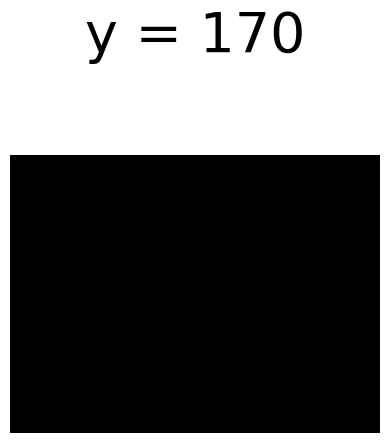

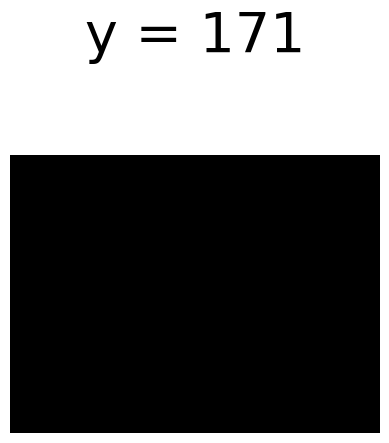

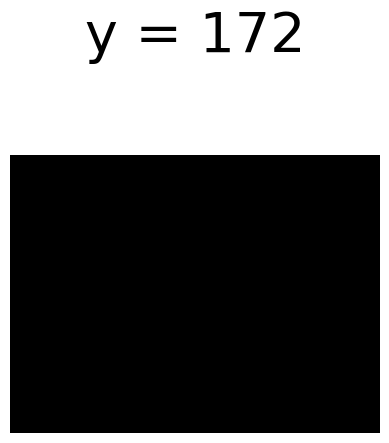

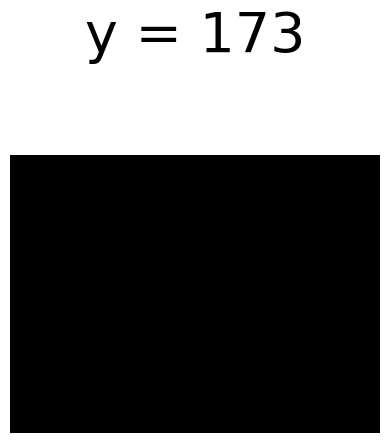

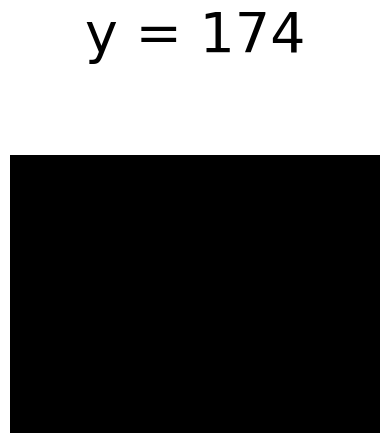

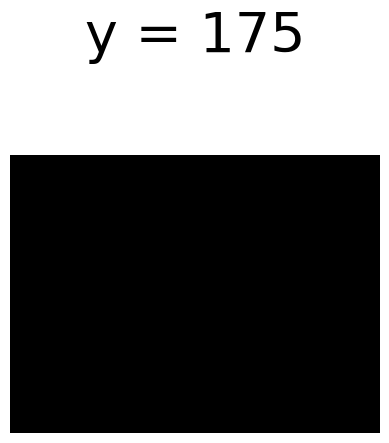

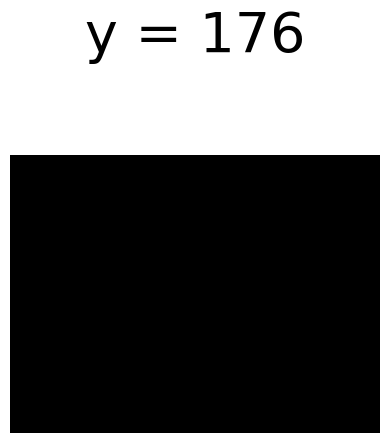

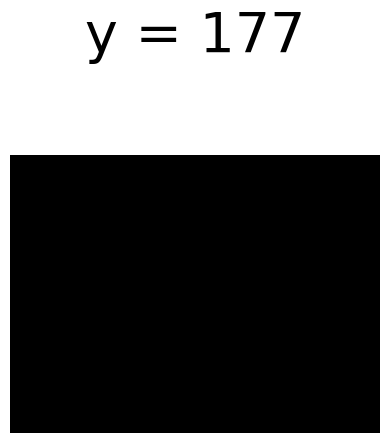

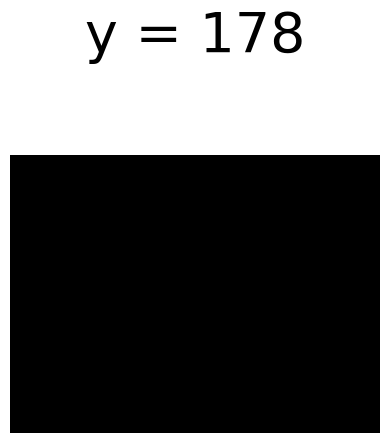

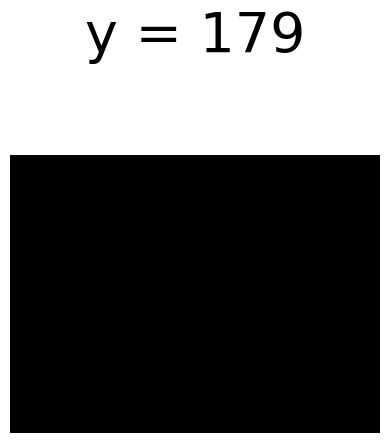

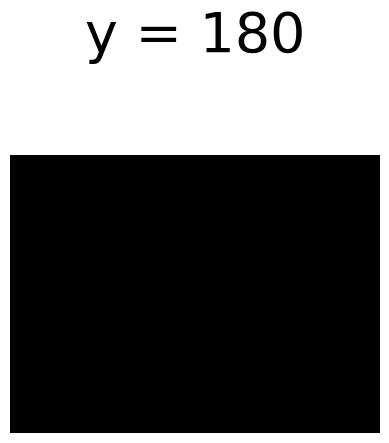

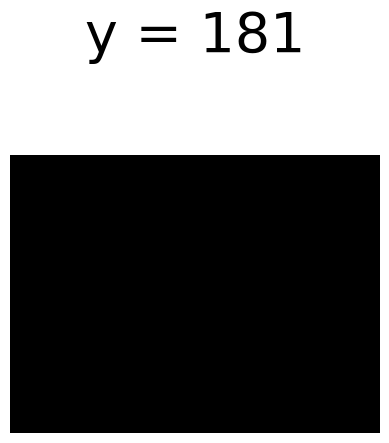

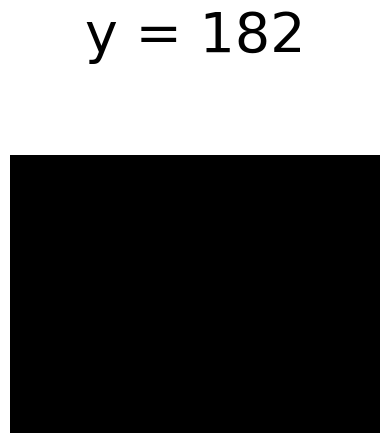

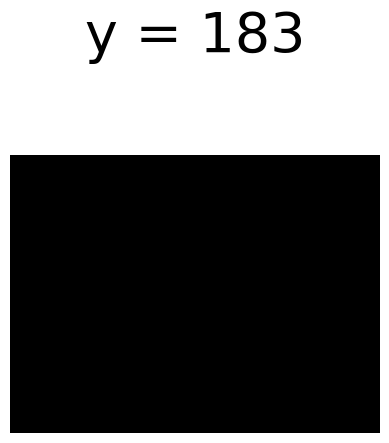

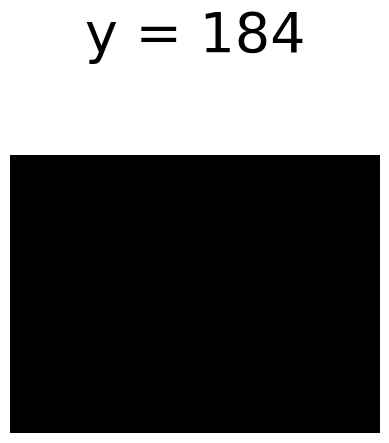

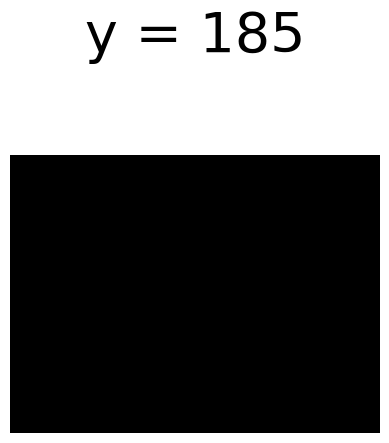

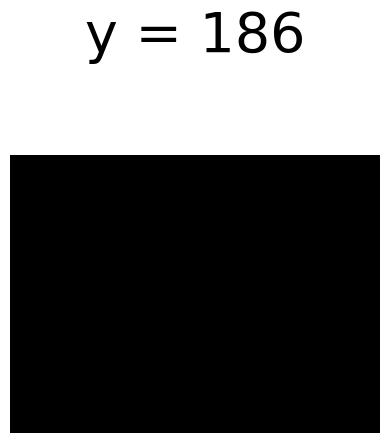

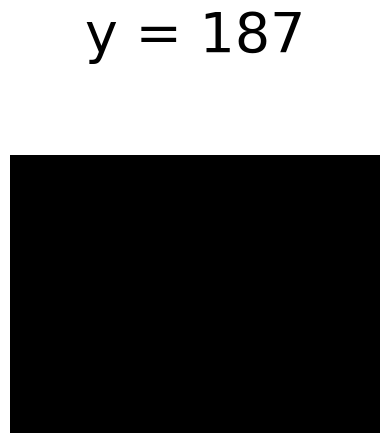

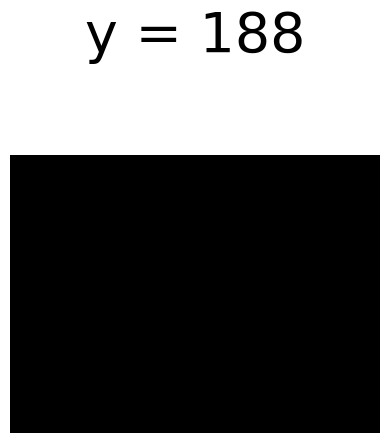

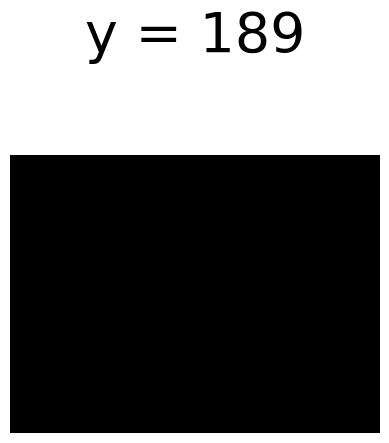

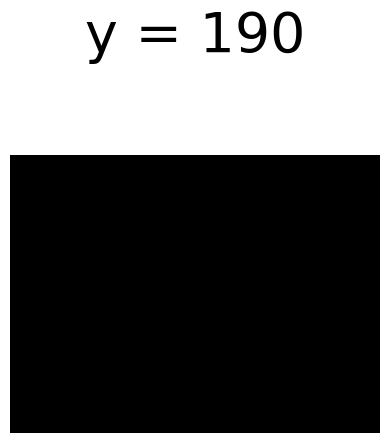

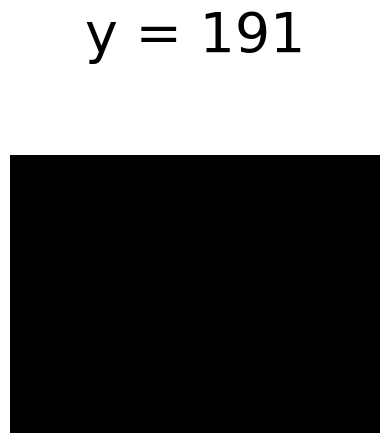

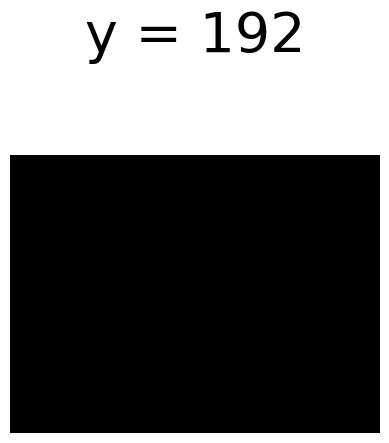

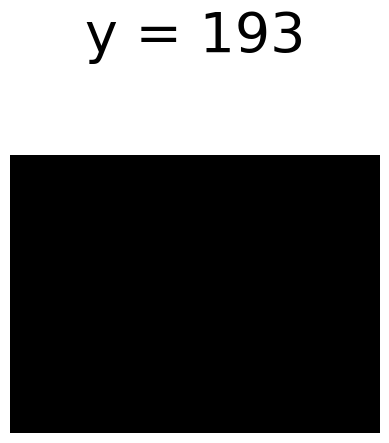

In [33]:
# 【日本語コメント】XZ 断面の z 方向 spacing を xy 方向 spacing に合わせるため、0 埋めで再サンプリングします。
# 【日本語コメント】各 y slice で最大連結領域を抽出し、等方的な表示スケールで確認します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# 原来的 Z slice 放到对应的新位置，中间新增的像素全部设为 0
# 【日本語コメント】z 方向を xy 方向と同じ spacing に近づけるため、間を 0 で埋める関数です。
def resample_z_insert_zero(slice_xz, dxy, dz):
    """
    slice_xz: shape = (X, Z)
    output: shape = (X, Z_iso)
    新增位置填 0，不做插值
    """
    X, Z = slice_xz.shape

    # 【日本語コメント】元の z slice 位置を物理座標 µm で定義します。
    z_um = np.arange(Z) * dz
    # 【日本語コメント】z 方向を dxy 間隔に換算した後の slice 数を計算します。
    Z_iso = int(np.round((Z - 1) * dz / dxy)) + 1

    # 【日本語コメント】再サンプリング後の XZ 断面を格納する配列を作成します。
    slice_iso = np.zeros((X, Z_iso), dtype=slice_xz.dtype)

    z_iso_idx = np.round(z_um / dxy).astype(int)
    z_iso_idx = np.clip(z_iso_idx, 0, Z_iso - 1)

    slice_iso[:, z_iso_idx] = slice_xz

    return slice_iso


threshold = np.percentile(cleaned_volume, 0)

y0 = 0
ye = 88

xs = 0
xt = 110
ys = 110
yt = 220


X, Y, Z = cleaned_volume.shape

# for z in range(aligned_volume.shape[2]):
# 【日本語コメント】指定した y slice 範囲を順番に処理します。
# for y in range(y0,ye):
for y in range(0,cleaned_volume.shape[1]):
    # 【日本語コメント】現在の y 位置における XZ 断面を取り出します。
    slice_xz = cleaned_volume[:, y, :]  # (X,Z)

    # 1️⃣ 二值化（threshold 很关键）
    mask = slice_xz > threshold
    # 2️⃣ 连通区域标记
    # 【日本語コメント】連結成分ラベリングを行い、独立した領域を識別します。
    labeled, num = ndimage.label(mask)
    # 3️⃣ 找最大区域
    # 【日本語コメント】各連結成分のサイズを計算します。
    sizes = ndimage.sum(mask, labeled, range(1, num+1))
    if len(sizes) == 0:
        continue
    
    # 【日本語コメント】最も大きい連結成分のラベルを選択します。
    largest_label = np.argmax(sizes) + 1
    # 4️⃣ 只保留最大区域
    mask_clean = (labeled == largest_label)

    if y == 0:
        m0 = mask_clean
    else:
        mask_clean = mask_clean
    # 5️⃣ 应用到原数据
    clean_slice_xz = slice_xz * mask_clean

    # if len(sizes) == 0:
    #     clean_slice_xz = slice_xz
    # else:
    #     # 【日本語コメント】最も大きい連結成分のラベルを選択します。
    #     largest_label = np.argmax(sizes) + 1
    #     # 4️⃣ 只保留最大区域
    #     mask_clean = (labeled == largest_label)
    
    #     if y == 0:
    #         m0 = mask_clean
    #     else:
    #         mask_clean = mask_clean
    #     # 5️⃣ 应用到原数据
    #     clean_slice_xz = slice_xz * mask_clean
    
    # -----------------------------
    # 6. resample XZ slice to isotropic scale
    # -----------------------------
    
    clean_slice_xz_iso = resample_z_insert_zero(
        clean_slice_xz,
        dxy=dxy,
        dz=dz
    )

    # extent = [
    #     0, Z * dz,   # x-axis: X direction, μm
    #     0, X * dxy     # y-axis: Z direction, μm
    # ]

    plt.figure()
    plt.imshow(clean_slice_xz_iso, cmap='gray')
    # plt.imshow(clean_slice_xz, cmap='gray',extent=extent,aspect="equal")
    plt.title(f"y = {y}",fontsize = 40)
    plt.axis('off')
    # plt.xlim([ 0,25])
    # plt.ylim([46,71])
    plt.xlim([xs,xt])
    plt.ylim([ys,yt])
    # plt.savefig("/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig2/slice/" + "%04d" % (y) + ".svg", bbox_inches='tight',dpi = 100)
    # plt.savefig("/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig2/slice_orginal/" + "%04d" % (y) + ".svg", bbox_inches='tight',dpi = 100)
    plt.show()

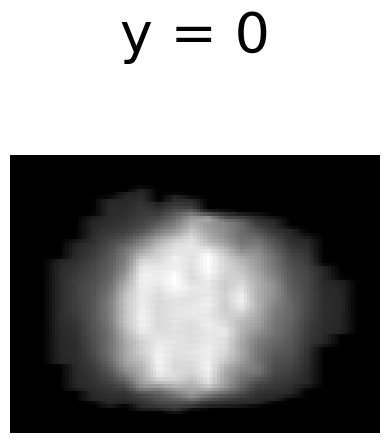

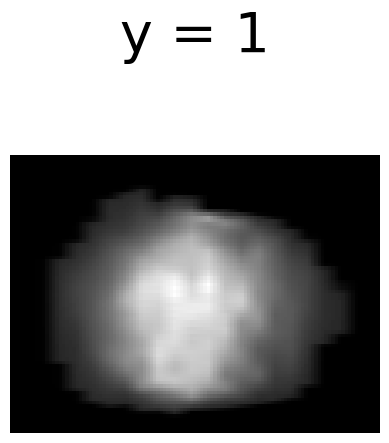

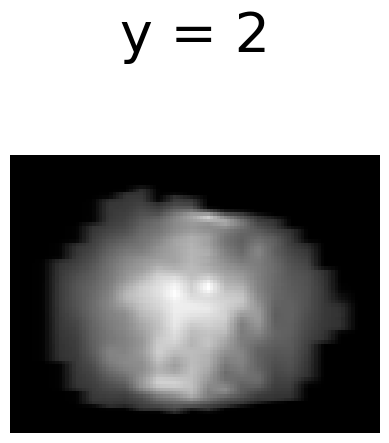

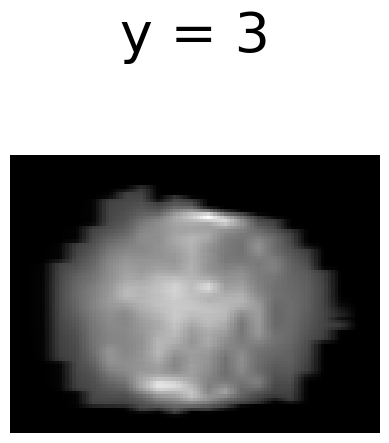

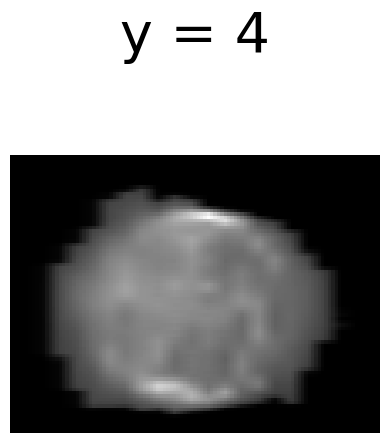

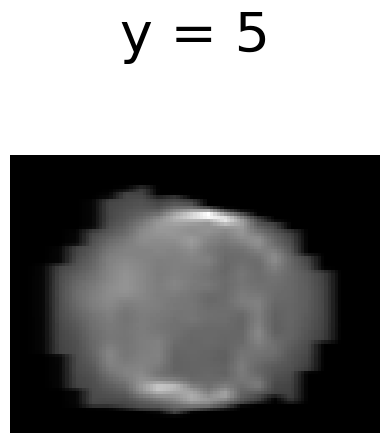

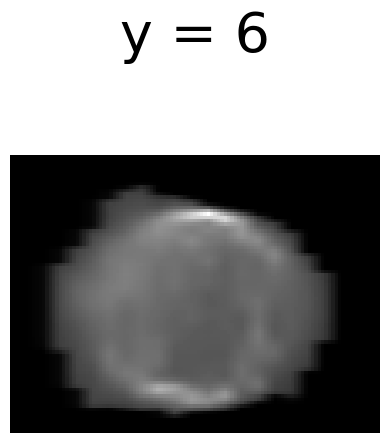

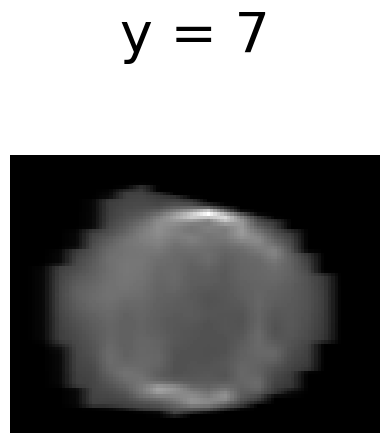

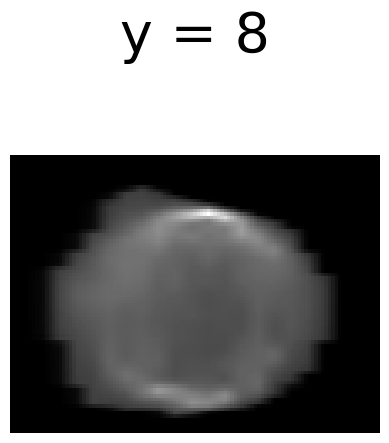

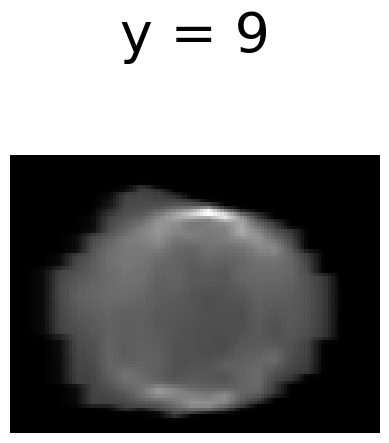

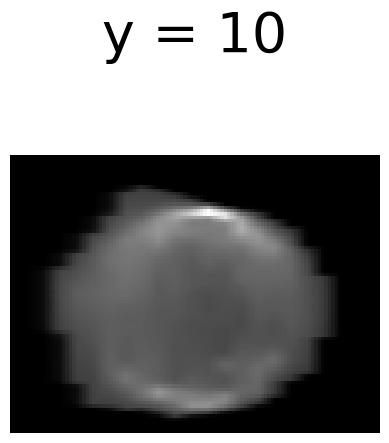

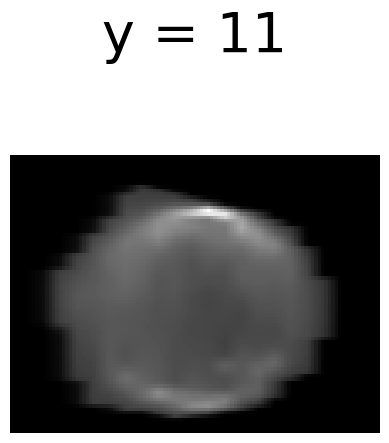

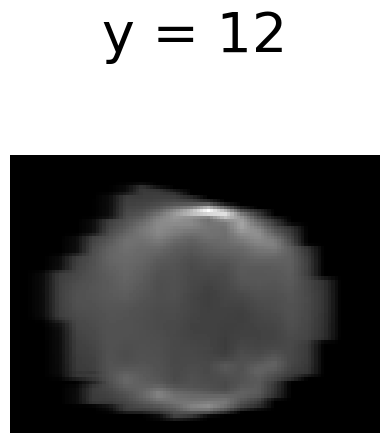

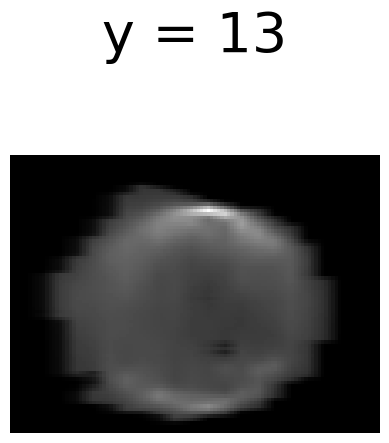

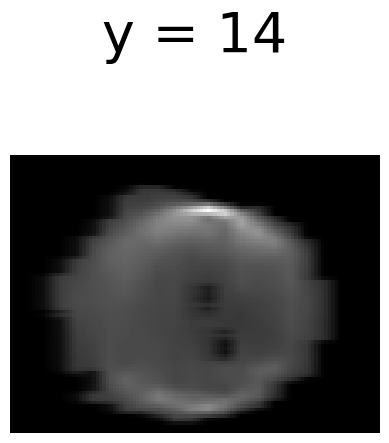

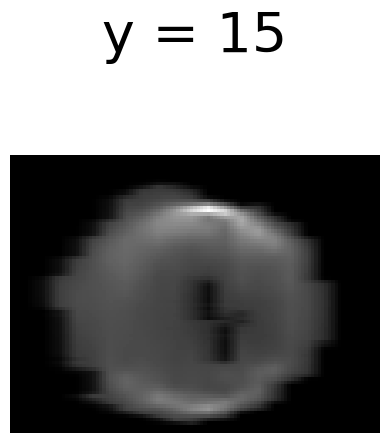

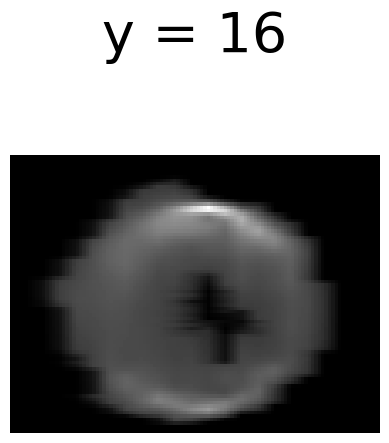

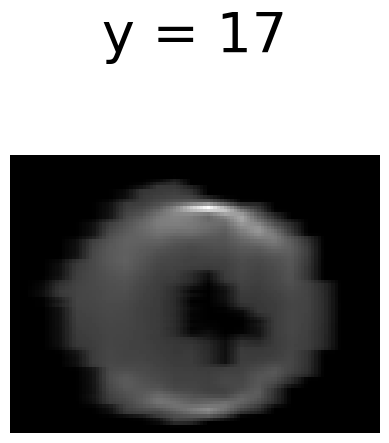

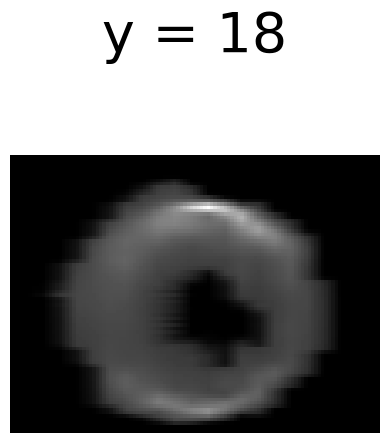

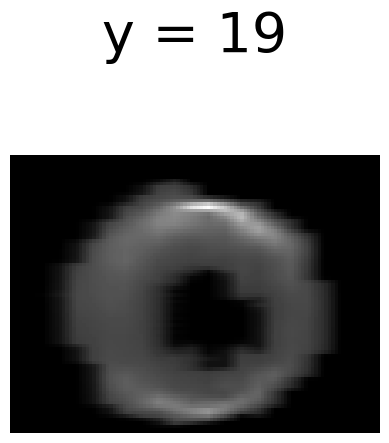

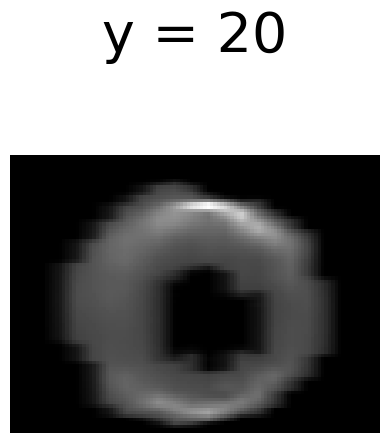

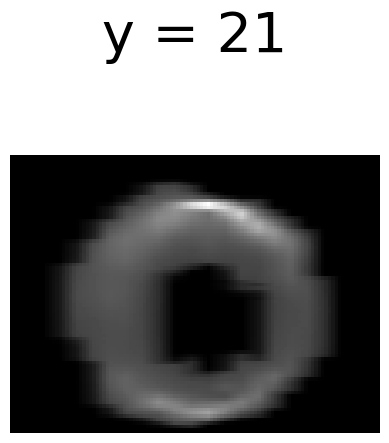

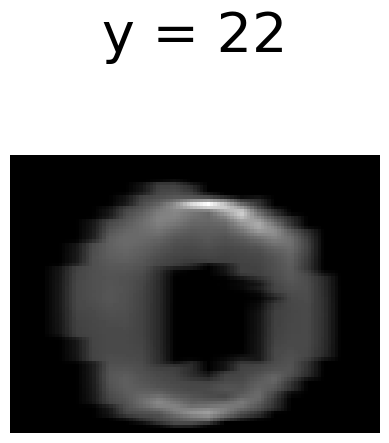

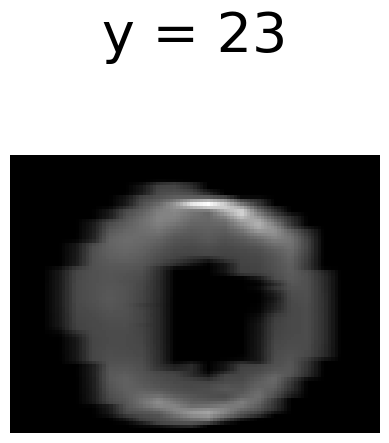

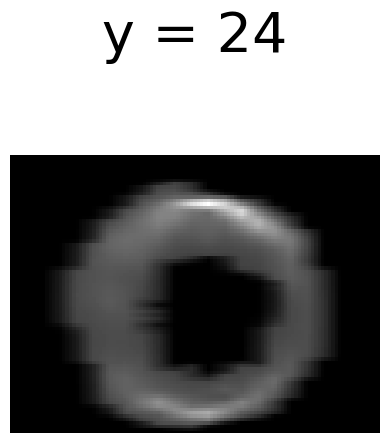

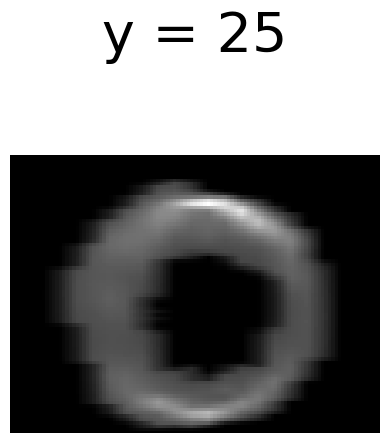

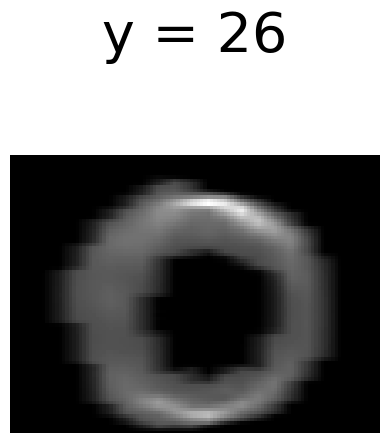

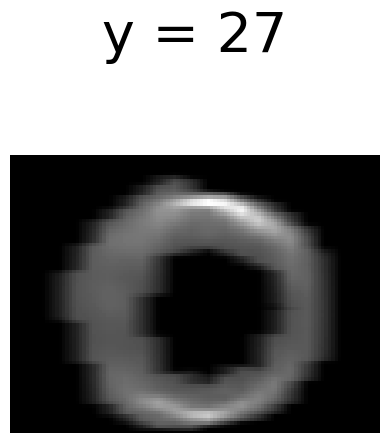

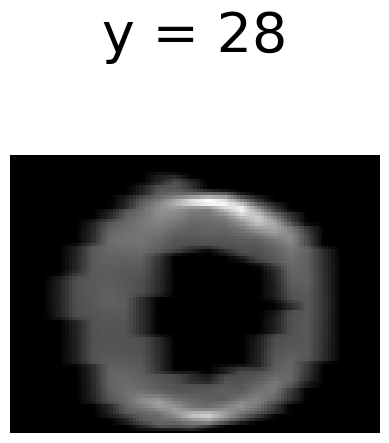

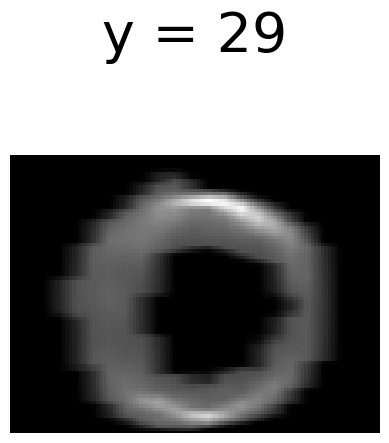

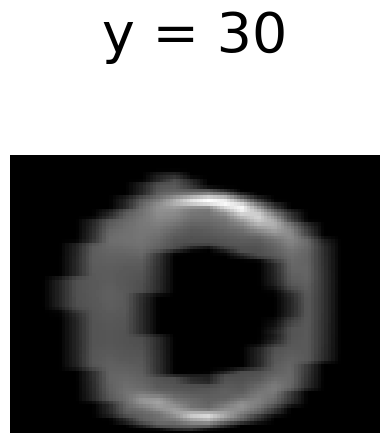

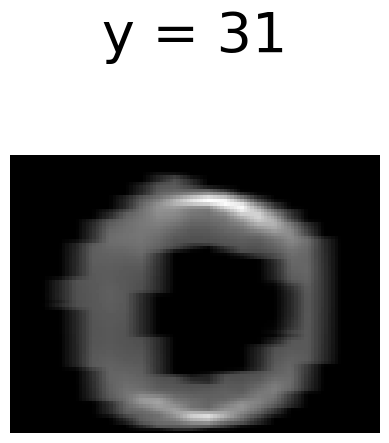

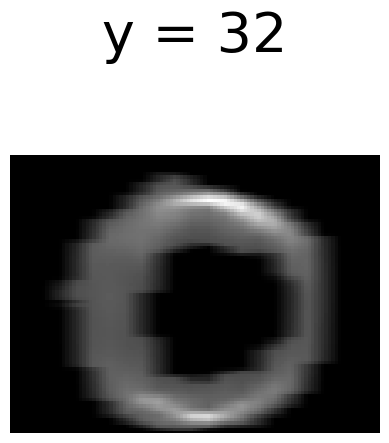

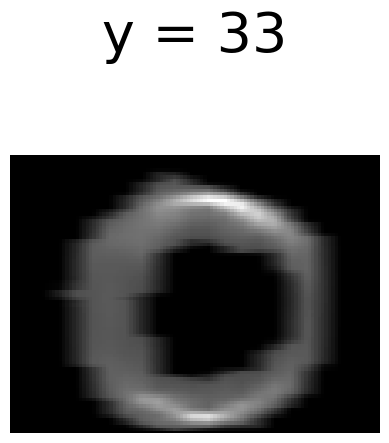

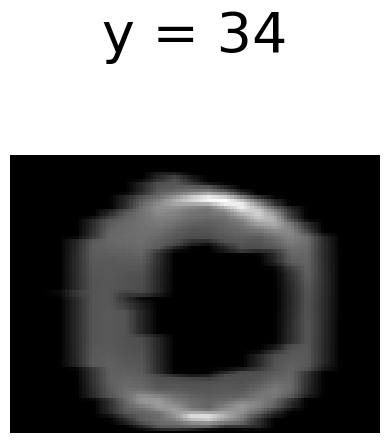

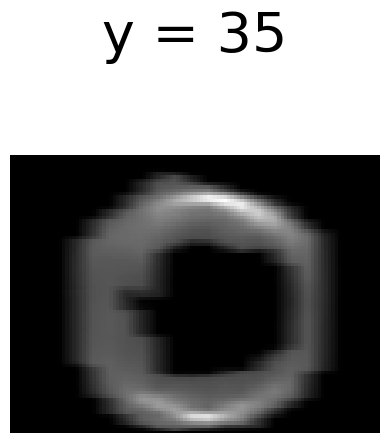

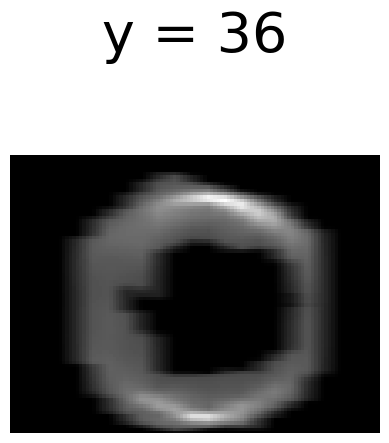

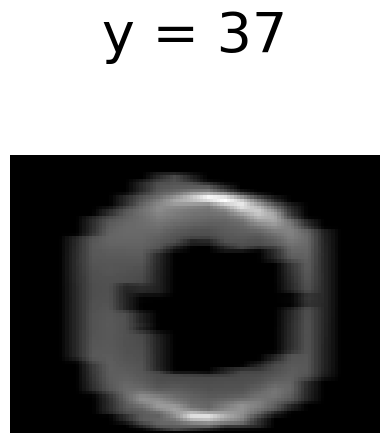

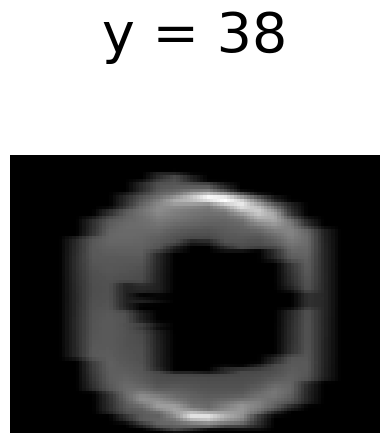

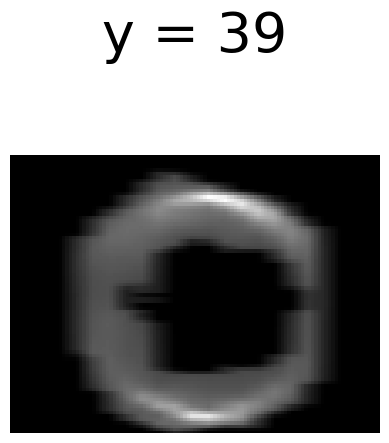

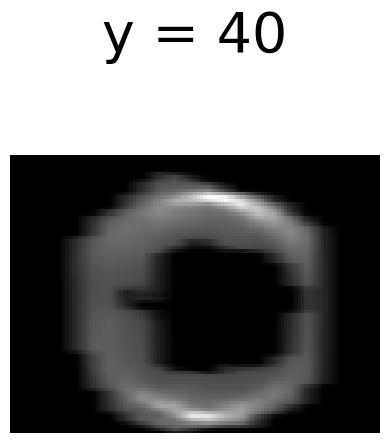

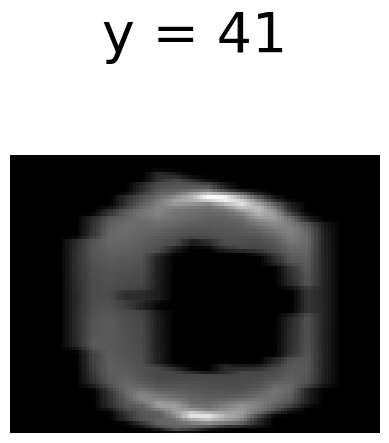

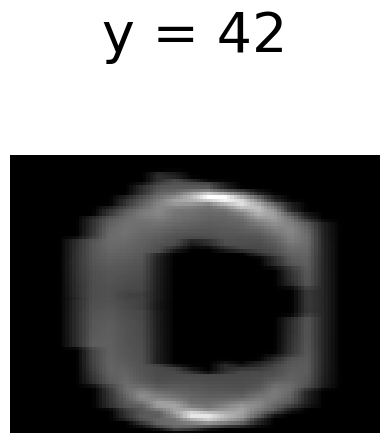

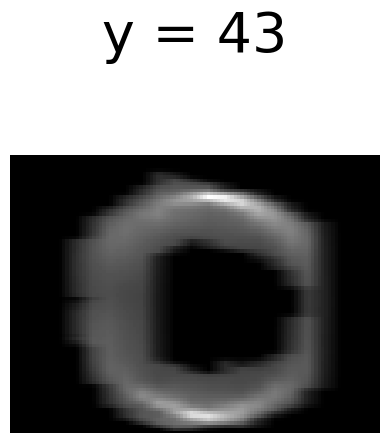

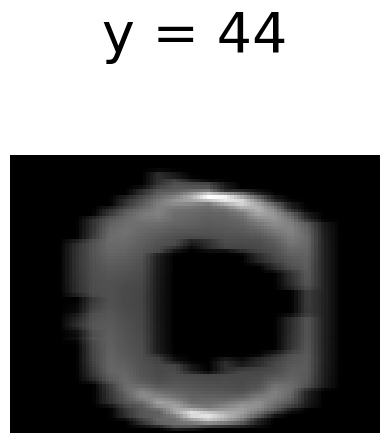

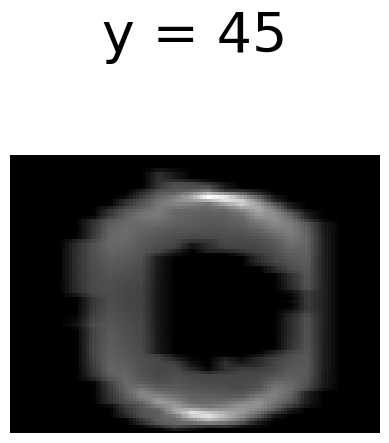

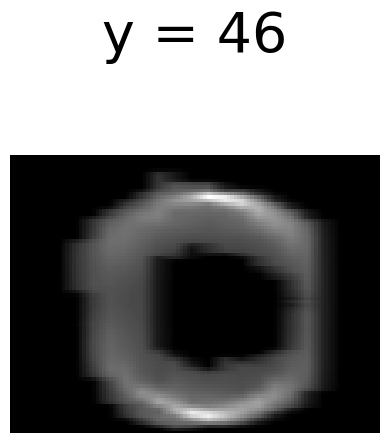

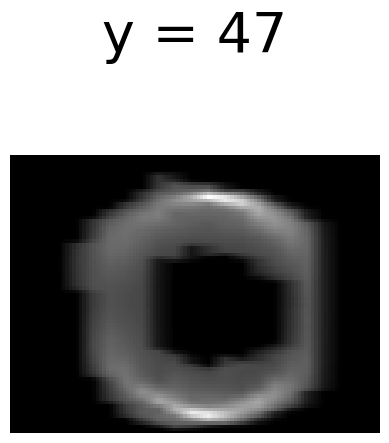

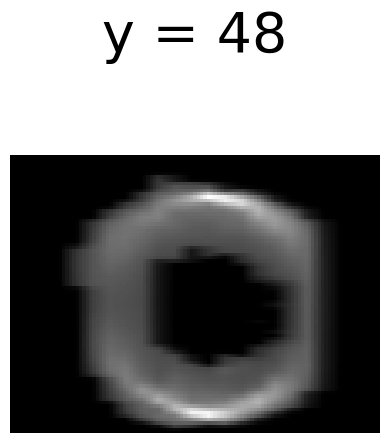

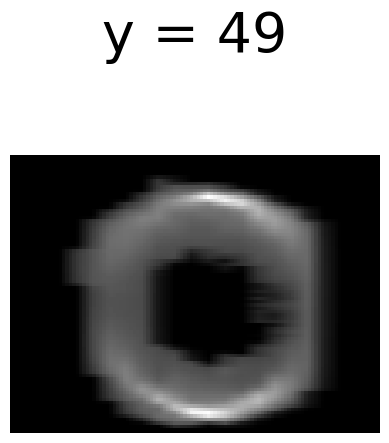

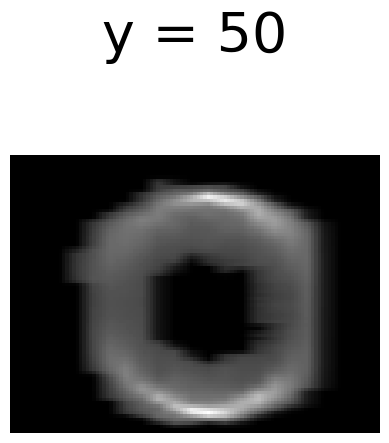

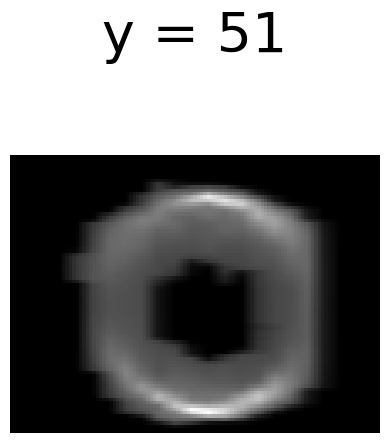

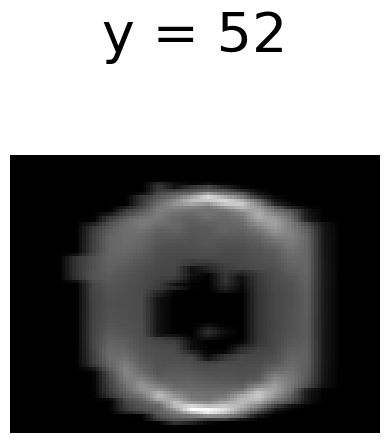

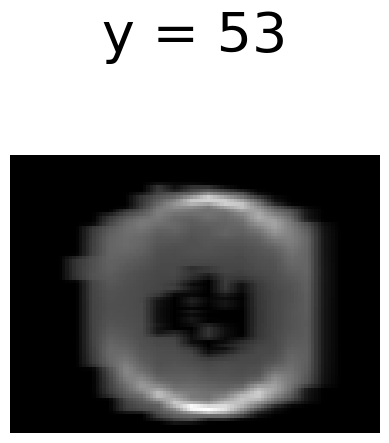

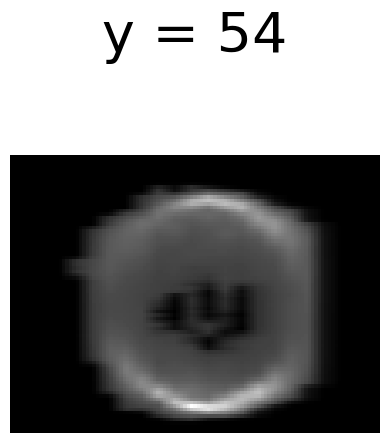

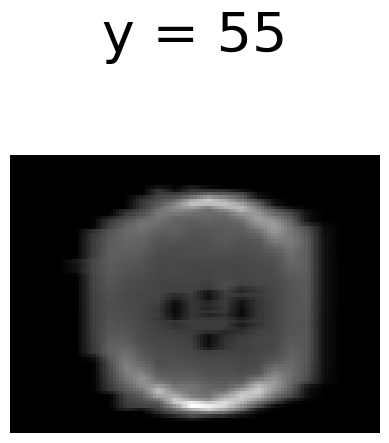

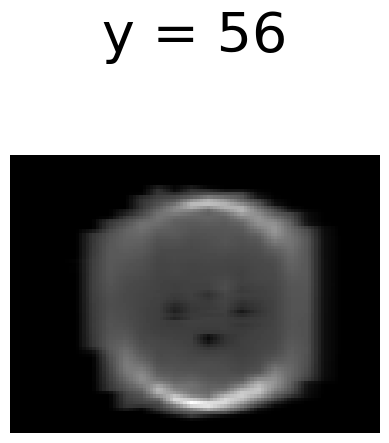

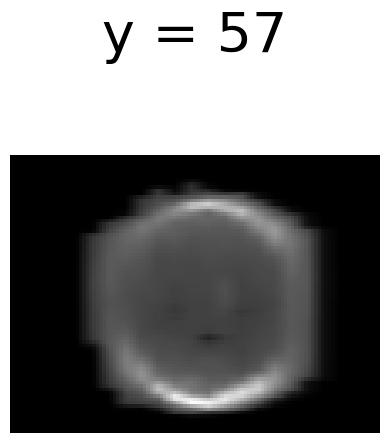

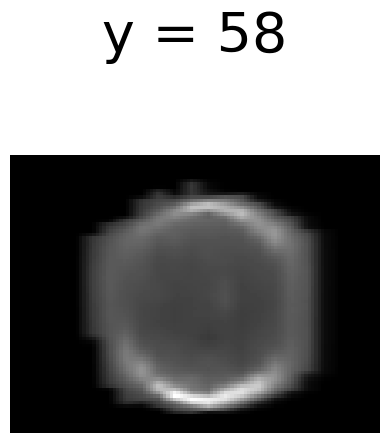

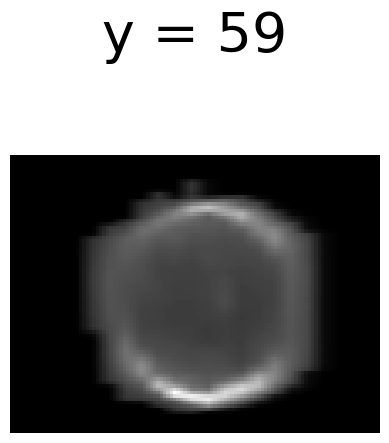

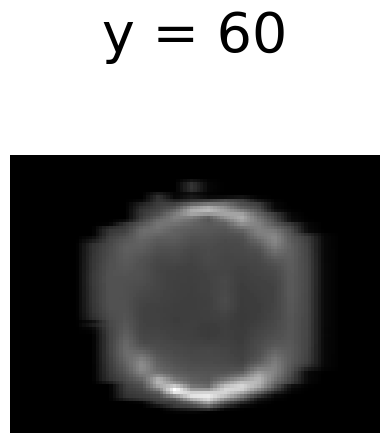

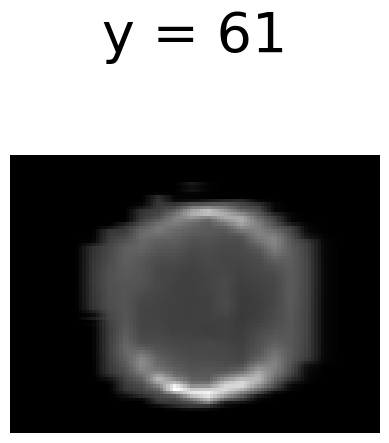

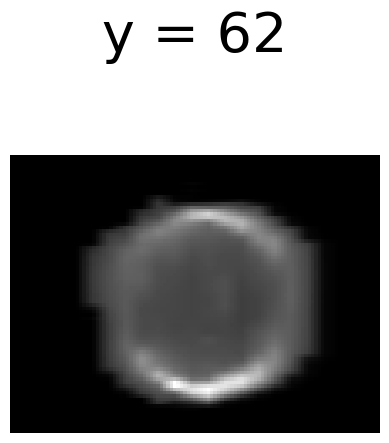

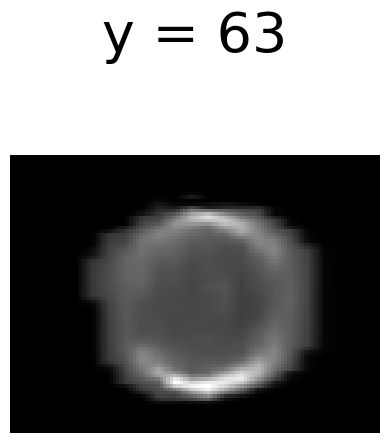

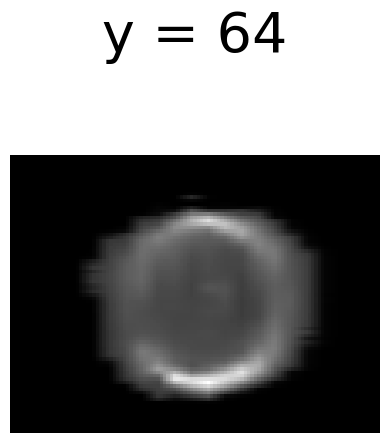

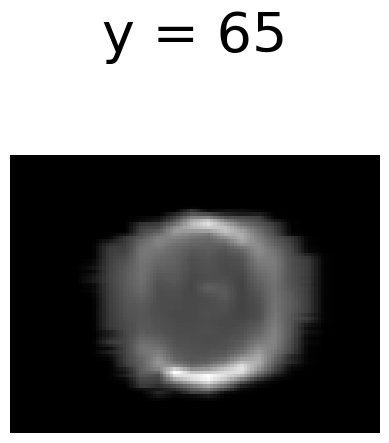

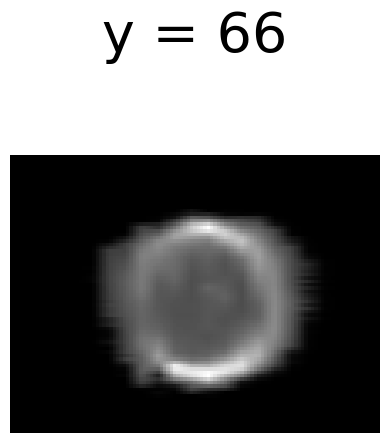

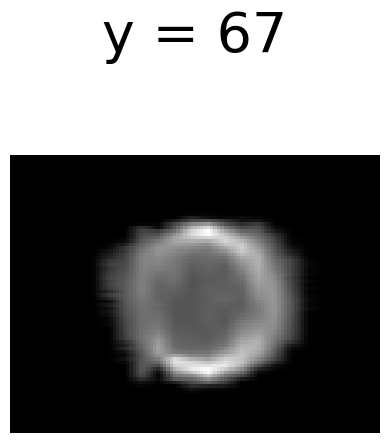

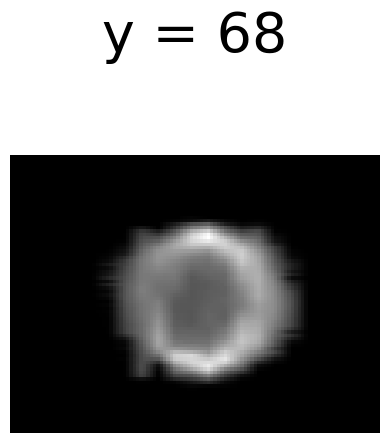

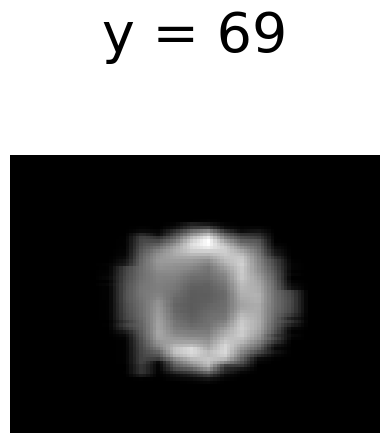

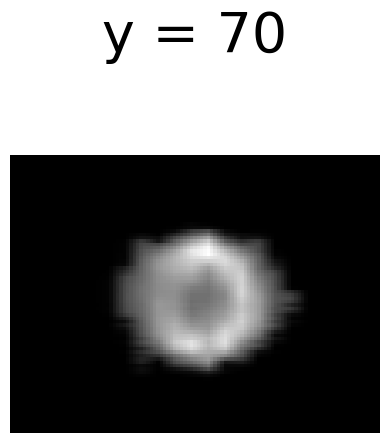

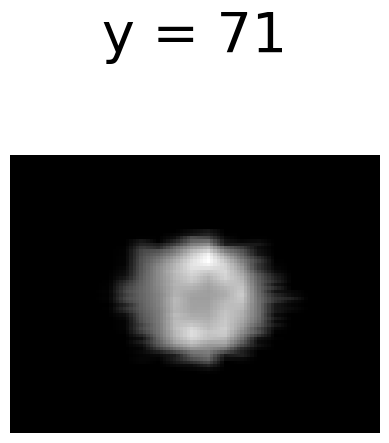

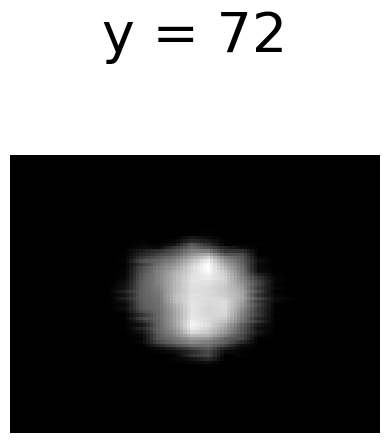

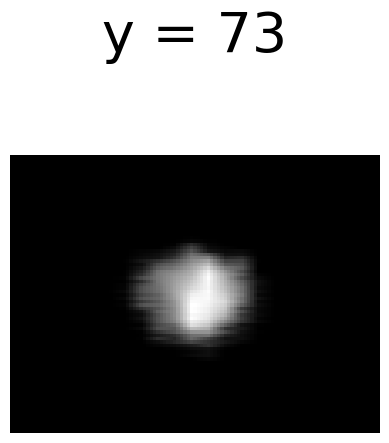

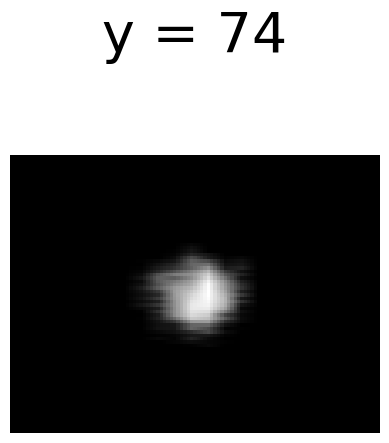

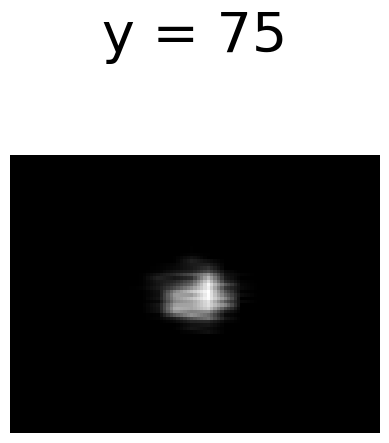

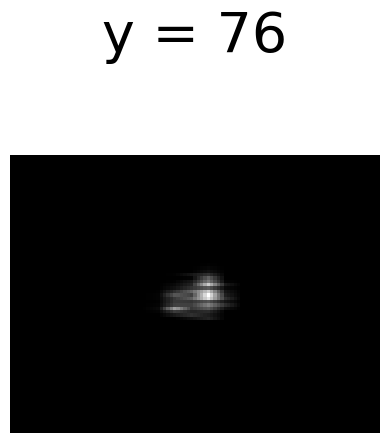

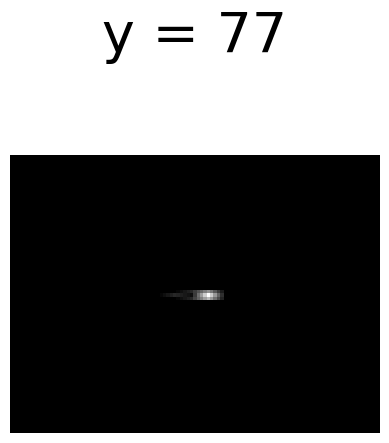

In [64]:
# 【日本語コメント】XZ 断面の z 方向 spacing を線形補間で再サンプリングします。
# 【日本語コメント】0 埋めではなく補間を使うことで、断面の連続性を保ちやすくします。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# 【日本語コメント】z 方向を xy 方向と同じ spacing に近づけるため、線形補間する関数です。
def resample_z_interpolate(slice_xz, dxy, dz):
    """
    slice_xz: shape = (X, Z)
    output: shape = (X, Z_iso)

    将 Z 方向从 dz 重采样到 dxy，
    新位置使用线性插值，不再填 0。
    """
    X, Z = slice_xz.shape

    # 原始 Z 位置（单位：um）
    # 【日本語コメント】元の z slice 位置を物理座標 µm で定義します。
    z_um = np.arange(Z) * dz

    # 新的等间距 Z 位置
    # 【日本語コメント】z 方向を dxy 間隔に換算した後の slice 数を計算します。
    Z_iso = int(np.round((Z - 1) * dz / dxy)) + 1
    z_iso_um = np.arange(Z_iso) * dxy

    # 用 float 做插值，避免整数截断
    # 【日本語コメント】再サンプリング後の XZ 断面を格納する配列を作成します。
    slice_iso = np.zeros((X, Z_iso), dtype=np.float32)

    for x in range(X):
        # 【日本語コメント】線形補間により、各 x 位置で z 方向の値を新しい座標へ写します。
        slice_iso[x, :] = np.interp(
            z_iso_um,   # 新坐标
            z_um,       # 原坐标
            slice_xz[x, :]  # 原数据
        )

    return slice_iso

threshold = np.percentile(cleaned_volume, 0)

X, Y, Z = cleaned_volume.shape

# for z in range(aligned_volume.shape[2]):
# 【日本語コメント】指定した y slice 範囲を順番に処理します。
for y in range(y0,ye):
    # 【日本語コメント】現在の y 位置における XZ 断面を取り出します。
    slice_xz = cleaned_volume[:, y, :]  # (X,Z)

    # 1️⃣ 二值化（threshold 很关键）
    mask = slice_xz > threshold
    # 2️⃣ 连通区域标记
    # 【日本語コメント】連結成分ラベリングを行い、独立した領域を識別します。
    labeled, num = ndimage.label(mask)
    # 3️⃣ 找最大区域
    # 【日本語コメント】各連結成分のサイズを計算します。
    sizes = ndimage.sum(mask, labeled, range(1, num+1))
    if len(sizes) == 0:
        continue
    
    # 【日本語コメント】最も大きい連結成分のラベルを選択します。
    largest_label = np.argmax(sizes) + 1
    # 4️⃣ 只保留最大区域
    mask_clean = (labeled == largest_label)

    if y == 0:
        m0 = mask_clean
    else:
        mask_clean = mask_clean
    # 5️⃣ 应用到原数据
    clean_slice_xz = slice_xz * mask_clean

    # -----------------------------
    # 6. resample XZ slice to isotropic scale
    # -----------------------------
    
    # 【日本語コメント】XZ 断面を z 方向に補間し、等方的な画素サイズに近づけます。
    clean_slice_xz_iso = resample_z_interpolate(
        clean_slice_xz,
        dxy=dxy,
        dz=dz
    )

    # extent = [
    #     0, Z * dz,   # x-axis: X direction, μm
    #     0, X * dxy     # y-axis: Z direction, μm
    # ]

    plt.figure()
    plt.imshow(clean_slice_xz_iso, cmap='gray')
    # plt.imshow(clean_slice_xz, cmap='gray',extent=extent,aspect="equal")
    plt.title(f"y = {y}",fontsize = 40)
    plt.axis('off')
    # plt.xlim([ 0,25])
    # plt.ylim([46,71])
    plt.xlim([xs,xt])
    plt.ylim([ys,yt])
    # plt.savefig("/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig2/slice/" + "%04d" % (y) + ".svg", bbox_inches='tight',dpi = 100)
    # plt.savefig("/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig2/slice_orginal/" + "%04d" % (y) + ".svg", bbox_inches='tight',dpi = 100)
    plt.show()

In [65]:
# 【日本語コメント】楕円フィッティングに使う補助関数をまとめて定義します。
# 【日本語コメント】径方向探索で候補境界点を抽出し、DBSCAN で外れ点を除き、楕円近似の誤差を計算します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
from sklearn.cluster import DBSCAN
# radial_ray_search()：只负责径向射线搜索，输出候选边界点
# filter_points_by_dbscan()：只负责 DBSCAN 聚类，输出主点堆
# fit_ellipse_universal()：调用前两个函数，再拟合椭圆


# 【日本語コメント】画像中心付近から放射状に探索し、候補境界点を取得する関数です。
def radial_ray_search(image,threshold_percentile=85,num_rays=120,center_pt=None,min_r=10,use_intensity_centroid=False):
    """
    径向射线搜索：
    从图像边缘向中心扫描，寻找每条射线上第一个超过阈值的点。

    Parameters
    ----------
    image : 2D ndarray
        输入灰度图像
    threshold_percentile : float
        阈值百分位数
    num_rays : int
        射线数量
    center_pt : tuple or None
        射线发射中心，格式为 (x, y)
        如果为 None，则使用图像中心
    min_r : int
        搜索的最小半径，避免搜索到中心附近

    Returns
    -------
    pts : ndarray, shape (N, 2)
        搜索得到的候选边界点，格式为 [[x, y], ...]
    img_uint8 : ndarray
        归一化后的 uint8 图像
    threshold_value : float
        使用的阈值
    """


    # img_uint8 = cv2.normalize(
    #     image.astype("float32"),
    #     None,
    #     0,
    #     255,
    #     cv2.NORM_MINMAX
    # ).astype(np.uint8)

    # h, w = img_uint8.shape

    # # -----------------------------
    # # intensity center
    # # -----------------------------
    # if center_pt is None:
    #     yy, xx = np.indices(img_uint8.shape)

    #     weight = img_uint8.astype(np.float32)
    #     total_intensity = np.sum(weight)

    #     if total_intensity > 0:
    #         center_x = np.sum(xx * weight) / total_intensity
    #         center_y = np.sum(yy * weight) / total_intensity
    #         center_pt = (int(center_x), int(center_y))
    #     else:
    #         center_pt = (w // 2, h // 2)

    # threshold_value = np.percentile(img_uint8, threshold_percentile)

    # all_points = []

    # max_r = int(min(w, h) / 2)

    # for i in range(num_rays):
    #     angle = np.deg2rad(i * (360 / num_rays))
    #     dx, dy = np.cos(angle), np.sin(angle)

    #     for r in range(max_r, min_r, -1):
    #         curr_x = int(center_pt[0] + r * dx)
    #         curr_y = int(center_pt[1] + r * dy)

    #         if 0 <= curr_x < w and 0 <= curr_y < h:
    #             if img_uint8[curr_y, curr_x] > threshold_value:
    #                 all_points.append([curr_x, curr_y])
    #                 break

    # pts = np.array(all_points)

    # return pts, img_uint8, threshold_value, center_pt

    """
    径向射线搜索：
    从图像边缘向中心扫描，寻找每条射线上第一个超过阈值的点。

    如果 center_pt 为 None，则使用 intensity 大于 threshold_percentile
    的区域重心作为射线发射中心。
    """

    img_uint8 = cv2.normalize(
        image.astype("float32"),
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    h, w = img_uint8.shape

    # 【日本語コメント】0 以外の voxel 値を取り出し、しきい値計算に使います。
    nonzero_vals = img_uint8[img_uint8 > 0]
    
    if len(nonzero_vals) > 0:
        threshold_value = np.percentile(nonzero_vals, threshold_percentile)
    else:
        threshold_value = 0
    
    # threshold_value = np.percentile(img_uint8, threshold_percentile)

    # -----------------------------
    # 根据高 intensity 区域计算重心
    # -----------------------------
    if center_pt is None:
        mask = img_uint8 > threshold_value

        ys, xs = np.where(mask)

        if len(xs) > 0:
            if use_intensity_centroid:
                # intensity 加权重心
                weights = img_uint8[ys, xs].astype(np.float32)

                cx = np.sum(xs * weights) / np.sum(weights)
                cy = np.sum(ys * weights) / np.sum(weights)
            else:
                # 普通几何重心
                cx = np.mean(xs)
                cy = np.mean(ys)

            center_pt = (int(round(cx)), int(round(cy)))

        else:
            # 如果没有高于阈值的区域，则退回图像中心
            center_pt = (w // 2, h // 2)

    all_points = []

    max_r = int(min(w, h) / 2)

    for i in range(num_rays):
        angle = np.deg2rad(i * (360 / num_rays))
        dx, dy = np.cos(angle), np.sin(angle)

        for r in range(max_r, min_r, -1):
            curr_x = int(center_pt[0] + r * dx)
            curr_y = int(center_pt[1] + r * dy)

            if 0 <= curr_x < w and 0 <= curr_y < h:
                if img_uint8[curr_y, curr_x] > threshold_value:
                    all_points.append([curr_x, curr_y])
                    break

    pts = np.array(all_points)

    return pts, img_uint8, threshold_value, center_pt

# def radial_ray_search(image,threshold_percentile=85,num_rays=120,center_pt=None,min_r=10):
#     """
#     径向射线搜索：
#     先根据 intensity > threshold_percentile 的区域计算中心，
#     再以该中心作为射线发射中心，从外向内扫描边界点。

#     Parameters
#     ----------
#     image : 2D ndarray
#         输入灰度图像
#     threshold_percentile : float
#         阈值百分位数
#     num_rays : int
#         射线数量
#     center_pt : tuple or None
#         射线发射中心，格式为 (x, y)
#         如果为 None，则自动使用高强度区域的中心
#     min_r : int
#         搜索的最小半径，避免搜索到中心附近

#     Returns
#     -------
#     pts : ndarray, shape (N, 2)
#         径向搜索得到的候选边界点，格式为 [[x, y], ...]
#     img_uint8 : ndarray
#         归一化后的 uint8 图像
#     threshold_value : float
#         使用的阈值
#     center_pt : tuple
#         实际使用的射线发射中心，格式为 (x, y)
#     """

#     img_uint8 = cv2.normalize(
#         image.astype("float32"),
#         None,
#         0,
#         255,
#         cv2.NORM_MINMAX
#     ).astype(np.uint8)

#     h, w = img_uint8.shape

#     threshold_value = np.percentile(img_uint8, threshold_percentile)

#     # --------------------------------------------------
#     # 1. 如果没有指定 center_pt，则自动计算高强度区域中心
#     # --------------------------------------------------
#     if center_pt is None:
#         mask = img_uint8 > threshold_value

#         ys, xs = np.where(mask)

#         if len(xs) > 0:
#             center_x = int(np.mean(xs))
#             center_y = int(np.mean(ys))
#             center_pt = (center_x, center_y)
#         else:
#             # 如果没有找到高强度区域，则退回图像中心
#             center_pt = (w // 2, h // 2)

#     # --------------------------------------------------
#     # 2. 径向射线搜索
#     # --------------------------------------------------
#     all_points = []

#     max_r = int(min(w, h) / 2)

#     for i in range(num_rays):
#         angle = np.deg2rad(i * (360 / num_rays))
#         dx, dy = np.cos(angle), np.sin(angle)

#         for r in range(max_r, min_r, -1):
#             curr_x = int(center_pt[0] + r * dx)
#             curr_y = int(center_pt[1] + r * dy)

#             if 0 <= curr_x < w and 0 <= curr_y < h:
#                 if img_uint8[curr_y, curr_x] > threshold_value:
#                     all_points.append([curr_x, curr_y])
#                     break

#     pts = np.array(all_points)

#     return pts, img_uint8, threshold_value, center_pt

# 【日本語コメント】DBSCAN により候補点群から主要クラスタだけを抽出する関数です。
def filter_points_by_dbscan(pts,eps=10,min_samples=5):
    """
    使用 DBSCAN 对径向搜索得到的点进行聚类，
    并保留点数最多的主点堆。

    Parameters
    ----------
    pts : ndarray, shape (N, 2)
        输入点集，格式为 [[x, y], ...]
    eps : float
        DBSCAN 中点与点之间的最大距离
    min_samples : int
        DBSCAN 中形成核心点所需的最小邻域点数

    Returns
    -------
    final_pts : ndarray
        主点堆中的点
    labels : ndarray
        每个点的 DBSCAN 标签
    main_label : int or None
        主点堆的标签
    """

    if pts is None or len(pts) < 5:
        return np.array([]), None, None

    clustering = DBSCAN(
        eps=eps,
        min_samples=min_samples
    ).fit(pts)

    labels = clustering.labels_

    unique_labels, counts = np.unique(
        labels[labels != -1],
        return_counts=True
    )

    if len(counts) == 0:
        return np.array([]), labels, None

    main_label = unique_labels[np.argmax(counts)]
    final_pts = pts[labels == main_label]

    return final_pts, labels, main_label

# 【日本語コメント】楕円フィット結果に対する点群の RMSE を計算する関数です。
def calculate_ellipse_rmse(pts, ellipse, dxy):
    """
    计算点集到拟合椭圆边缘的均方根误差 (RMSE)
    :param pts: 轮廓点集, 形状为 (N, 2)
    :param ellipse: cv2.fitEllipse 的返回值 ((xc, yc), (MA, ma), angle)
    :return: rmse 精度数值
    """
    (xc, yc), (MA, ma), angle = ellipse
    a = MA / 2.0  # 半长轴
    b = ma / 2.0  # 半短轴
    theta = np.deg2rad(angle)

    # 1. 将点集平移到以椭圆中心为原点的坐标系
    pts_shifted = pts - np.array([xc, yc])

    # 2. 构造旋转矩阵，将点集旋转到与椭圆长短轴对齐
    # 注意：需使用负角度进行反向旋转
    cos_t = np.cos(-theta)
    sin_t = np.sin(-theta)
    R = np.array([[cos_t, -sin_t], [sin_t, cos_t]])
    pts_rot = pts_shifted @ R.T

    # 3. 计算每个点对应的方位角 phi
    phi = np.arctan2(pts_rot[:, 1], pts_rot[:, 0])

    # 4. 计算在该角度下，椭圆边缘到中心的距离 (极坐标半径)
    # 椭圆极坐标公式: r(phi) = (a*b) / sqrt((b*cos(phi))^2 + (a*sin(phi))^2)
    r_ellipse = (a * b) / np.sqrt((b * np.cos(phi))**2 + (a * np.sin(phi))**2)

    # 5. 计算点到中心的距离
    r_point = np.sqrt(pts_rot[:, 0]**2 + pts_rot[:, 1]**2)

    # 6. 计算偏差的平方
    errors_sq = (r_point*dxy - r_ellipse*dxy)**2

    # 7. 计算均方根误差
    rmse = np.sqrt(np.mean(errors_sq))
    return rmse

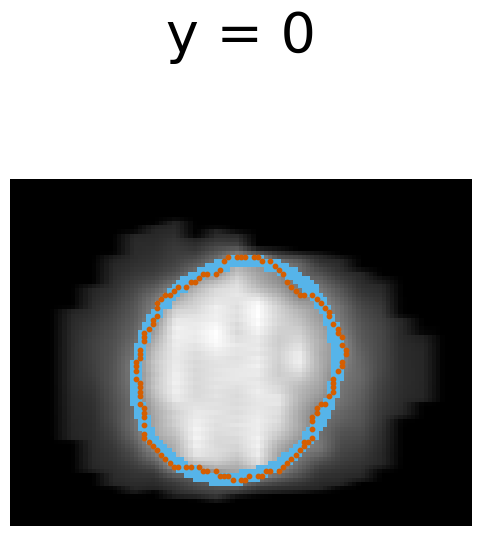

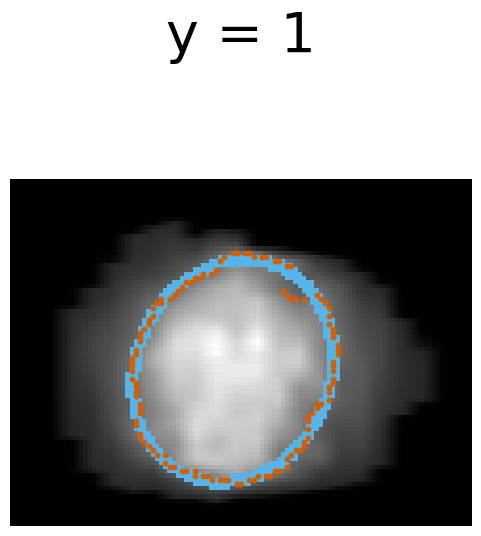

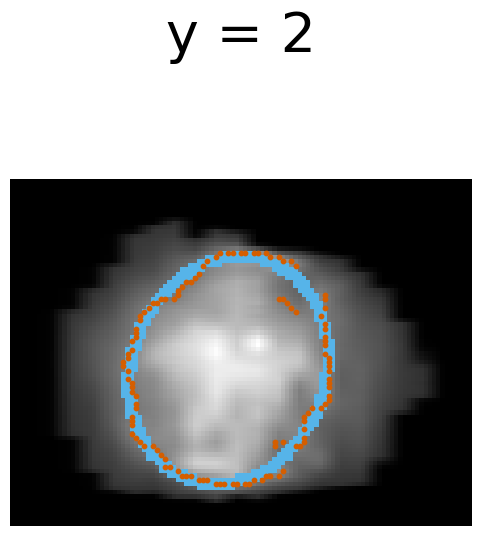

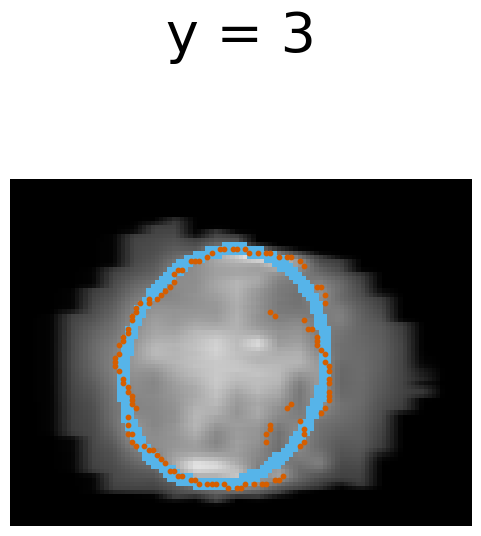

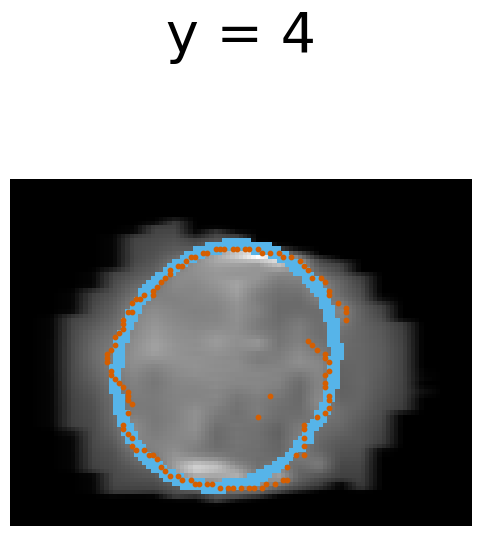

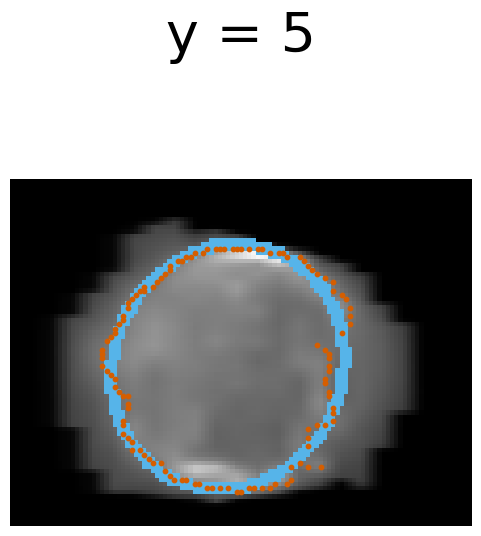

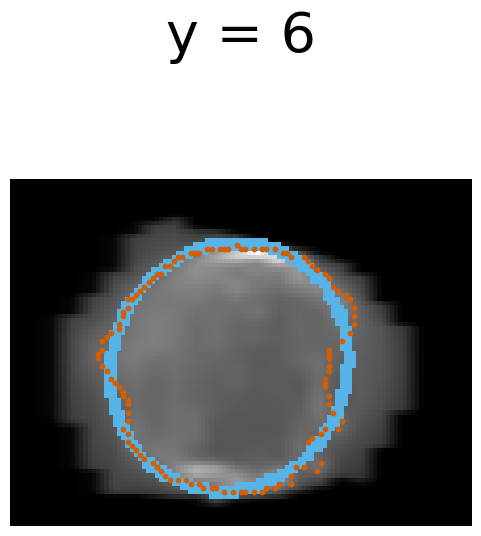

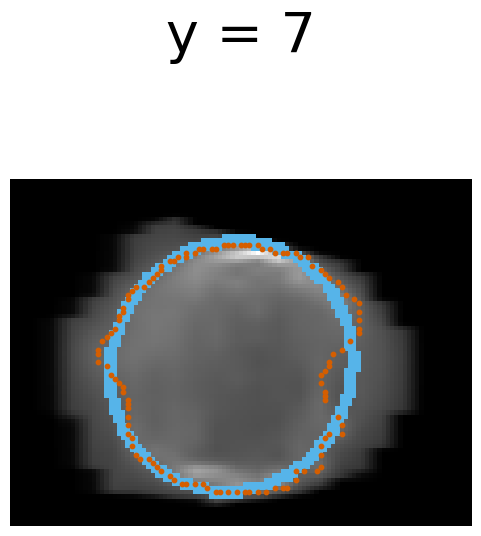

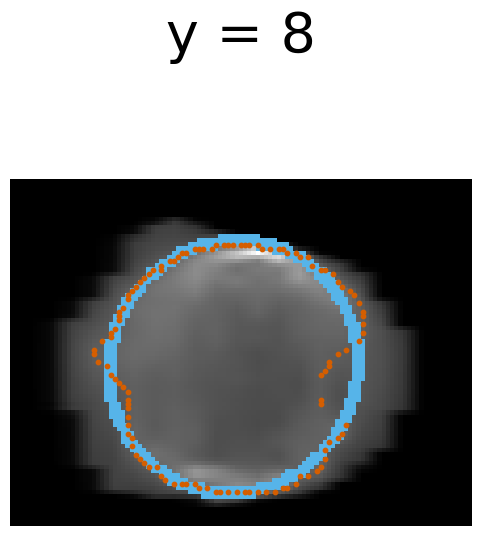

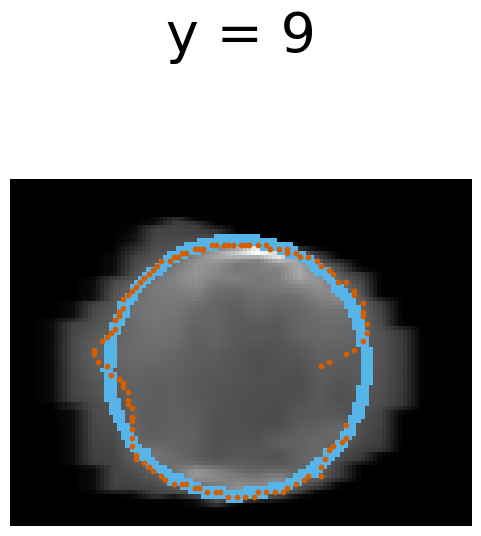

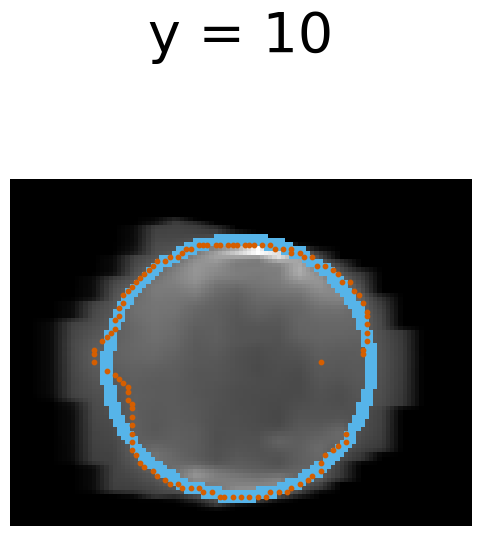

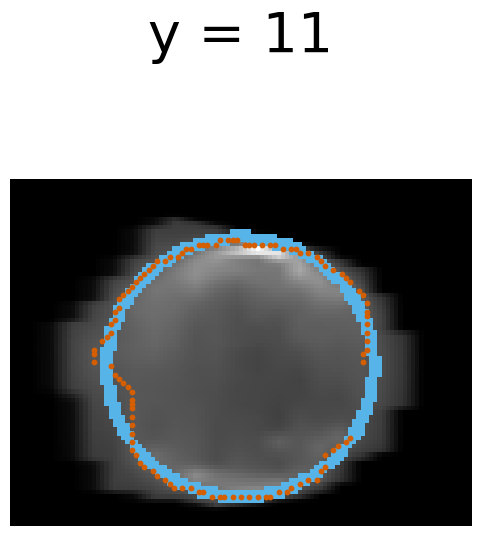

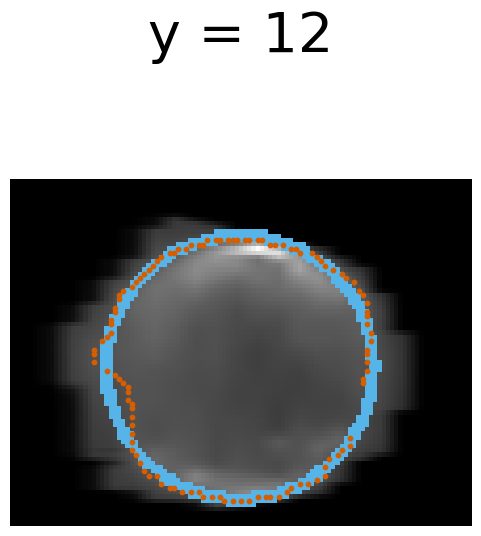

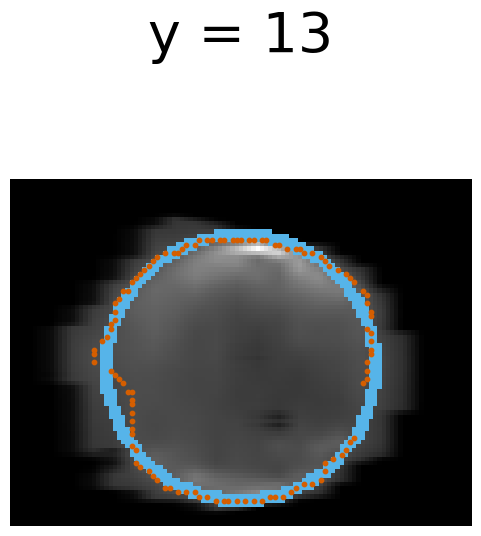

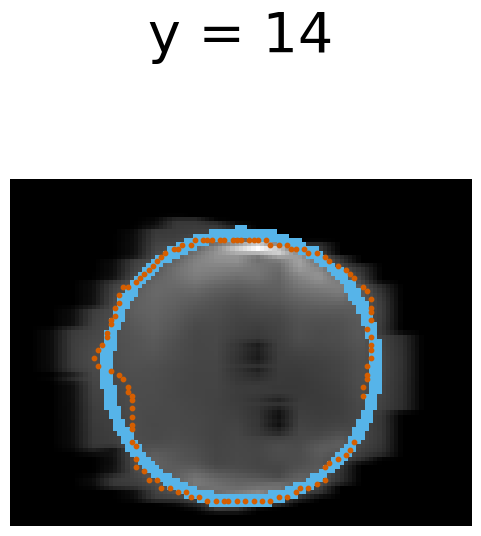

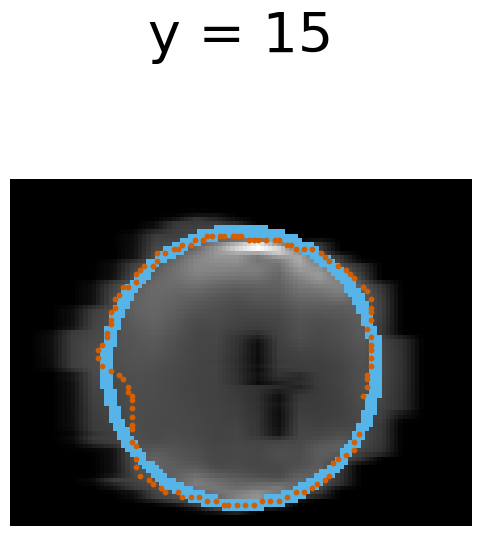

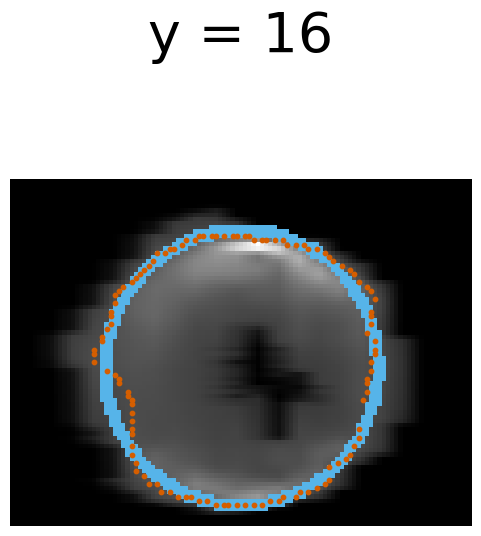

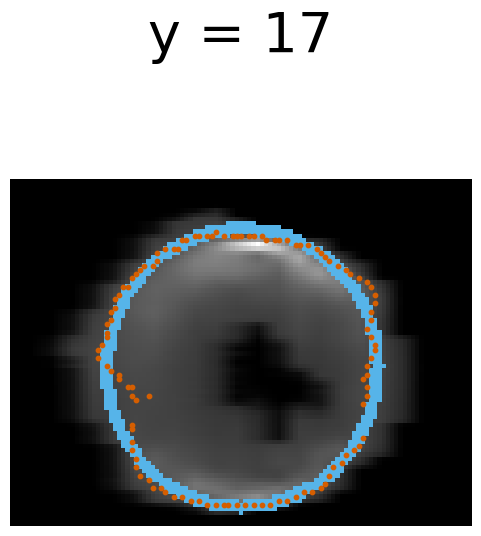

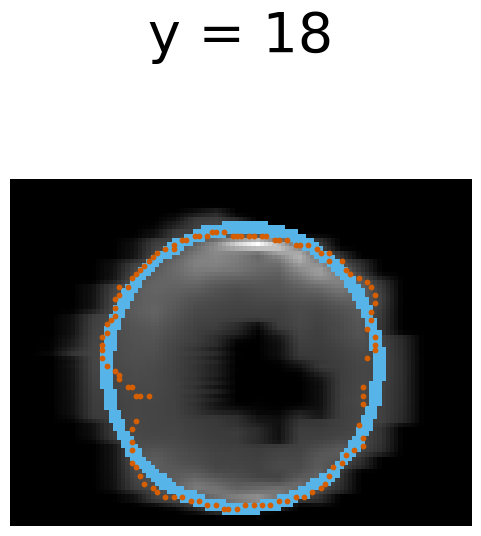

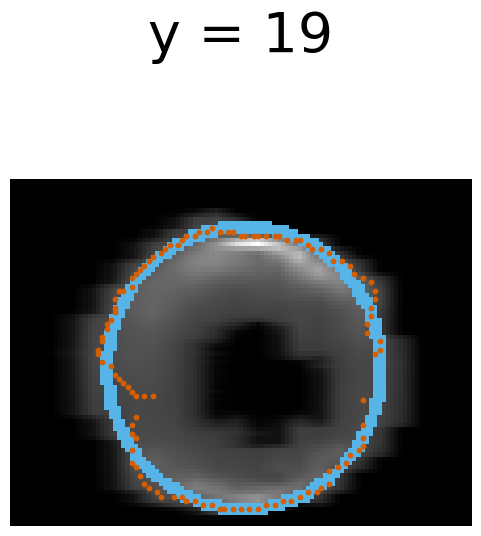

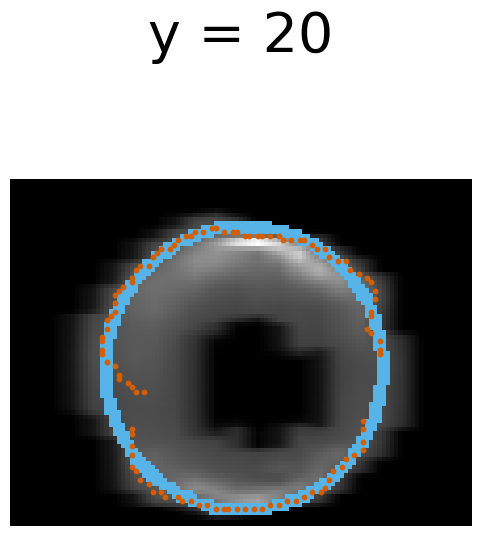

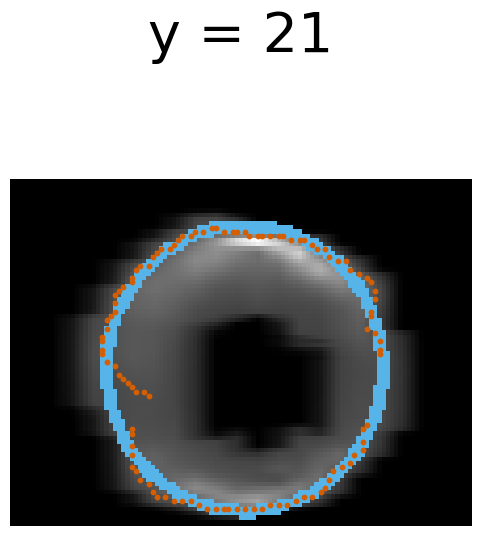

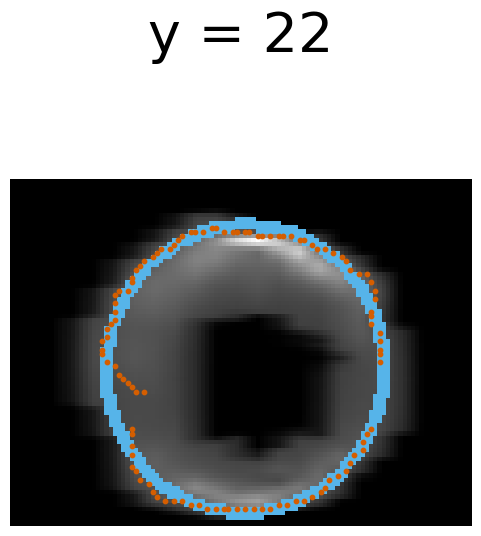

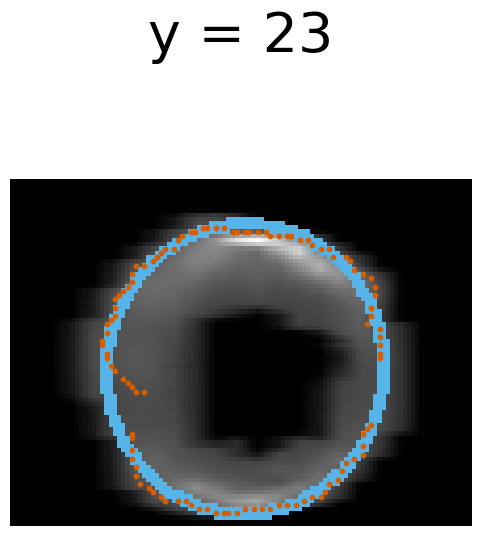

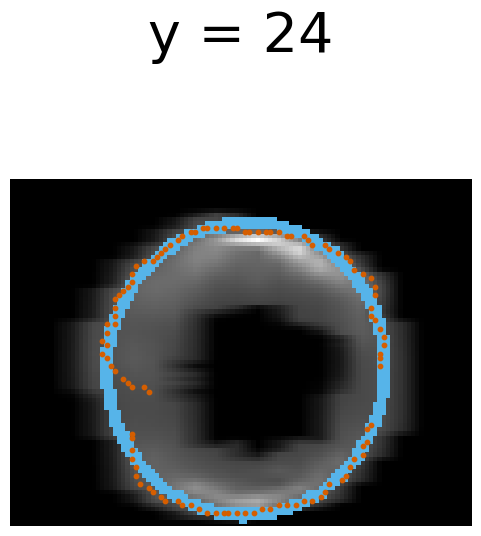

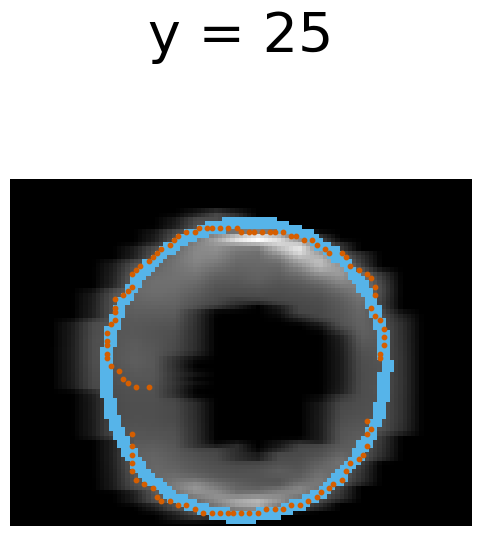

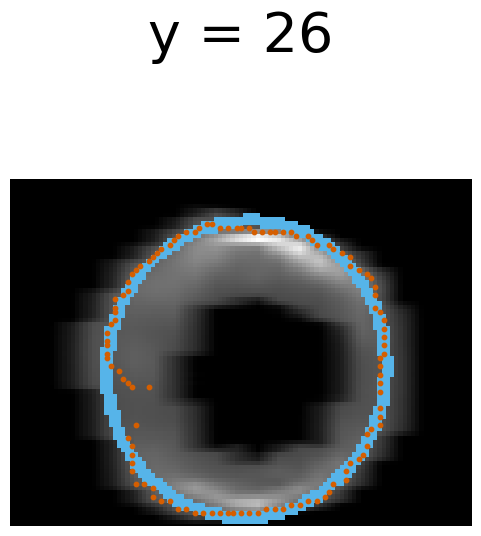

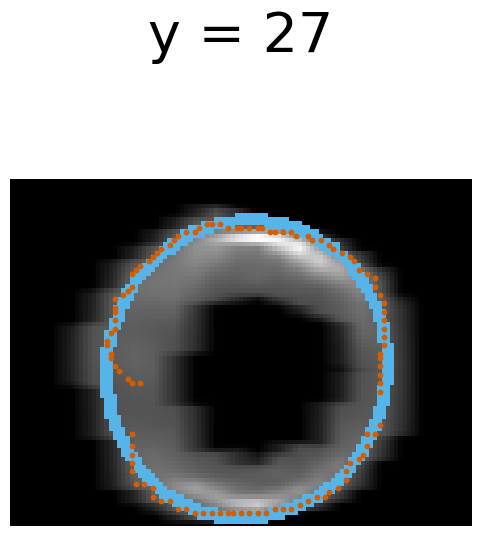

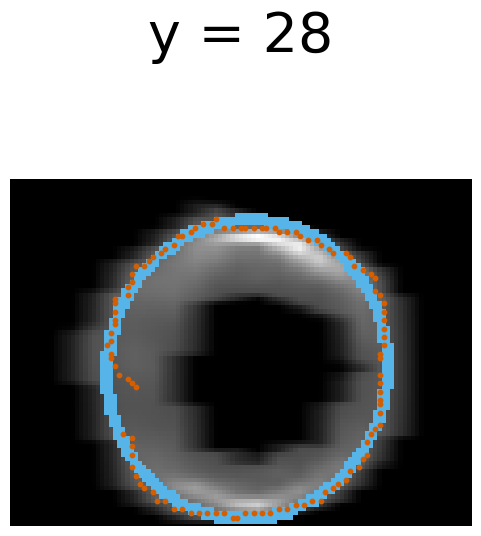

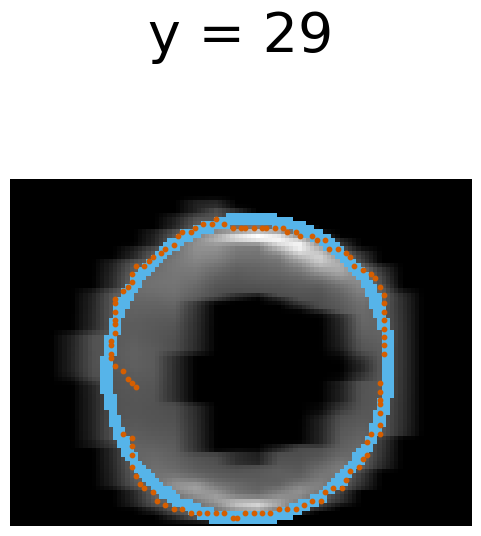

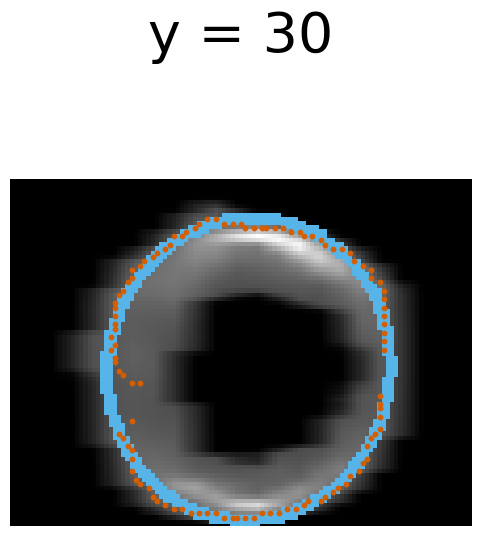

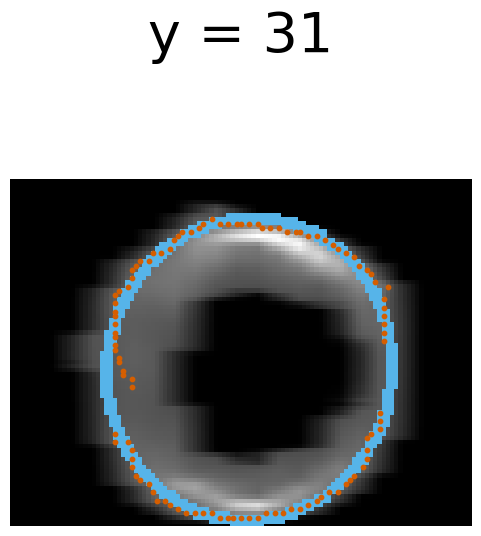

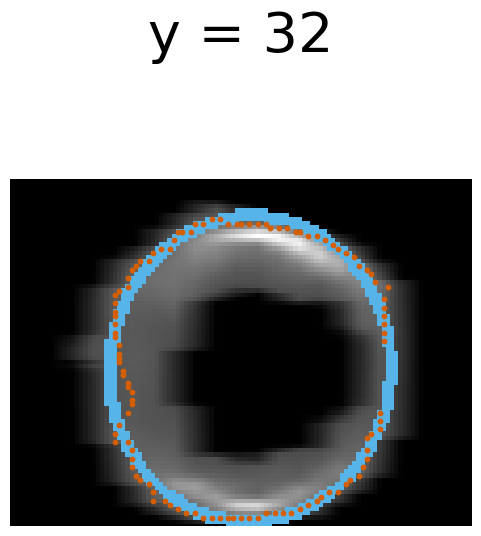

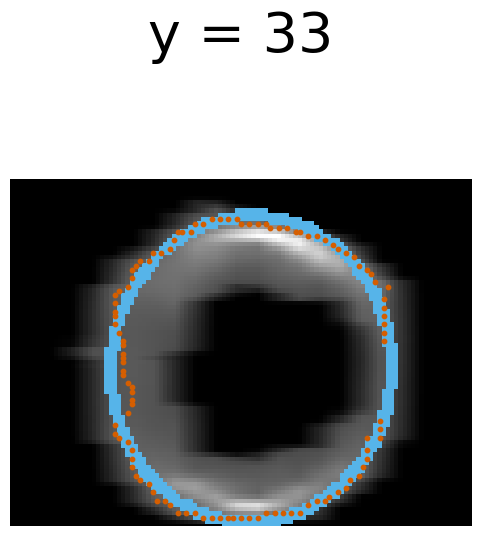

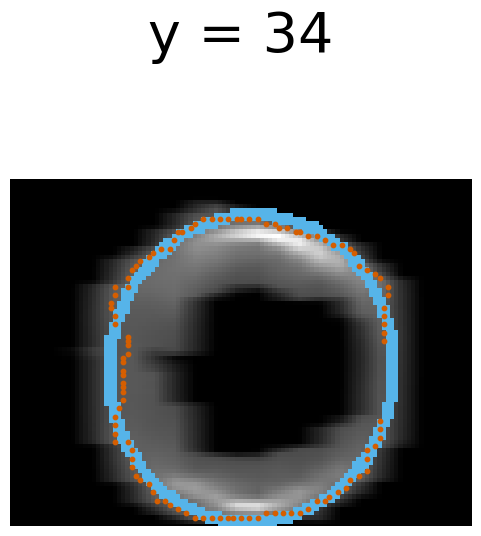

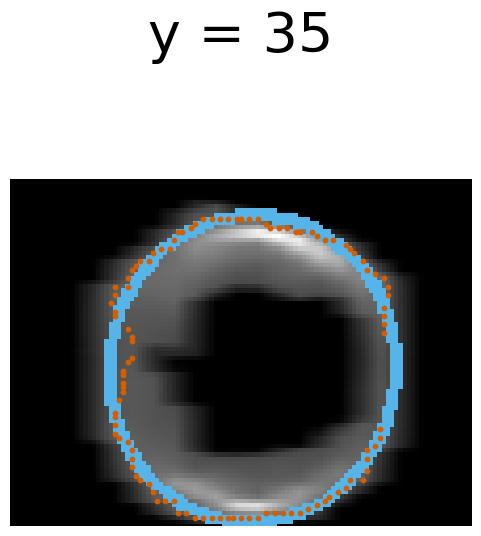

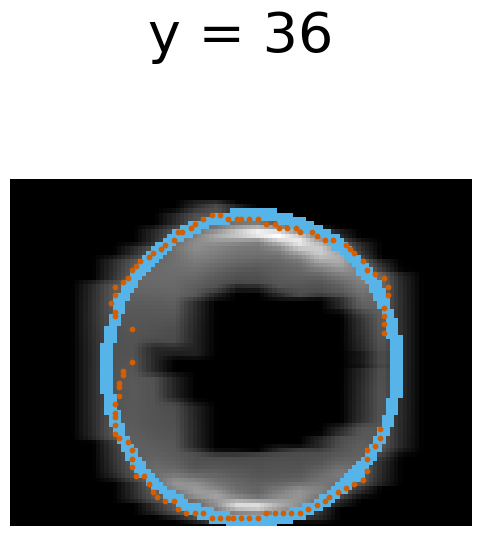

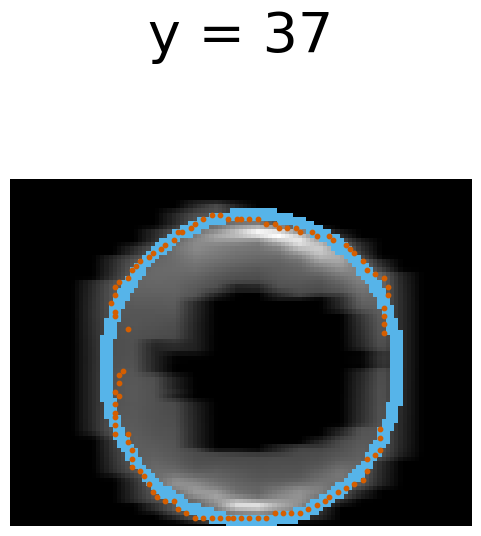

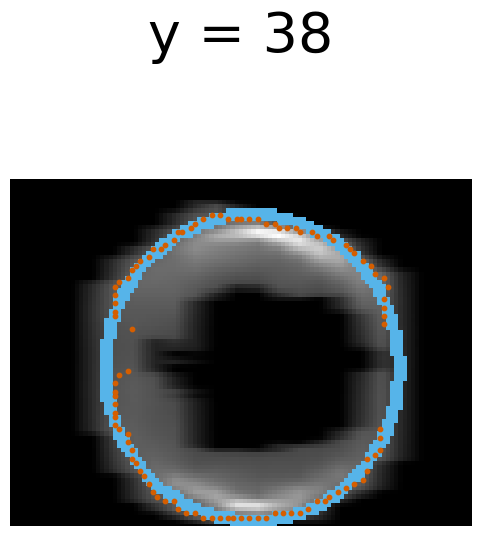

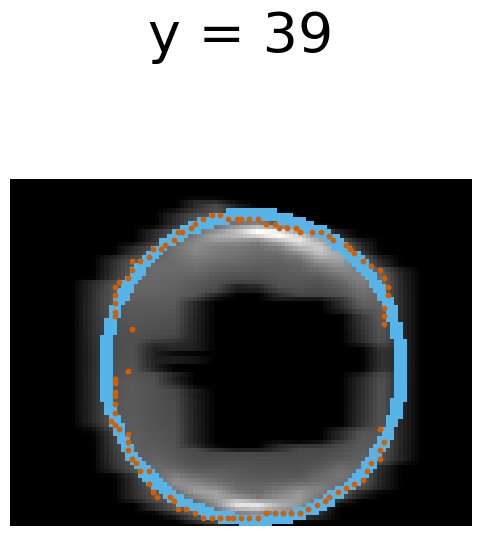

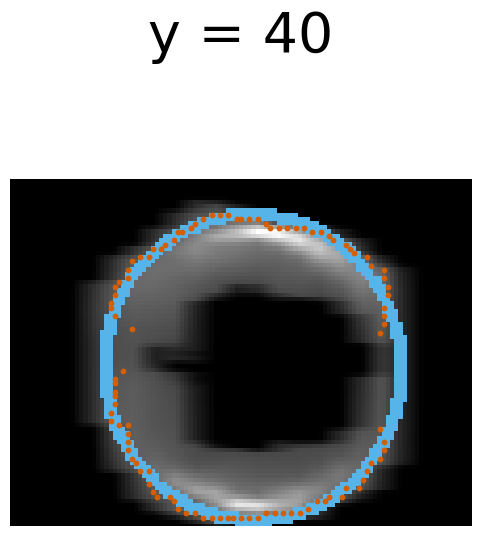

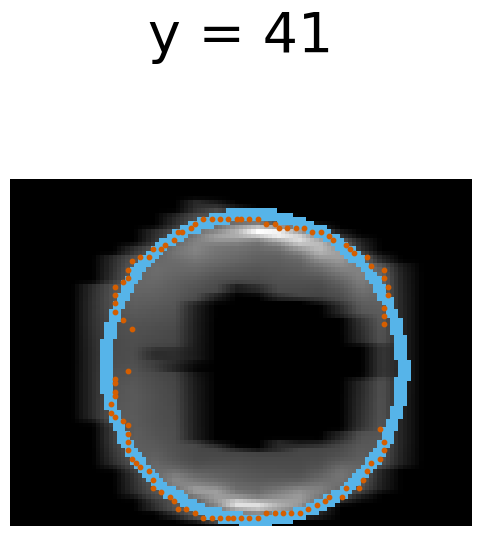

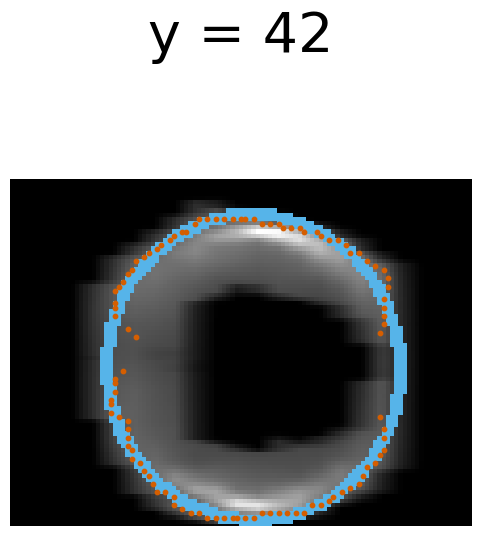

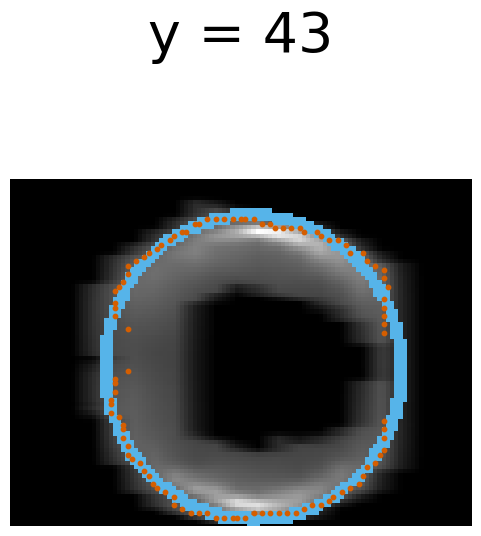

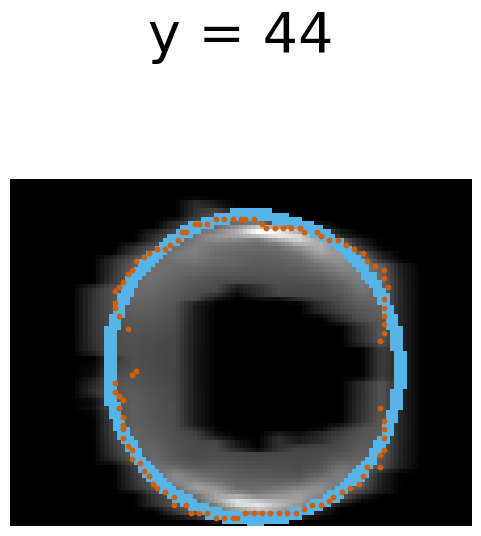

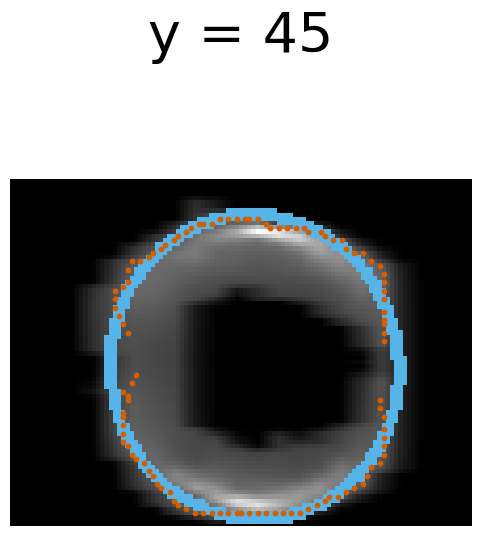

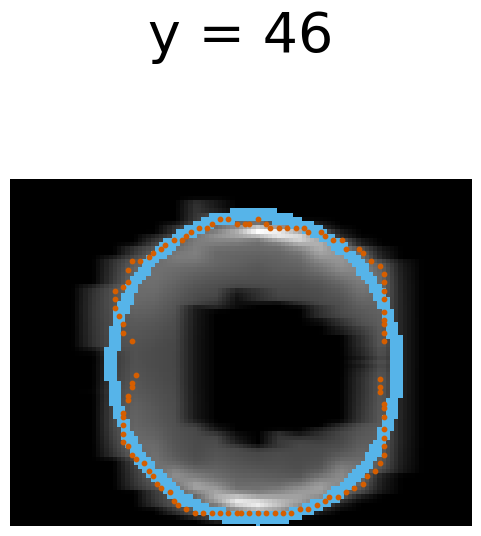

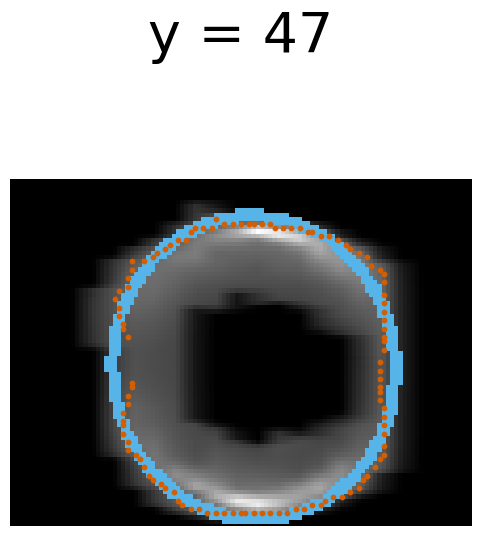

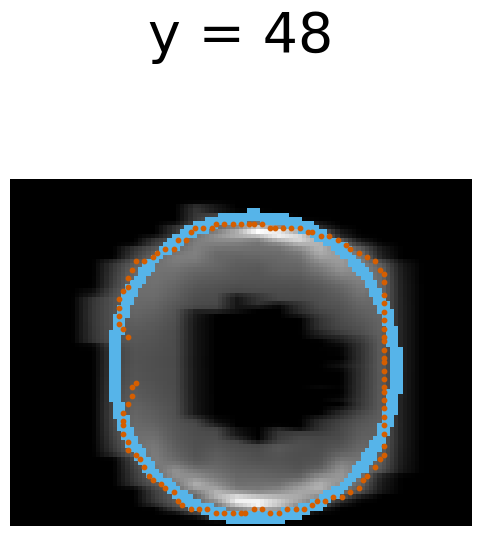

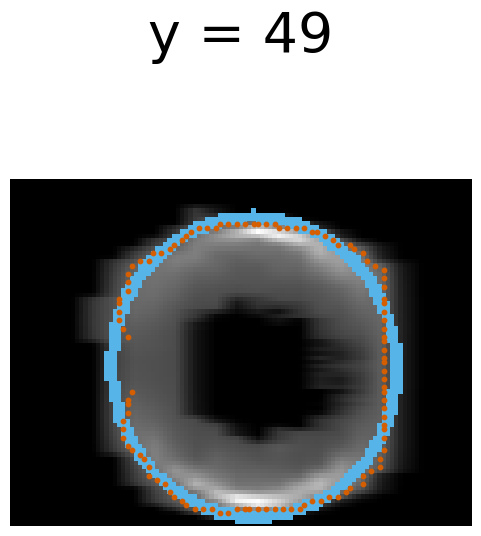

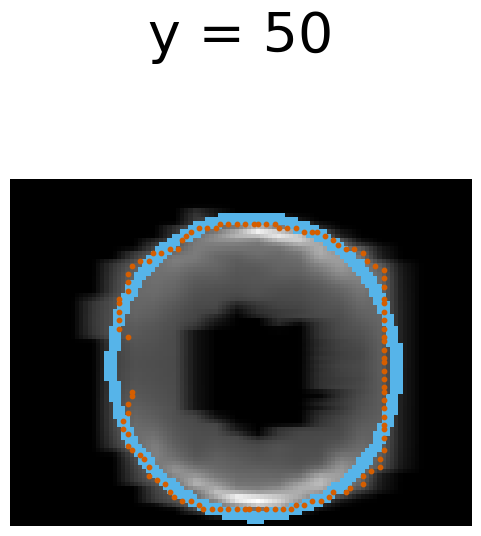

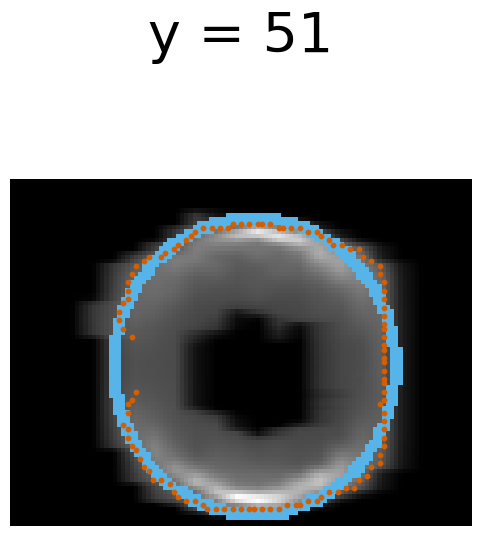

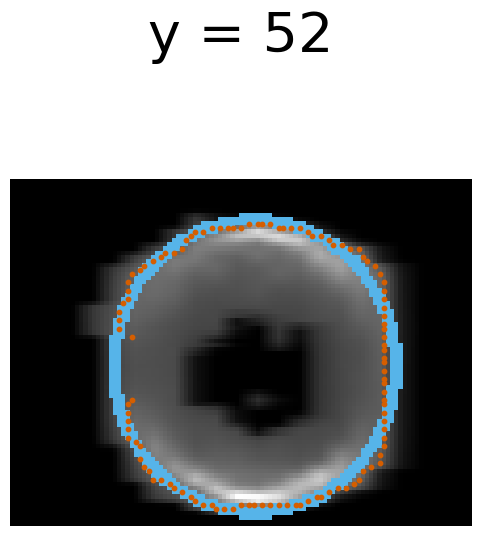

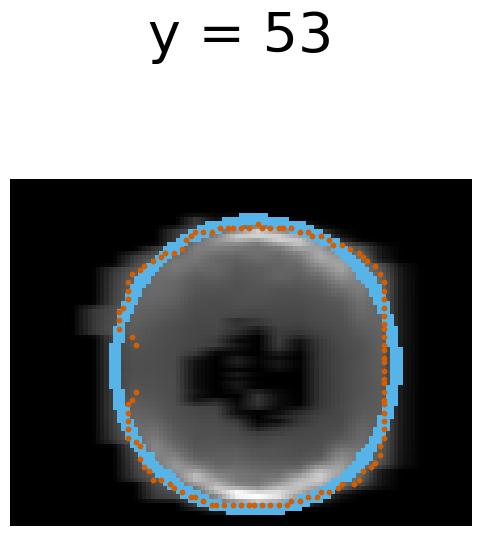

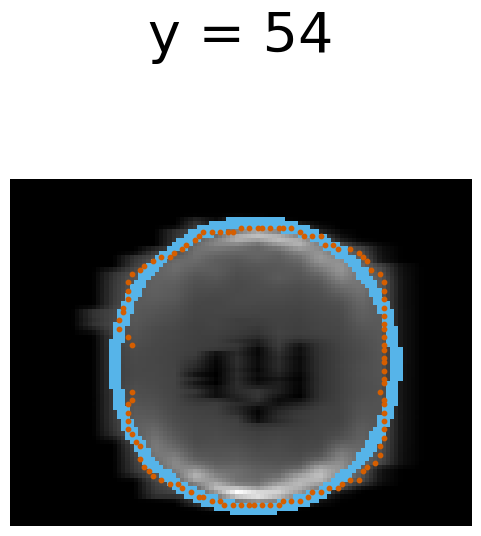

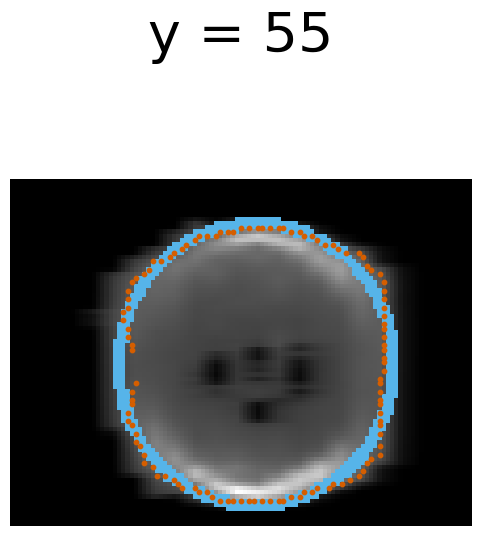

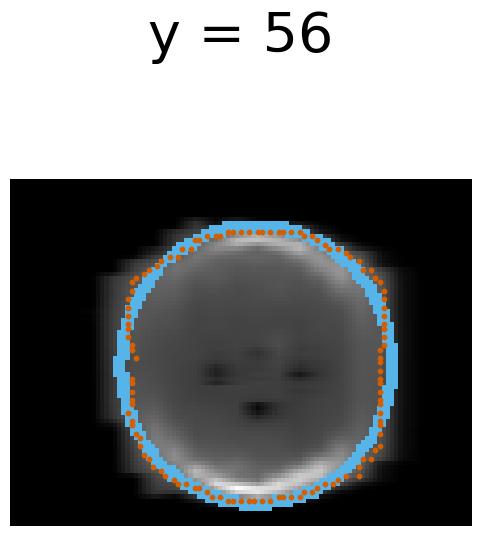

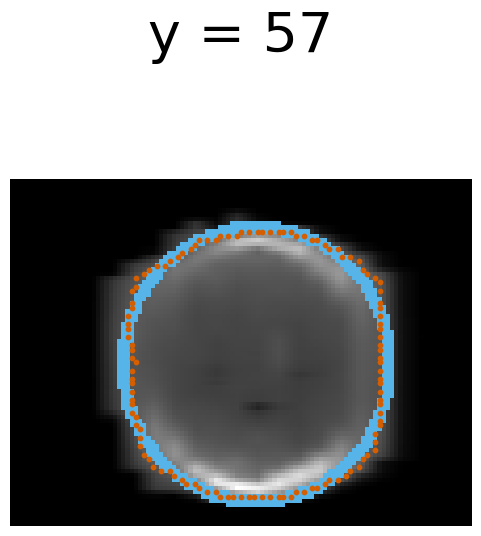

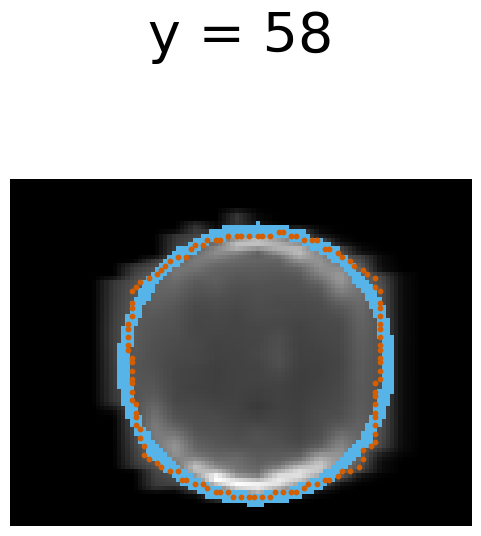

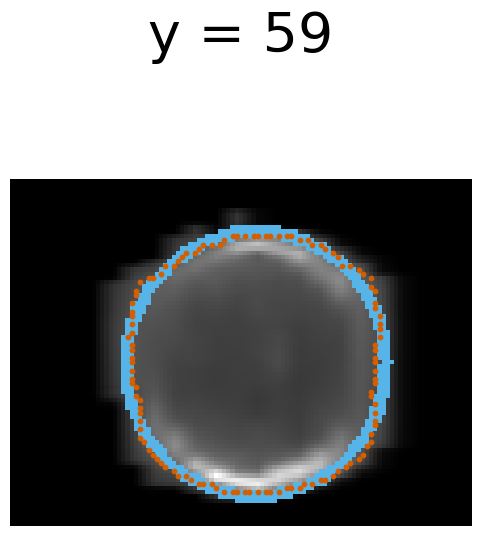

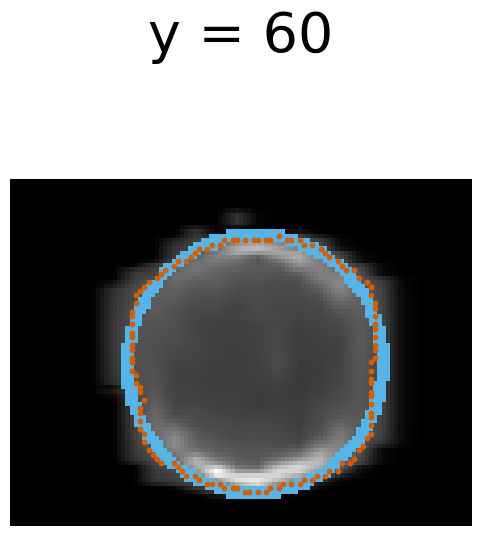

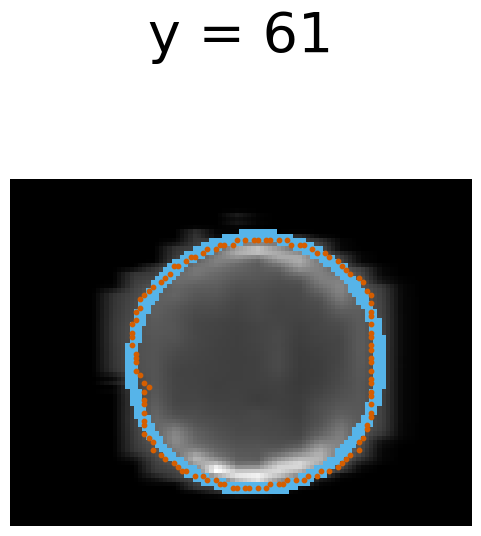

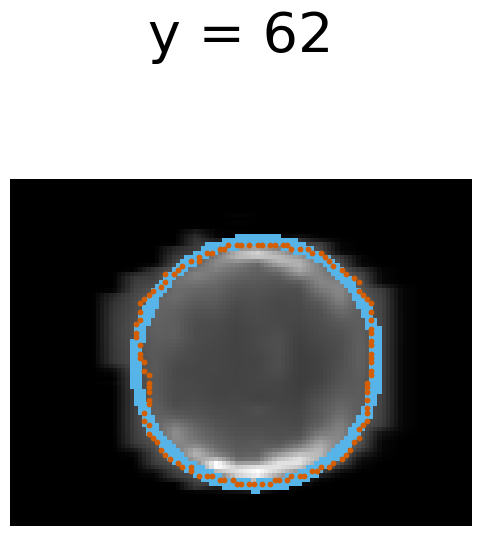

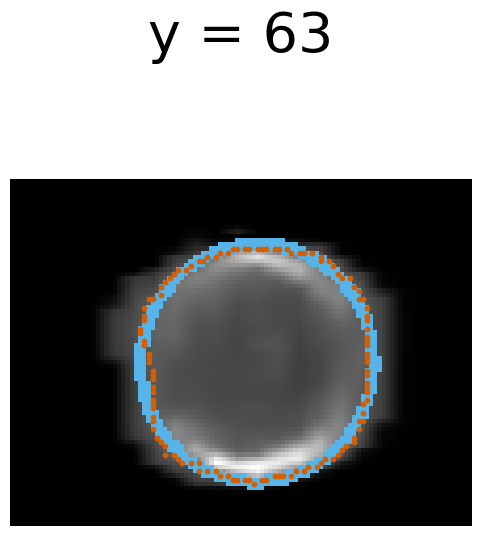

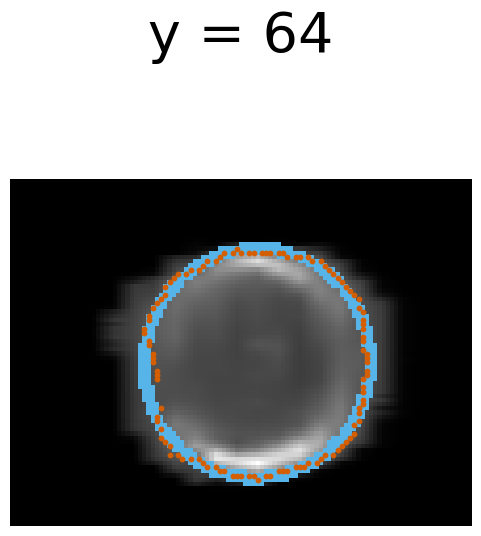

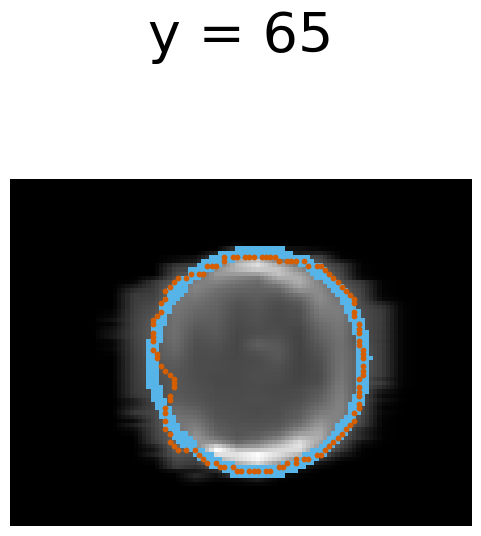

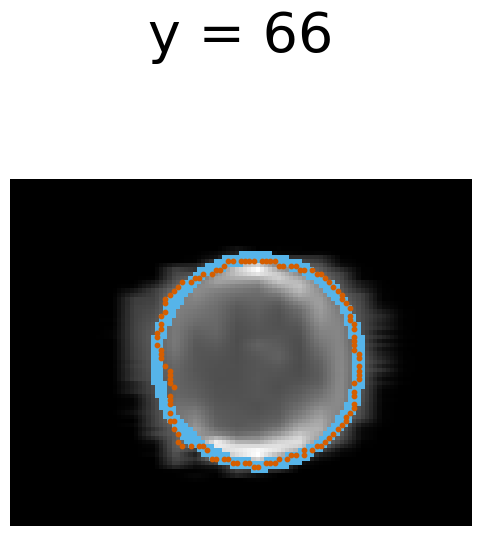

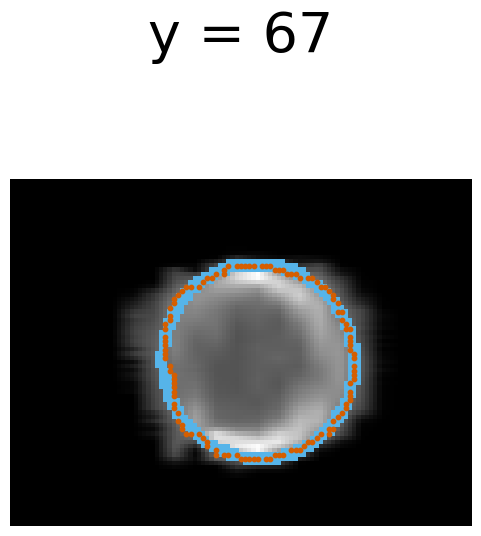

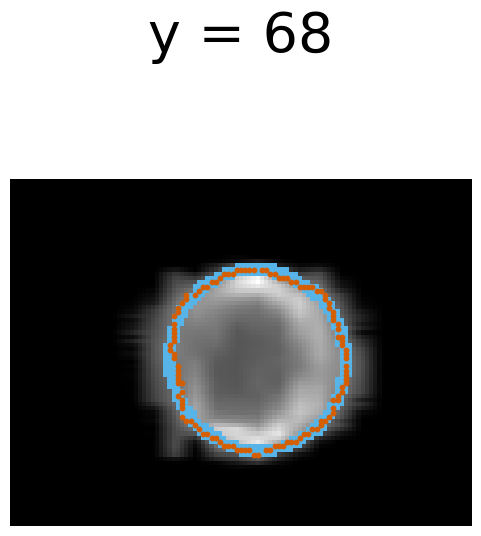

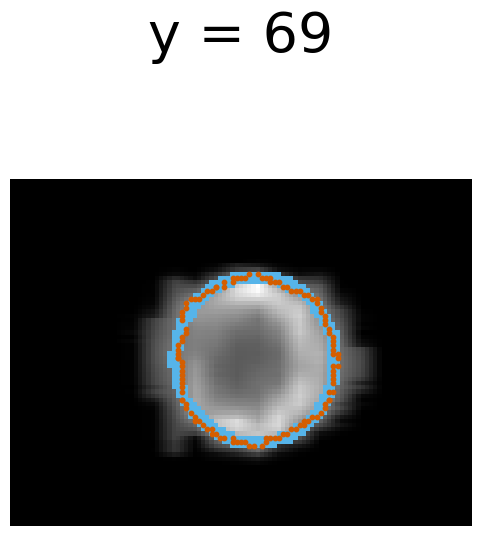

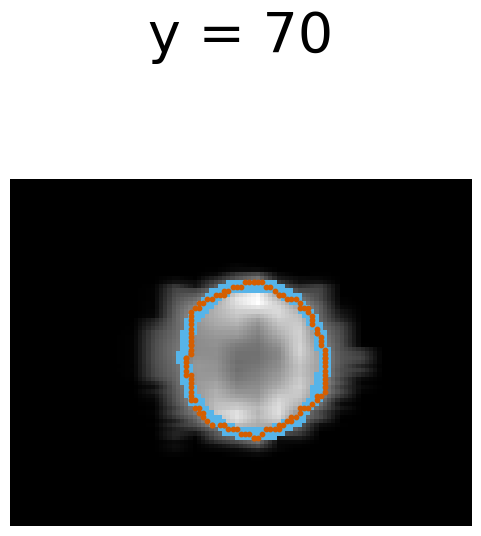

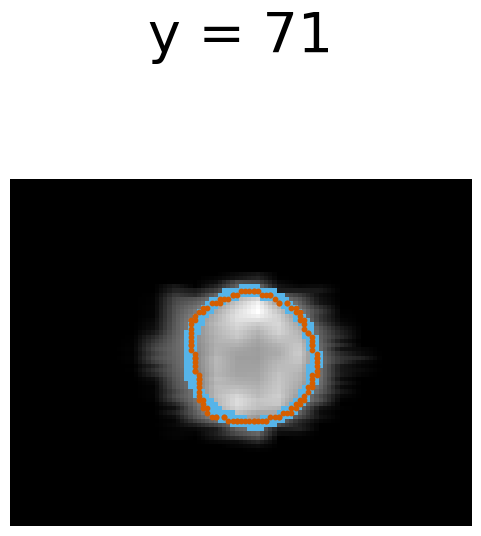

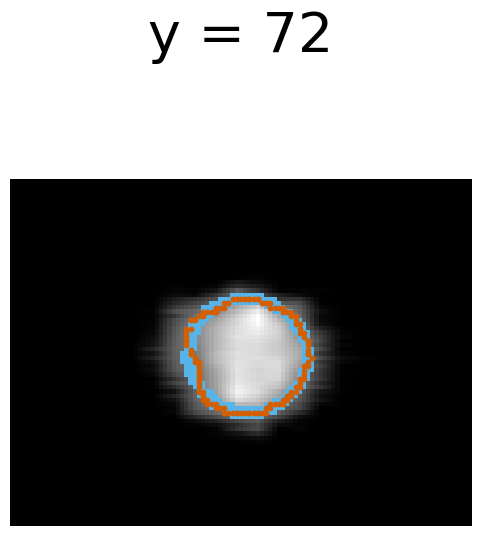

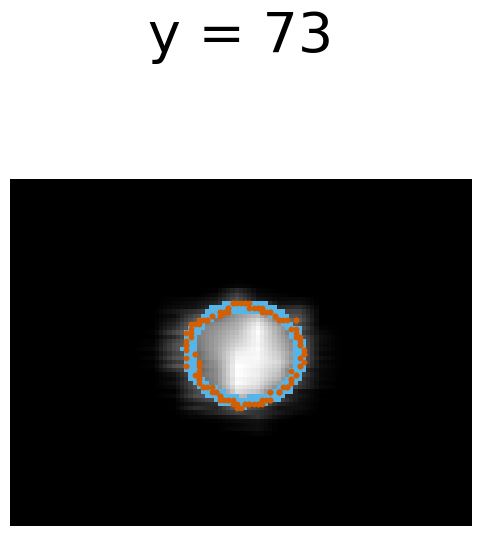

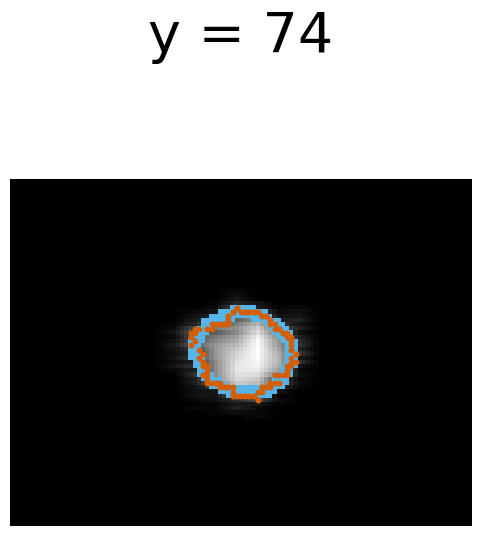

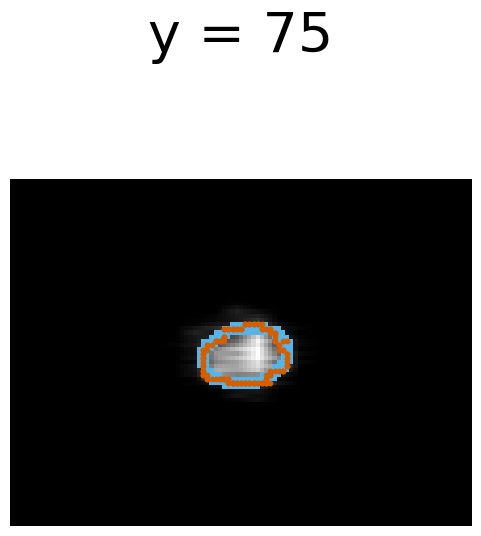

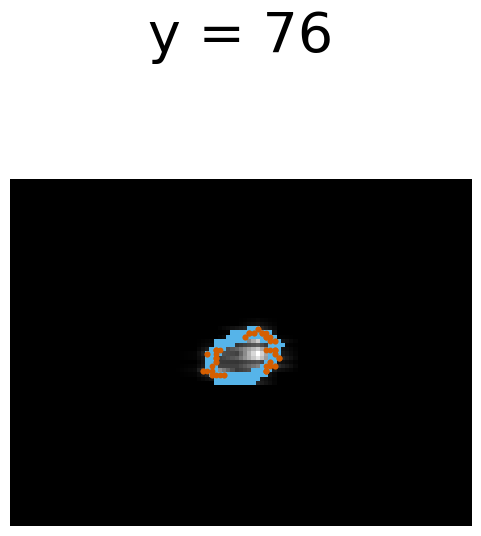

In [77]:
# 【日本語コメント】各 y slice に対して、最大連結領域抽出、z 方向補間、径方向探索、DBSCAN、楕円フィットを実行します。
# 【日本語コメント】フィット結果、中心、境界点、RMSE、楕円軸長をリストと辞書に保存します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
threshold_samples = 60

ellipse_list = []
center_list = []
final_pts_list = []
y_valid = []
rmse = []
a_set = []
b_set = []

ellipse_dict = {}

# for z in range(aligned_volume.shape[2]):
# 【日本語コメント】指定した y slice 範囲を順番に処理します。
for y in range(y0,ye):

    # if y<87:
    #     threshold_samples = 60
    # else:
    #     threshold_samples = 80
    # 【日本語コメント】現在の y 位置における XZ 断面を取り出します。
    slice_xz = cleaned_volume[:, y, :]  # ()

    # 1️⃣ 二值化（threshold 很关键）
    mask = slice_xz > threshold
    # 2️⃣ 连通区域标记
    # 【日本語コメント】連結成分ラベリングを行い、独立した領域を識別します。
    labeled, num = ndimage.label(mask)
    # 3️⃣ 找最大区域
    # 【日本語コメント】各連結成分のサイズを計算します。
    sizes = ndimage.sum(mask, labeled, range(1, num+1))
    if len(sizes) == 0:
        continue
    
    # 【日本語コメント】最も大きい連結成分のラベルを選択します。
    largest_label = np.argmax(sizes) + 1
    # 4️⃣ 只保留最大区域
    mask_clean = (labeled == largest_label)

    if y == 0:
        m0 = mask_clean
    else:
        mask_clean = mask_clean
        
    # 5️⃣ 应用到原数据
    clean_slice_xz = slice_xz * mask_clean

    # -----------------------------
    # 6. resample XZ slice to isotropic scale
    # -----------------------------
    # clean_slice_xz_iso = resample_z_insert_zero(
    #     clean_slice_xz,
    #     dxy=dxy,
    #     dz=dz
    # )

    # 【日本語コメント】XZ 断面を z 方向に補間し、等方的な画素サイズに近づけます。
    clean_slice_xz_iso = resample_z_interpolate(
        clean_slice_xz,
        dxy=dxy,
        dz=dz
    )


    # -----------------------------
    # 6. 径向射线搜索
    # -----------------------------
    # 【日本語コメント】径方向探索により、楕円フィット用の候補境界点を取得します。
    pts, img_uint8, threshold_value, center_pt = radial_ray_search(
        clean_slice_xz_iso,
        threshold_percentile=threshold_samples,
        num_rays=120,
        center_pt=None,
        min_r=5
    )

    if len(pts) < 10:
        ellipse_list.append(None)
        center_list.append(None)
        final_pts_list.append(None)
        continue

    # -----------------------------
    # 7. DBSCAN 聚类
    # -----------------------------
    # if y<8:
    #     tmpeps = 8
    # else:
    #     tmpeps = 10

    # if y<87:
    #     tmpeps = 8
    # else:
    #     tmpeps = 5
    tmpeps = 20
    # 【日本語コメント】DBSCAN により外れ点を除き、主クラスタの境界点を残します。
    final_pts, labels, main_label = filter_points_by_dbscan(pts,eps=tmpeps,min_samples=5)

    if len(final_pts) < 5:
        ellipse_list.append(None)
        center_list.append(None)
        final_pts_list.append(final_pts)
        continue

    # -----------------------------
    # 8. 椭圆拟合
    # -----------------------------
    
    try:
        # 【日本語コメント】AMS 法で境界点に楕円をフィットします。
        ellipse = cv2.fitEllipseAMS(final_pts.astype(np.float32))
    except Exception:
        # 【日本語コメント】AMS 法が失敗した場合の代替として通常の fitEllipse を使います。
        ellipse = cv2.fitEllipse(final_pts.astype(np.float32))

    ellipse_list.append(ellipse)
    center_list.append(ellipse[0])
    final_pts_list.append(final_pts)
    y_valid.append(y)
    # 【日本語コメント】slice 番号をキーとして楕円フィット結果を保存します。
    ellipse_dict[y] = ellipse

    (xc, yc), (MA, ma), angle = ellipse
    a_set.append(MA)
    b_set.append(ma)
    rmse.append(calculate_ellipse_rmse(final_pts, ellipse, dxy)/(MA*dxy))

    # -----------------------------
    # 9. 可视化
    # -----------------------------
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(img_uint8, cmap="gray")

    # # 径向搜索点
    # if len(pts) > 0:
    #     ax.scatter(pts[:, 0],pts[:, 1],s=10,label="Radial search points")
    #     ax.scatter(center_pt[0],center_pt[1],s=80,marker="x",label="Intensity center")

    # DBSCAN 主点堆
    if len(final_pts) > 0:
        ax.scatter(final_pts[:, 0], final_pts[:, 1], s=10,color="#D55E00", label="DBSCAN main cluster")

    # 椭圆
    if ellipse is not None:
        ellipse_img = img_uint8.copy()
        ellipse_img_rgb = cv2.cvtColor(ellipse_img, cv2.COLOR_GRAY2RGB)

        cv2.ellipse(
            ellipse_img_rgb,
            ellipse,
            color=(86, 180, 233),
            thickness=2
        )

        ax.imshow(ellipse_img_rgb)

    ax.set_title(f"y = {y}", fontsize=40)
    # ax.axis("equal")
    plt.xlim([xs,xt])
    plt.ylim([ys,yt])
    plt.axis('off')
    # ax.legend()
    # plt.savefig("/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig2/ellipse/" + "%04d" % (y) + ".svg", bbox_inches='tight',dpi = 100)
    plt.show()

In [78]:
# 【日本語コメント】楕円解析結果を pickle として保存するためのメモです。
# 【日本語コメント】現在はコメントアウトされているため、実行されません。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# import pickle
# import os

# save_dir = "/home/kang/Desktop/NAS_DS723_Kang/1. Research Data/3D/PMnuc_apical_WT9_251205_high/data/3D_reconstruction/"
# os.makedirs(save_dir, exist_ok=True)

# save_data = {
#     "cleaned_volume": cleaned_volume,
#     "ellipse_volume": ellipse_volume,
#     "ellipse_filled_volume": ellipse_filled_volume,

#     "ellipse_list": ellipse_list,
#     "ellipse_dict": ellipse_dict,
#     "center_list": center_list,
#     "final_pts_list": final_pts_list,
#     "y_valid": y_valid,

#     "rmse": rmse,
#     "a_set": a_set,
#     "b_set": b_set,

#     "threshold": threshold,
#     "threshold_samples": threshold_samples,
#     "dxy": dxy,
#     "dz": dz,
# }

# with open(os.path.join(save_dir, "ellipse_analysis_result.pkl"), "wb") as f:
#     pickle.dump(save_data, f)

In [79]:
# 【日本語コメント】各 y slice の ellipse_dict から、等方 spacing の 3D 楕円 volume を作成します。
# 【日本語コメント】輪郭 volume と塗りつぶし volume を生成し、marching_cubes でメッシュ化します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# ============================================================
# 使用 ellipse_dict 生成 isotropic ellipse volume
# ============================================================

X, Y, Z = cleaned_volume.shape

# 【日本語コメント】z 方向を dxy 間隔に換算した後の slice 数を計算します。
Z_iso = int(np.round((Z - 1) * dz / dxy)) + 1

# 【日本語コメント】楕円輪郭だけを保存する 3D volume を準備します。
ellipse_volume_iso = np.zeros((X, Y, Z_iso), dtype=np.uint8)
# 【日本語コメント】楕円内部を塗りつぶした 3D volume を準備します。
ellipse_filled_volume_iso = np.zeros((X, Y, Z_iso), dtype=np.uint8)

# 【日本語コメント】保存済みの各 slice の楕円を 3D volume に描き込みます。
for y, ellipse in ellipse_dict.items():

    # 注意：这里的图像大小必须和拟合时的 clean_slice_xz_iso 一致
    ellipse_img = np.zeros((X, Z_iso), dtype=np.uint8)
    ellipse_filled_img = np.zeros((X, Z_iso), dtype=np.uint8)

    cv2.ellipse(
        ellipse_img,
        ellipse,
        color=255,
        thickness=1
    )

    cv2.ellipse(
        ellipse_filled_img,
        ellipse,
        color=255,
        thickness=-1
    )

    ellipse_volume_iso[:, y, :] = ellipse_img
    ellipse_filled_volume_iso[:, y, :] = ellipse_filled_img

vol = ellipse_filled_volume_iso > 0

# 【日本語コメント】marching_cubes で volume から表面メッシュの頂点と面を抽出します。
verts, faces, normals, values = measure.marching_cubes(
    vol.astype(np.uint8),
    level=0.5,
    spacing=(dxy, dxy, dxy)  # 对应 X, Y, Z_iso
)

# 【日本語コメント】PyVista が認識できる faces 配列形式に変換します。
faces_pv = np.hstack([
    np.full((faces.shape[0], 1), 3),
    faces
]).astype(np.int64)

# 【日本語コメント】頂点と面情報から PyVista の PolyData メッシュを作成します。
mesh = pv.PolyData(verts, faces_pv)

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[600, 600])
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    mesh,
    color="#56B4E9",
    opacity=0.5,
    show_edges=False
)
plotter.show()

Widget(value='<iframe src="http://localhost:43869/index.html?ui=P_0x7a6451292ce0_27&reconnect=auto" class="pyv…

In [80]:
# 【日本語コメント】Fig.3 用の楕円解析結果を pickle として保存するためのメモです。
# 【日本語コメント】現在はコメントアウトされているため、実行されません。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# import pickle
# import os

# save_dir = "/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig3/data/"
# os.makedirs(save_dir, exist_ok=True)

# save_data = {
#     "cleaned_volume": cleaned_volume,
#     "ellipse_volume": ellipse_volume,
#     "ellipse_filled_volume": ellipse_filled_volume,

#     "ellipse_list": ellipse_list,
#     "ellipse_dict": ellipse_dict,
#     "center_list": center_list,
#     "final_pts_list": final_pts_list,
#     "y_valid": y_valid,

#     "rmse": rmse,
#     "a_set": a_set,
#     "b_set": b_set,

#     "threshold": threshold,
#     "threshold_samples": threshold_samples,
#     "dxy": dxy,
#     "dz": dz,
# }

# with open(os.path.join(save_dir, "ellipse_analysis_result.pkl"), "wb") as f:
#     pickle.dump(save_data, f)

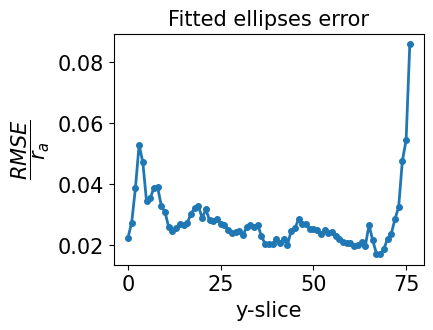

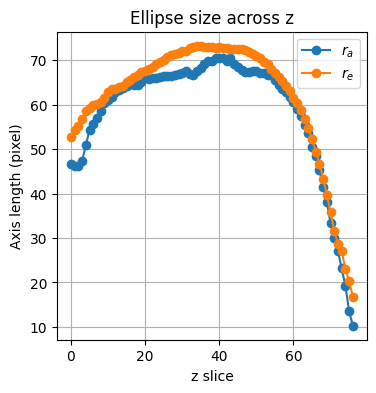

In [81]:
# 【日本語コメント】楕円フィットの正規化 RMSE と、各 slice における楕円軸長をプロットします。
# 【日本語コメント】フィッティング精度と軸長変化を視覚的に確認するためのセルです。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
labsize = 15

plt.figure(figsize=(4, 3))
plt.plot(y_valid, rmse, 'o-', linewidth=2, markersize=4)
plt.xlabel("y-slice", fontsize=labsize)
plt.ylabel(r"$\dfrac{RMSE}{r_a}$", fontsize=labsize)
plt.title("Fitted ellipses error", fontsize=labsize)
# plt.grid(True)
plt.tick_params(labelsize=labsize)
# plt.savefig("/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig2/" + "RMSE.svg", bbox_inches='tight',dpi = 100)
# plt.savefig('D:/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/3D再構築/RMSE.jpg',bbox_inches='tight',dpi = 600)
plt.show()

plt.figure(figsize=(4, 4))
plt.plot(y_valid, a_set, 'o-', label=f'$r_a$')
plt.plot(y_valid, b_set, 'o-', label=f'$r_e$')

plt.xlabel("z slice")
plt.ylabel("Axis length (pixel)")
plt.title("Ellipse size across z")
plt.legend()
plt.grid(True)
# plt.savefig('D:/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/3D再構築/re_ra.jpg',bbox_inches='tight',dpi = 600)
plt.show()


In [82]:
# 【日本語コメント】有効な楕円だけを取り出し、center・axis・angle を LOWESS で平滑化します。
# 【日本語コメント】平滑化した楕円から filled volume を再構成し、3D メッシュに変換します。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
import cv2


# 【日本語コメント】2値化された 3D volume から marching_cubes で表面メッシュを作成する関数です。
def volume_to_mesh(volume_binary, spacing=(1.0, 1.0, 1.0)):
    dz_, dy_, dx_ = spacing
    # 【日本語コメント】marching_cubes で volume から表面メッシュの頂点と面を抽出します。
    verts, faces, normals, values = measure.marching_cubes(
        volume_binary.astype(np.uint8),
        level=0.5,
        spacing=(dz_, dy_, dx_)
    )
    verts_xyz = verts[:, [2, 1, 0]]
    # 【日本語コメント】PyVista が認識できる faces 配列形式に変換します。
    faces_pv = np.hstack([
        np.full((faces.shape[0], 1), 3),
        faces
    ]).astype(np.int64)
    return pv.PolyData(verts_xyz, faces_pv)


# ============================================================
# 1. 只取有效的 ellipse
# ============================================================

# 推荐使用 ellipse_dict 和 y_valid，避免 ellipse_list 里的 None
# 【日本語コメント】有効な楕円が得られた slice 番号を NumPy 配列に変換します。
y_valid = np.array(y_valid, dtype=int)

# 【日本語コメント】有効 slice に対応する楕円情報だけを取り出します。
ellipse_valid_list = [ellipse_dict[y] for y in y_valid]

# 平滑的自变量建议直接用 y_valid
# 如果中间有缺失 slice，这样比 np.arange(len(...)) 更合理
y_axis = y_valid.astype(float)

alpha = 0.2

# ============================================================
# 2. 提取 ellipse 参数
# ============================================================

center0_list = np.array([e[0][0] for e in ellipse_valid_list], dtype=float)
center1_list = np.array([e[0][1] for e in ellipse_valid_list], dtype=float)

MA_list = np.array([e[1][0] for e in ellipse_valid_list], dtype=float)
ma_list = np.array([e[1][1] for e in ellipse_valid_list], dtype=float)

theta_list = np.array([e[2] for e in ellipse_valid_list], dtype=float)


# ============================================================
# 3. 平滑 center 和 axis
# ============================================================

# 【日本語コメント】LOWESS により楕円中心座標を平滑化します。
center0_smooth = lowess(
    center0_list,
    y_axis,
    frac=alpha,
    return_sorted=False
)

center1_smooth = lowess(
    center1_list,
    y_axis,
    frac=alpha,
    return_sorted=False
)

# 【日本語コメント】LOWESS により楕円の軸長を平滑化します。
MA_smooth = lowess(
    MA_list,
    y_axis,
    frac=alpha,
    return_sorted=False
)

ma_smooth = lowess(
    ma_list,
    y_axis,
    frac=alpha,
    return_sorted=False
)


# ============================================================
# 4. 平滑 angle
# ============================================================
# 椭圆角度具有 180° 周期性，所以不能直接 lowess(theta_list)
# 用 double-angle 方法更稳

# 【日本語コメント】角度を degree から radian に変換します。
theta_rad = np.deg2rad(theta_list)

# 【日本語コメント】楕円角度の 180° 周期性を考慮して角度の飛びを補正します。
theta_unwrapped = np.unwrap(2 * theta_rad) / 2

theta_smooth_rad = lowess(
    theta_unwrapped,
    y_axis,
    frac=alpha,
    return_sorted=False
)

theta_smooth = np.rad2deg(theta_smooth_rad)

# 限制到 [0, 180)
theta_smooth = np.mod(theta_smooth, 180)# # raw cropped volume as points
# plotter.add_points(
#     point_cloud,
#     scalars="values",
#     cmap=cmap0,
#     point_size=4,
#     render_points_as_spheres=True,
#     opacity=0.5,
#     show_scalar_bar=False
# )


# ============================================================
# 5. 生成平滑后的 ellipse_dict
# ============================================================

# 【日本語コメント】平滑化後の楕円情報を保存する辞書を準備します。
ellipse_dict_smoothed = {}
ellipse_smooth_set = []

for i, y in enumerate(y_valid):

    ellipse_new = (
        (
            float(center0_smooth[i]),
            float(center1_smooth[i])
        ),
        (
            float(MA_smooth[i]),
            float(ma_smooth[i])
        ),
        float(theta_smooth[i])
    )

    ellipse_dict_smoothed[y] = ellipse_new
    ellipse_smooth_set.append(ellipse_new)

# ============================================================
# 6. 用平滑后的 ellipse 生成 isotropic filled volume
# ============================================================

# 注意：
# 这里假设 cleaned_volume shape = (X, Y, Z)
# 如果你的 cleaned_volume 是 (Z, Y, X)，看后面的说明

X, Y, Z = cleaned_volume.shape

# 【日本語コメント】z 方向を dxy 間隔に換算した後の slice 数を計算します。
Z_iso = int(np.round((Z - 1) * dz / dxy)) + 1

ellipse_volume_smoothed = np.zeros(
    (X, Y, Z_iso),
    dtype=np.uint8
)

ellipse_filled_volume_smoothed = np.zeros(
    (X, Y, Z_iso),
    dtype=np.uint8
)

for y, ellipse_cv in ellipse_dict_smoothed.items():

    # ellipse_cv 的坐标属于 clean_slice_xz_iso
    # clean_slice_xz_iso shape = (X, Z_iso)
    ellipse_img = np.zeros((X, Z_iso), dtype=np.uint8)
    ellipse_filled_img = np.zeros((X, Z_iso), dtype=np.uint8)

    # 轮廓
    cv2.ellipse(
        ellipse_img,
        ellipse_cv,
        color=1,
        thickness=1
    )

    # 填充
    cv2.ellipse(
        ellipse_filled_img,
        ellipse_cv,
        color=1,
        thickness=-1
    )

    ellipse_volume_smoothed[:, y, :] = ellipse_img
    ellipse_filled_volume_smoothed[:, y, :] = ellipse_filled_img

# ============================================================
# 7. 转成 mesh
# ============================================================

# volume_to_mesh() 需要输入 shape = (Z, Y, X)
# 但 ellipse_filled_volume_smoothed 现在是 (X, Y, Z_iso)
# 所以需要 transpose

ellipse_binary_smoothed_zyx = (
    ellipse_filled_volume_smoothed > 0
).transpose(2, 1, 0)

# 【日本語コメント】平滑化後の filled volume を 3D メッシュへ変換します。
ellipse_mesh_smoothed = volume_to_mesh(
    ellipse_binary_smoothed_zyx,
    spacing=(dxy, dxy, dxy)
)


# plotter = pv.Plotter(window_size=[800, 800])

# plotter.add_mesh(
#     ellipse_mesh_smoothed,
#     color="#56B4E9",
#     opacity=0.6,
#     show_edges=False
# )

# plotter.add_axes(line_width=3)

# plotter.show()

In [84]:
# 【日本語コメント】crop した raw volume を点群として表示し、平滑化した楕円メッシュを重ねます。
# 【日本語コメント】元データと再構成メッシュの位置・形状の一致を確認するための可視化セルです。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# # ============================================================
# # 1. cropped_volume -> PyVista ImageData
# # ============================================================

# Xc, Yc, Zc = cropped_volume.shape

# grid_cleaned = pv.ImageData()
# grid_cleaned.dimensions = (Xc, Yc, Zc)

# # spacing 对应 PyVista 的 X, Y, Z
# grid_cleaned.spacing = (dxy, dxy, dz)

# # 如果想保留原始物理位置，用 crop 前的 offset
# grid_cleaned.origin = (
#     x_range[0] * dxy,
#     y_range[0] * dxy,
#     z_range[0] * dz
# )

# # cropped_volume 已经是 (X, Y, Z)，所以直接 ravel(order="F")
# grid_cleaned.point_data["values"] = cropped_volume.ravel(order="F")

# origin_offset = np.array([
#     x_range[0] * dxy,
#     y_range[0] * dxy,
#     z_range[0] * dz
# ])

# ellipse_mesh_smoothed_global = ellipse_mesh_smoothed.copy()
# ellipse_mesh_smoothed_global.translate(origin_offset, inplace=True)

# plotter = pv.Plotter(window_size=[800, 800])

# opy = 0.3

# # raw cropped volume
# plotter.add_volume(
#     grid_cleaned,
#     scalars="values",
#     cmap=cmap0,
#     opacity=[0, 0.02, opy, opy, opy, opy, opy, opy, opy, opy, opy, opy],
#     show_scalar_bar=False
# )

# # smoothed ellipse mesh
# plotter.add_mesh(
#     ellipse_mesh_smoothed_global,
#     color="#56B4E9",
#     opacity=0.6,
#     show_edges=False,
#     label="Smoothed ellipse volume"
# )

# plotter.add_axes(line_width=3)

# plotter.show_bounds(
#     grid="front",
#     location="outer",
#     all_edges=True,
#     xtitle="X (µm)",
#     ytitle="Y (µm)",
#     ztitle="Z (µm)",
#     font_size=12
# )

# plotter.view_isometric()
# plotter.show()

import pyvista as pv
import numpy as np

# ============================================================
# 1. cropped_volume -> point cloud
# ============================================================

Xc, Yc, Zc = cropped_volume.shape

# ------------------------------------------------------------
# 只显示较高 intensity 的 voxel
# ------------------------------------------------------------
# 【日本語コメント】0 以外の voxel 値を取り出し、しきい値計算に使います。
nonzero_vals = cropped_volume[cropped_volume > 0]

threshold = np.percentile(nonzero_vals, 0)   # 可以改成 80, 95, 99
# 【日本語コメント】しきい値より明るい voxel だけを点群化対象にします。
mask = cropped_volume > threshold

# voxel index: columns = x, y, z
# 【日本語コメント】mask が True の voxel index を取得します。
idx = np.argwhere(mask)

# ------------------------------------------------------------
# index 坐标 -> 物理坐标 µm
# 注意：这里保留了 crop 前的 global position
# ------------------------------------------------------------
# 【日本語コメント】voxel index を物理座標に変換して保存する配列を準備します。
points = np.zeros((idx.shape[0], 3), dtype=float)

points[:, 0] = (idx[:, 0] + x_range[0]) * dxy
points[:, 1] = (idx[:, 1] + y_range[0]) * dxy
points[:, 2] = (idx[:, 2] + z_range[0]) * dz

values = cropped_volume[mask]

# ------------------------------------------------------------
# 如果点太多，随机抽样
# ------------------------------------------------------------
max_points = 80000

if len(points) > max_points:
    choice = np.random.choice(len(points), max_points, replace=False)
    points = points[choice]
    values = values[choice]

# 【日本語コメント】物理座標点群を PyVista の PolyData として作成します。
point_cloud = pv.PolyData(points)
point_cloud["values"] = values


# ============================================================
# 2. ellipse mesh 平移到 global coordinate
# ============================================================

# 【日本語コメント】crop 前の global position に戻すための offset を計算します。
origin_offset = np.array([
    x_range[0] * dxy,
    y_range[0] * dxy,
    z_range[0] * dz
])

# 【日本語コメント】平滑化メッシュを global coordinate に配置するためコピーします。
ellipse_mesh_smoothed_global = ellipse_mesh_smoothed.copy()
ellipse_mesh_smoothed_global.translate(origin_offset, inplace=True)


# ============================================================
# 3. plot
# ============================================================

# 【日本語コメント】3D 描画用の PyVista Plotter を作成します。
plotter = pv.Plotter(window_size=[800, 800])

# raw cropped volume as points
plotter.add_points(
    point_cloud,
    scalars="values",
    cmap=cmap0,
    point_size=4,
    render_points_as_spheres=True,
    opacity=0.5,
    show_scalar_bar=False
)

# smoothed ellipse mesh
# 【日本語コメント】作成したメッシュや矢印を 3D 画面に追加します。
plotter.add_mesh(
    ellipse_mesh_smoothed_global,
    color="#56B4E9",
    opacity=0.6,
    show_edges=False,
    label="Smoothed ellipse volume"
)

plotter.add_axes(line_width=3)

plotter.show_bounds(
    grid="front",
    location="outer",
    all_edges=True,
    xtitle="X (µm)",
    ytitle="Y (µm)",
    ztitle="Z (µm)",
    font_size=12
)

plotter.view_isometric()
plotter.show()

Widget(value='<iframe src="http://localhost:43869/index.html?ui=P_0x7a6450e09fc0_29&reconnect=auto" class="pyv…

In [85]:
# 【日本語コメント】crop した raw data、スケール情報、crop 範囲、平滑化メッシュを pickle に保存します。
# 【日本語コメント】後続の図作成や別 notebook での読み込みに使うデータをまとめます。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
import pickle

savepth = "/home/kang/Dropbox/3. 仕事/1.1 論文作成/01. 進行中の論文/頂端細胞メッシュメソッド論文/Fig3/normal_data/"

# 【日本語コメント】後で再利用する解析結果を辞書としてまとめます。
save_data = {
    # raw cropped data
    "cropped_volume": cropped_volume,

    # scale information
    "dxy": dxy,
    "dz": dz,

    # crop range
    "x_range": x_range,
    "y_range": y_range,
    "z_range": z_range,

    # ellipse mesh
    "ellipse_mesh_smoothed": ellipse_mesh_smoothed,

    # optional: if you want to save global mesh too
    "ellipse_mesh_smoothed_global": ellipse_mesh_smoothed_global,
}

# 【日本語コメント】pickle ファイルとして解析結果を保存します。
with open(savepth + "Sample11_normal.pkl", "wb") as f:
    pickle.dump(save_data, f)

In [ ]:
# 【日本語コメント】解析結果を確認するためのプレースホルダーです。
# 【日本語コメント】以下、元のコード行は変更せず、説明コメントのみを追加しています。
# result